In [1]:
import os, json, glob, re
import numpy as np
import pandas as pd
import jiwer
import torch
from bert_score import score as bert_score_fn
from transformers import RobertaTokenizer, RobertaModel, logging as hf_logging
hf_logging.set_verbosity_error()

JUDGES = {
    "llama": "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/llama_70b_annotation",
    "qwen":  "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/qwen_72b_annotation",
    "deepseek": "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/deepseek_llama_70b_annotation"
}
CACHE_DIR = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/eval_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

WER_TRANSFORM = jiwer.Compose([
    jiwer.ToLowerCase(), jiwer.RemovePunctuation(),
    jiwer.RemoveMultipleSpaces(), jiwer.Strip(),
    jiwer.ExpandCommonEnglishContractions(),
    jiwer.RemoveEmptyStrings(), jiwer.ReduceToListOfListOfWords(),
])

/home/kairam42/ASR-FAA/ASR_Finetuning/cer_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [3]:
"""
ASR Evaluation Pipeline
Computes: Corpus WER, BERTScore F1, SemDist, Contextual Error Rate
Caches results to CSV. Plots separate figures per metric per judge.
"""

import os
import json
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import jiwer
import torch
from bert_score import score as bert_score_fn
from transformers import RobertaTokenizer, RobertaModel

from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

# ─── Config ───────────────────────────────────────────────────────────────────

JUDGES = {
    "llama": "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/llama_70b_annotation",
    "qwen":  "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/qwen_72b_annotation",
    "deepseek": "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/deepseek_llama_70b_annotation"
}
CACHE_DIR = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/eval_cache"
PLOT_DIR  = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/eval_plots"
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(PLOT_DIR,  exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

WER_TRANSFORM = jiwer.Compose([
    jiwer.ToLowerCase(),
    jiwer.RemovePunctuation(),
    jiwer.RemoveMultipleSpaces(),
    jiwer.Strip(),
    jiwer.ExpandCommonEnglishContractions(),
    jiwer.RemoveEmptyStrings(),
    jiwer.ReduceToListOfListOfWords(),
])

# ─── Filename parser ───────────────────────────────────────────────────────────

def parse_filename(fname):
    """Extract model, variant, dataset from filename."""
    base = os.path.basename(fname).replace("_predictions.json", "")
    # Split on -combined or _pretrained
    m = re.match(r"^(.+?)-(combined|pretrained)_(.+)$", base)
    if not m:
        # try with underscore variant separator
        m = re.match(r"^(.+?)_(pretrained|combined)_(.+)$", base)
    if not m:
        return None, None, None
    model   = m.group(1)
    variant = m.group(2)
    dataset = m.group(3)
    return model, variant, dataset

# ─── Metric helpers ────────────────────────────────────────────────────────────

def compute_corpus_wer(references, hypotheses):
    # Apply transforms individually to detect empties post-transform
    tr = jiwer.Compose([
        jiwer.ToLowerCase(),
        jiwer.RemovePunctuation(),
        jiwer.RemoveMultipleSpaces(),
        jiwer.Strip(),
        jiwer.ExpandCommonEnglishContractions(),
    ])
    filtered = [(r, h) for r, h in zip(references, hypotheses)
                if tr([r])[0].strip() and tr([h])[0].strip()]
    refs, hyps = zip(*filtered)
    return round(jiwer.wer(
        list(refs), list(hyps),
        reference_transform=WER_TRANSFORM,
        hypothesis_transform=WER_TRANSFORM,
    ) * 100, 4)


def compute_bertscore(references, hypotheses):
    # Filter empty pairs
    pairs = [(r, h) for r, h in zip(references, hypotheses) if r.strip() and h.strip()]
    refs, hyps = zip(*pairs)
    _, _, F1 = bert_score_fn(
        list(hyps), list(refs),
        lang="en",
        rescale_with_baseline=False,
        model_type="roberta-large",
        batch_size=32,
        device=DEVICE,
        verbose=False,
    )
    return round(1.0 - F1.mean().item(), 6)  # BERTDist: lower is better


class SemDist:
    _instance = None

    @classmethod
    def get(cls):
        if cls._instance is None:
            cls._instance = cls()
        return cls._instance

    def __init__(self):
        print(f"[SemDist] Loading roberta-large on {DEVICE}...")
        self.tokenizer = RobertaTokenizer.from_pretrained("roberta-large")
        self.model = RobertaModel.from_pretrained("roberta-large").to(DEVICE)
        self.model.eval()

    @torch.no_grad()
    def _embed(self, texts, batch_size=32):
        all_emb = []
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            enc = self.tokenizer(batch, padding=True, truncation=True,
                                 max_length=128, return_tensors="pt").to(DEVICE)
            out = self.model(**enc)
            mask = enc["attention_mask"].unsqueeze(-1).float()
            emb  = (out.last_hidden_state * mask).sum(1) / mask.sum(1)
            all_emb.append(emb.cpu())
        return torch.cat(all_emb, 0)

    def compute(self, references, hypotheses):
        # Filter empty pairs
        pairs = [(r, h) for r, h in zip(references, hypotheses) if r.strip() and h.strip()]
        refs, hyps = zip(*pairs)
        r = self._embed(list(refs))
        h = self._embed(list(hyps))
        dist = 1.0 - torch.nn.functional.cosine_similarity(r, h, dim=1)
        return round(dist.mean().item(), 6)


def compute_contextual_error_rate(records):
    """CCER = critical / (critical + equivalent), excludes failed JSON parse records."""
    valid      = [r for r in records if r.get("contextual_status") != "Error"]
    critical   = sum(1 for r in valid if r.get("contextual_status") == "Critical_Errors")
    equivalent = sum(1 for r in valid if r.get("contextual_status") == "Equivalent")
    total = critical + equivalent
    return round(critical / total, 6) if total else None

# ─── Per-file evaluation ───────────────────────────────────────────────────────

def evaluate_file(fpath):
    with open(fpath) as f:
        data = json.load(f)
    records = data.get("records", [])
    refs = [r["reference"]  for r in records]
    hyps = [r["hypothesis"] for r in records]
    return {
        "WER":      compute_corpus_wer(refs, hyps),
        "BERTDist": compute_bertscore(refs, hyps),   # renamed
        "SemDist":  SemDist.get().compute(refs, hyps),
        "CCER":     compute_contextual_error_rate(records),  # renamed
    }

# ─── Main loop ─────────────────────────────────────────────────────────────────

def run_judge(judge_name, judge_dir):
    cache_path = os.path.join(CACHE_DIR, f"{judge_name}_results.csv")

    if os.path.exists(cache_path):
        print(f"[{judge_name}] Cache found, loading...")
        return pd.read_csv(cache_path)

    files = glob.glob(os.path.join(judge_dir, "*.json"))
    rows  = []
    for fpath in sorted(files):
        model, variant, dataset = parse_filename(fpath)
        if model is None:
            print(f"  Skipping unrecognized: {fpath}")
            continue
        print(f"  [{judge_name}] {model} | {variant} | {dataset}")
        metrics = evaluate_file(fpath)
        rows.append({"judge": judge_name, "model": model,
                     "variant": variant, "dataset": dataset, **metrics})

    df = pd.DataFrame(rows)
    df.to_csv(cache_path, index=False)
    print(f"[{judge_name}] Saved to {cache_path}")
    return df

# ─── Plotting ──────────────────────────────────────────────────────────────────

METRICS = {
    "WER":    ("Corpus WER (%)",         "lower is better"),
    "BERTDist": ("BERTDist (1 - BERTScore F1, roberta-large)", "lower is better"),
    "SemDist":  ("SemDist (roberta-large)",                     "lower is better"),
    "CCER":     ("Contextual Critical Error Rate",              "lower is better"),
}

DATASETS = ["atco2_ood", "uwb_atcc_test", "atcosim_test"]
MODELS   = ["whisper-medium", "parakeet-tdt-0.6b-v3"]
VARIANTS = ["pretrained", "combined"]
COLORS   = {"pretrained": "#4C72B0", "combined": "#DD8452"}


# def plot_metric(df, judge_name, metric, ylabel, note):
#     fig, axes = plt.subplots(1, len(MODELS), figsize=(14, 5), sharey=False)
#     fig.suptitle(f"[{judge_name.upper()}] {ylabel}", fontsize=13, fontweight="bold")

#     for ax, model in zip(axes, MODELS):
#         mdf = df[df["model"] == model]
#         x   = np.arange(len(DATASETS))
#         w   = 0.35

#         for i, variant in enumerate(VARIANTS):
#             vdf    = mdf[mdf["variant"] == variant].set_index("dataset")
#             vals   = [vdf.loc[ds, metric] if ds in vdf.index else np.nan for ds in DATASETS]
#             offset = (i - 0.5) * w
#             bars   = ax.bar(x + offset, vals, w, label=variant,
#                             color=COLORS[variant], edgecolor="white", linewidth=0.5)
#             for bar, val in zip(bars, vals):
#                 if not np.isnan(val):
#                     ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
#                             f"{val:.3f}", ha="center", va="bottom", fontsize=7.5)

#         ax.set_title(model, fontsize=10)
#         ax.set_xticks(x)
#         ax.set_xticklabels([d.replace("_test","").replace("_"," ") for d in DATASETS],
#                            fontsize=8, rotation=15)
#         ax.set_ylabel(ylabel, fontsize=9)
#         ax.legend(fontsize=8)
#         ax.grid(axis="y", linestyle="--", alpha=0.4)
#         ax.spines[["top","right"]].set_visible(False)

#     fig.text(0.5, 0.01, note, ha="center", fontsize=8, color="gray")
#     plt.tight_layout(rect=[0, 0.04, 1, 1])
#     out = os.path.join(PLOT_DIR, f"{judge_name}_{metric}.png")
#     plt.savefig(out, dpi=150, bbox_inches="tight")
#     plt.close()
#     print(f"  Saved: {out}")


# def plot_all(df, judge_name):
#     for metric, (ylabel, note) in METRICS.items():
#         plot_metric(df, judge_name, metric, ylabel, note)

# ─── Entry point ──────────────────────────────────────────────────────────────

if __name__ == "__main__":
    all_dfs = []
    for judge_name, judge_dir in JUDGES.items():
        df = run_judge(judge_name, judge_dir)
        # plot_all(df, judge_name)
        all_dfs.append(df)

    combined = pd.concat(all_dfs)
    combined.to_csv(os.path.join(CACHE_DIR, "all_results.csv"), index=False)
    print("\nDone. All plots saved to:", PLOT_DIR)

  [llama] parakeet-tdt-0.6b-v3 | combined | atco2_ood
[SemDist] Loading roberta-large on cuda...
  [llama] parakeet-tdt-0.6b-v3 | combined | atcosim_test
  [llama] parakeet-tdt-0.6b-v3 | combined | uwb_atcc_test
  [llama] parakeet-tdt-0.6b-v3 | pretrained | atco2_ood
  [llama] parakeet-tdt-0.6b-v3 | pretrained | atcosim_test
  [llama] parakeet-tdt-0.6b-v3 | pretrained | uwb_atcc_test
  [llama] whisper-medium | combined | atco2_ood
  [llama] whisper-medium | combined | atcosim_test
  [llama] whisper-medium | combined | uwb_atcc_test
  [llama] whisper-medium | pretrained | atco2_ood
  [llama] whisper-medium | pretrained | atcosim_test
  [llama] whisper-medium | pretrained | uwb_atcc_test
[llama] Saved to /home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/eval_cache/llama_results.csv
  [qwen] parakeet-tdt-0.6b-v3 | combined | atco2_ood
  [qwen] parakeet-tdt-0.6b-v3 | combined | atcosim_test
  [qwen] parakeet-tdt-0.6b-v3 | combined | uwb_atcc_test
  [qwen] parakeet-tdt-0.6b-v3 | pretrained | atco

In [4]:
def parse_filename(fname):
    base = os.path.basename(fname).replace("_predictions.json", "")
    m = re.match(r"^(.+?)-(combined|pretrained)_(.+)$", base) or \
        re.match(r"^(.+?)_(pretrained|combined)_(.+)$", base)
    return m.groups() if m else (None, None, None)

def compute_corpus_wer(refs, hyps):
    tr = jiwer.Compose([jiwer.ToLowerCase(), jiwer.RemovePunctuation(),
                        jiwer.RemoveMultipleSpaces(), jiwer.Strip(),
                        jiwer.ExpandCommonEnglishContractions()])
    pairs = [(r, h) for r, h in zip(refs, hyps) if tr([r])[0].strip() and tr([h])[0].strip()]
    r, h = zip(*pairs)
    return round(jiwer.wer(list(r), list(h),
                           reference_transform=WER_TRANSFORM,
                           hypothesis_transform=WER_TRANSFORM) * 100, 4)

def compute_bertdist(refs, hyps):
    pairs = [(r, h) for r, h in zip(refs, hyps) if r.strip() and h.strip()]
    r, h = zip(*pairs)
    _, _, F1 = bert_score_fn(list(h), list(r), lang="en",
                              rescale_with_baseline=False,
                              model_type="roberta-large",
                              batch_size=32, device=DEVICE, verbose=False)
    return round(1.0 - F1.mean().item(), 6)

class SemDist:
    _instance = None
    @classmethod
    def get(cls):
        if cls._instance is None:
            cls._instance = cls()
        return cls._instance

    def __init__(self):
        print(f"Loading roberta-large for SemDist on {DEVICE}...")
        self.tok = RobertaTokenizer.from_pretrained("roberta-large")
        self.mdl = RobertaModel.from_pretrained("roberta-large").to(DEVICE)
        self.mdl.eval()

    @torch.no_grad()
    def _embed(self, texts, bs=32):
        out = []
        for i in range(0, len(texts), bs):
            enc = self.tok(texts[i:i+bs], padding=True, truncation=True,
                           max_length=128, return_tensors="pt").to(DEVICE)
            h = self.mdl(**enc).last_hidden_state
            mask = enc["attention_mask"].unsqueeze(-1).float()
            out.append(((h * mask).sum(1) / mask.sum(1)).cpu())
        return torch.cat(out, 0)

    def compute(self, refs, hyps):
        pairs = [(r, h) for r, h in zip(refs, hyps) if r.strip() and h.strip()]
        r, h = zip(*pairs)
        re_ = self._embed(list(r)); he_ = self._embed(list(h))
        return round((1 - torch.nn.functional.cosine_similarity(re_, he_, dim=1)).mean().item(), 6)

def compute_ccer(records):
    valid = [r for r in records if r.get("contextual_status") != "Error"]
    crit  = sum(1 for r in valid if r.get("contextual_status") == "Critical_Errors")
    eq    = sum(1 for r in valid if r.get("contextual_status") == "Equivalent")
    return round(crit / (crit + eq), 6) if (crit + eq) else None

In [5]:
def run_judge(judge_name, judge_dir):
    cache_path = os.path.join(CACHE_DIR, f"{judge_name}_results.csv")
    if os.path.exists(cache_path):
        print(f"[{judge_name}] Loading from cache...")
        return pd.read_csv(cache_path)

    rows = []
    for fpath in sorted(glob.glob(os.path.join(judge_dir, "*.json"))):
        model, variant, dataset = parse_filename(fpath)
        if model is None: continue
        print(f"  [{judge_name}] {model} | {variant} | {dataset}")
        with open(fpath) as f:
            data = json.load(f)
            
        records = data.get("records", [])
        refs = [r["reference"]  for r in records]
        hyps = [r["hypothesis"] for r in records]
        rows.append({"judge": judge_name, "model": model,
                     "variant": variant, "dataset": dataset,
                     "WER":      compute_corpus_wer(refs, hyps),
                     "BERTDist": compute_bertdist(refs, hyps),
                     "SemDist":  SemDist.get().compute(refs, hyps),
                     "CCER":     compute_ccer(records)})

    df = pd.DataFrame(rows)
    df.to_csv(cache_path, index=False)
    print(f"  Saved: {cache_path}")
    return df

# Run both judges
dfs = {name: run_judge(name, path) for name, path in JUDGES.items()}
pd.concat(dfs.values()).to_csv(os.path.join(CACHE_DIR, "all_results.csv"), index=False)
print("Done.")

[llama] Loading from cache...
[qwen] Loading from cache...
[deepseek] Loading from cache...
Done.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

DATASETS = ["atco2_ood", "uwb_atcc_test", "atcosim_test"]
DATASET_LABELS = ["ATCO2", "UWB-ATCC", "ATCOSim"]

MODELS_ORDER = [
    ("whisper-medium", "pretrained"),
    ("whisper-medium", "combined"),
    ("parakeet-tdt-0.6b-v3", "pretrained"),
    ("parakeet-tdt-0.6b-v3", "combined"),
]

BAR_LABELS = [
    "Whisper\nPretrained",
    "Whisper\nFinetuned",
    "Parakeet\nPretrained",
    "Parakeet\nFinetuned"
]

# Softer publication-style palette
COLORS = ["#4E79A7", "#A0CBE8", "#F28E2B", "#FFBE7D"]

METRICS = {
    "WER":                 ("Corpus WER (%)", "↓ Lower is better"),
    "BERTScore_F1":        ("BERTScore F1", "↑ Higher is better"),
    "SemDist":             ("Semantic Distance", "↓ Lower is better"),
    "ContextualErrorRate": ("Contextual Error Rate", "↓ Lower is better"),
}


def plot_all_metrics(df, judge="llama", save_path=None):

    x = np.arange(len(DATASETS))
    n_models = len(MODELS_ORDER)
    width = 0.18

    offsets = np.linspace(
        -(n_models - 1) / 2,
        (n_models - 1) / 2,
        n_models
    ) * width

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    for ax, (metric, (ylabel, note)) in zip(axes, METRICS.items()):

        for ((model, variant), label, color, offset) in zip(
            MODELS_ORDER,
            BAR_LABELS,
            COLORS,
            offsets
        ):

            vals = []

            for ds in DATASETS:
                row = df[
                    (df["model"] == model)
                    & (df["variant"] == variant)
                    & (df["dataset"] == ds)
                ]

                vals.append(
                    row[metric].values[0] if len(row) else np.nan
                )

            bars = ax.bar(
                x + offset,
                vals,
                width,
                label=label,
                color=color,
                edgecolor="white",
                linewidth=0.7,
            )

            # Value labels
            for bar, val in zip(bars, vals):

                if np.isnan(val):
                    continue

                ypos = (
                    bar.get_height() + 0.01 * max(vals)
                    if val >= 0
                    else bar.get_height() - 0.01 * max(vals)
                )

                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    ypos,
                    f"{val:.3f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    rotation=0,
                )

        ax.set_xticks(x)
        ax.set_xticklabels(DATASET_LABELS, fontsize=11)

        ax.set_ylabel(ylabel, fontsize=11)

        ax.set_title(
            f"{ylabel}",
            fontsize=13,
            fontweight="bold",
        )

        ax.grid(
            axis="y",
            linestyle="--",
            alpha=0.35
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Small note inside subplot
        ax.text(
            0.98,
            0.98,
            note,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
            color="dimgray",
        )

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=4,
        fontsize=10,
        frameon=False,
        bbox_to_anchor=(0.5, 1.02)
    )

    fig.suptitle(
        f"ASR Evaluation Metrics ({judge.upper()} Judge)",
        fontsize=16,
        fontweight="bold",
        y=1.05
    )

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

In [7]:
df_llama = pd.read_csv("./eval_cache/llama_results.csv")
df_qwen  = pd.read_csv("./eval_cache/qwen_results.csv")
df_llama.head()

,judge,model,variant,dataset,WER,BERTDist,SemDist,CCER
0,llama,parakeet-tdt-0.6b-v3,combined,atco2_ood,37.1344,0.095908,0.002775,0.881808
1,llama,parakeet-tdt-0.6b-v3,combined,atcosim_test,9.1953,0.025799,0.000645,0.377179
2,llama,parakeet-tdt-0.6b-v3,combined,uwb_atcc_test,37.8028,0.088300,0.002621,0.830277
3,llama,parakeet-tdt-0.6b-v3,pretrained,atco2_ood,51.8370,0.114739,0.003788,0.859375
4,llama,parakeet-tdt-0.6b-v3,pretrained,atcosim_test,26.1185,0.062868,0.001919,0.691814


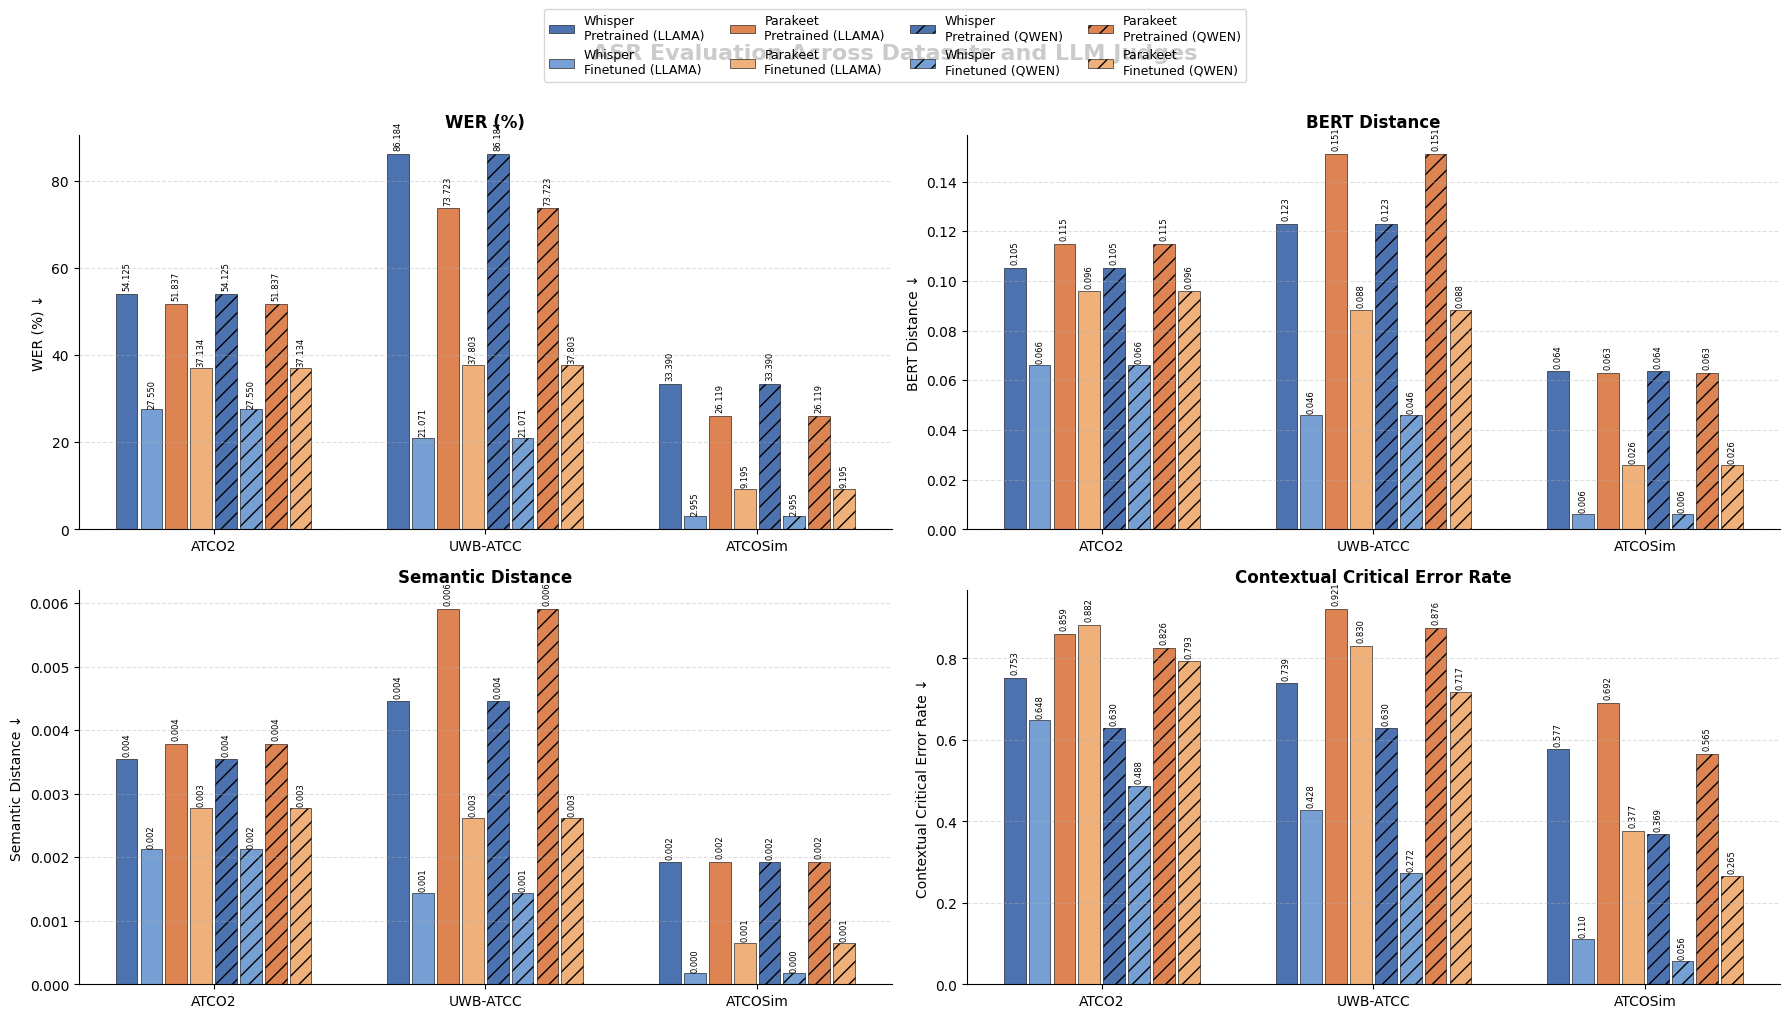

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load
# ============================================================

df = pd.read_csv("/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/eval_cache/all_results.csv")

# ============================================================
# Config
# ============================================================

DATASETS = ["atco2_ood", "uwb_atcc_test", "atcosim_test"]

DATASET_LABELS = {
    "atco2_ood": "ATCO2",
    "uwb_atcc_test": "UWB-ATCC",
    "atcosim_test": "ATCOSim",
}

MODEL_ORDER = [
    ("whisper-medium", "pretrained"),
    ("whisper-medium", "combined"),
    ("parakeet-tdt-0.6b-v3", "pretrained"),
    ("parakeet-tdt-0.6b-v3", "combined"),
]

MODEL_LABELS = {
    ("whisper-medium", "pretrained"): "Whisper\nPretrained",
    ("whisper-medium", "combined"): "Whisper\nFinetuned",
    ("parakeet-tdt-0.6b-v3", "pretrained"): "Parakeet\nPretrained",
    ("parakeet-tdt-0.6b-v3", "combined"): "Parakeet\nFinetuned",
}

COLORS = {
    ("whisper-medium", "pretrained"): "#4C72B0",
    ("whisper-medium", "combined"): "#76A0D4",
    ("parakeet-tdt-0.6b-v3", "pretrained"): "#DD8452",
    ("parakeet-tdt-0.6b-v3", "combined"): "#F0B07A",
}

METRICS = {
    "WER": ("WER (%)", "lower"),
    "BERTDist": ("BERT Distance", "lower"),
    "SemDist": ("Semantic Distance", "lower"),
    "CCER": ("Contextual Critical Error Rate", "lower"),
}

JUDGES = ["llama", "qwen"]

# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

bar_width = 0.08

for ax, (metric, (ylabel, direction)) in zip(axes, METRICS.items()):

    x = np.arange(len(DATASETS))

    total_bars = len(MODEL_ORDER) * len(JUDGES)

    offsets = np.linspace(
        -bar_width * total_bars / 2,
        bar_width * total_bars / 2,
        total_bars
    )

    offset_idx = 0

    for judge in JUDGES:

        for model_key in MODEL_ORDER:

            model, variant = model_key

            vals = []

            for ds in DATASETS:

                row = df[
                    (df["judge"] == judge) &
                    (df["model"] == model) &
                    (df["variant"] == variant) &
                    (df["dataset"] == ds)
                ]

                vals.append(row[metric].values[0])

            label = f"{MODEL_LABELS[model_key]} ({judge.upper()})"

            hatch = "//" if judge == "qwen" else None

            bars = ax.bar(
                x + offsets[offset_idx],
                vals,
                width=bar_width,
                label=label,
                color=COLORS[model_key],
                hatch=hatch,
                edgecolor="black",
                linewidth=0.4,
            )

            # Value labels
            for bar, val in zip(bars, vals):

                y_offset = max(vals) * 0.01

                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + y_offset,
                    f"{val:.3f}",
                    ha="center",
                    va="bottom",
                    fontsize=6,
                    rotation=90,
                )

            offset_idx += 1

    ax.set_title(ylabel, fontsize=12, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(
        [DATASET_LABELS[d] for d in DATASETS],
        fontsize=10,
    )

    ax.grid(axis="y", linestyle="--", alpha=0.4)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if direction == "lower":
        ax.set_ylabel(f"{ylabel} ↓")
    else:
        ax.set_ylabel(f"{ylabel} ↑")

# ============================================================
# Shared legend
# ============================================================

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    fontsize=9,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle(
    "ASR Evaluation Across Datasets and LLM Judges",
    fontsize=16,
    fontweight="bold",
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    "combined_metrics_plot.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

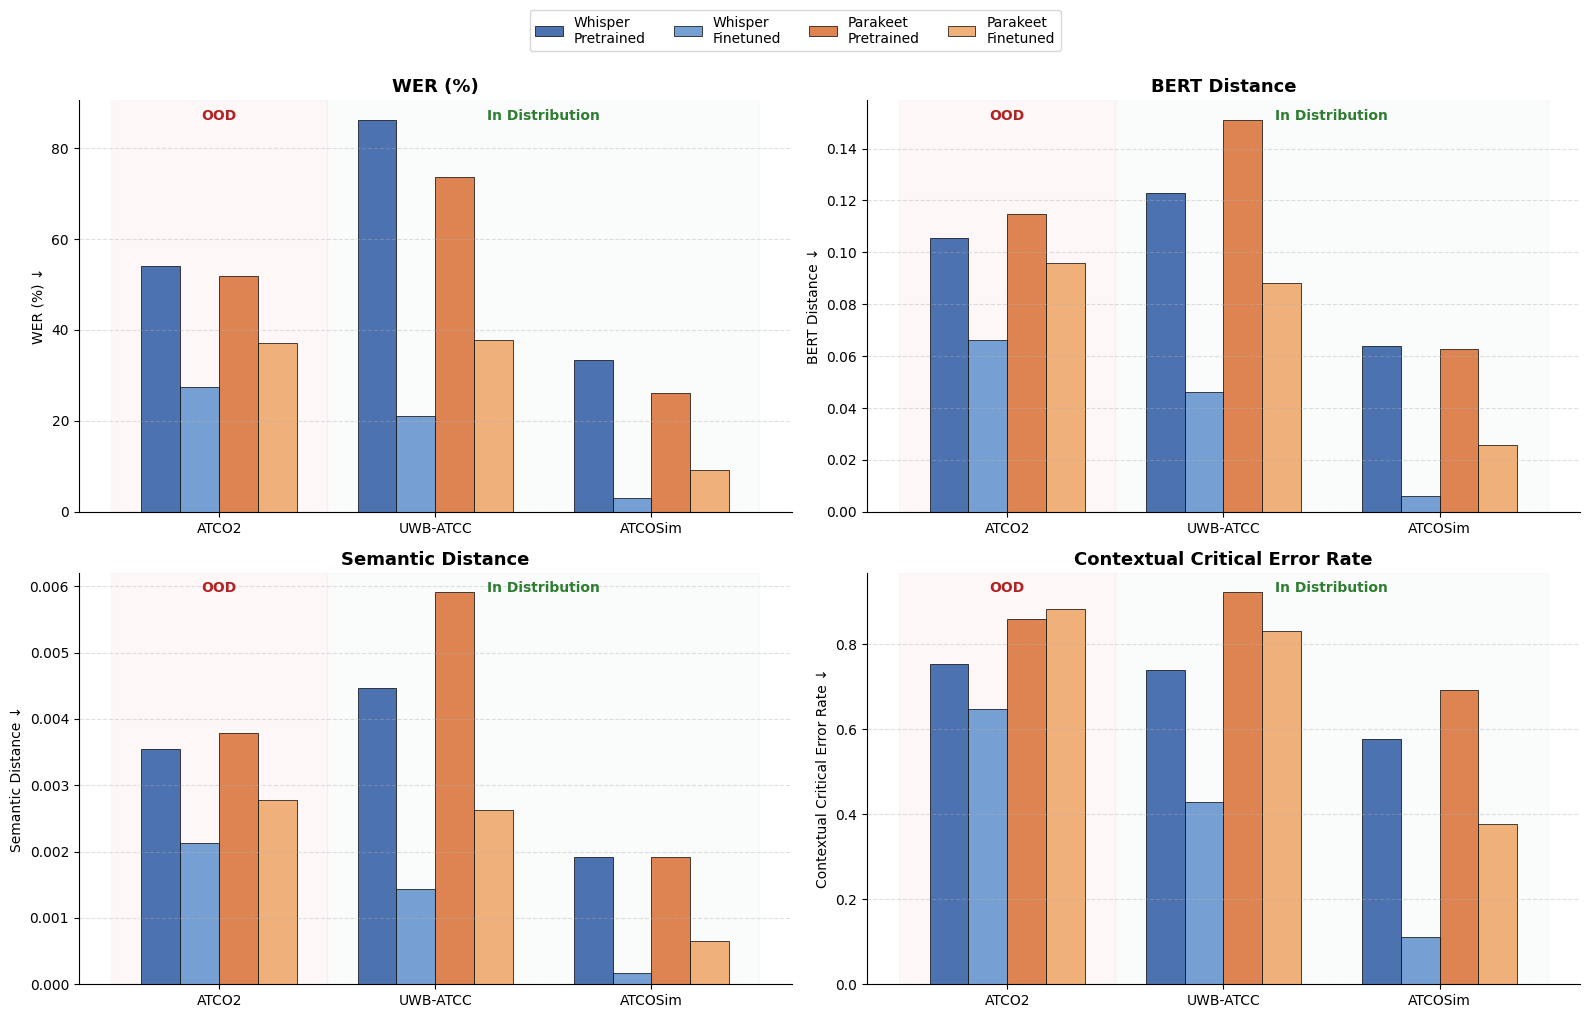

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load only llama results
# ============================================================

df = pd.read_csv("eval_cache/all_results.csv")
df = df[df["judge"] == "llama"]

# ============================================================
# Config
# ============================================================

DATASETS = ["atco2_ood", "uwb_atcc_test", "atcosim_test"]

DATASET_LABELS = {
    "atco2_ood": "ATCO2",
    "uwb_atcc_test": "UWB-ATCC",
    "atcosim_test": "ATCOSim",
}

MODEL_ORDER = [
    ("whisper-medium", "pretrained"),
    ("whisper-medium", "combined"),
    ("parakeet-tdt-0.6b-v3", "pretrained"),
    ("parakeet-tdt-0.6b-v3", "combined"),
]

MODEL_LABELS = {
    ("whisper-medium", "pretrained"): "Whisper\nPretrained",
    ("whisper-medium", "combined"): "Whisper\nFinetuned",
    ("parakeet-tdt-0.6b-v3", "pretrained"): "Parakeet\nPretrained",
    ("parakeet-tdt-0.6b-v3", "combined"): "Parakeet\nFinetuned",
}

COLORS = {
    ("whisper-medium", "pretrained"): "#4C72B0",
    ("whisper-medium", "combined"): "#76A0D4",
    ("parakeet-tdt-0.6b-v3", "pretrained"): "#DD8452",
    ("parakeet-tdt-0.6b-v3", "combined"): "#F0B07A",
}

METRICS = {
    "WER": ("WER (%)", "lower"),
    "BERTDist": ("BERT Distance", "lower"),
    "SemDist": ("Semantic Distance", "lower"),
    "CCER": ("Contextual Critical Error Rate", "lower"),
}

# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

bar_width = 0.18
x = np.arange(len(DATASETS))

for ax, (metric, (ylabel, direction)) in zip(axes, METRICS.items()):

    offsets = np.linspace(
        -1.5 * bar_width,
        1.5 * bar_width,
        len(MODEL_ORDER)
    )

    for offset, model_key in zip(offsets, MODEL_ORDER):

        model, variant = model_key

        vals = []

        for ds in DATASETS:

            row = df[
                (df["model"] == model) &
                (df["variant"] == variant) &
                (df["dataset"] == ds)
            ]

            vals.append(row[metric].values[0])

        bars = ax.bar(
            x + offset,
            vals,
            width=bar_width,
            label=MODEL_LABELS[model_key],
            color=COLORS[model_key],
            edgecolor="black",
            linewidth=0.5,
        )

        # Value labels
        # for bar, val in zip(bars, vals):

        #     y_offset = max(vals) * 0.01 if max(vals) > 1 else 0.002

        #     ax.text(
        #         bar.get_x() + bar.get_width()/2,
        #         bar.get_height() + y_offset,
        #         f"{val:.3f}",
        #         ha="center",
        #         va="bottom",
        #         fontsize=7,
        #         rotation=90,
        #     )

    # Background
    ax.axvspan(-0.5, 0.5, color="#f8d7da", alpha=0.18, zorder=0)
    ax.axvspan(0.5, 2.5, color="#d4edda", alpha=0.12, zorder=0)

    ax.text(
        0,
        0.98,
        "OOD",
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=10,
        color="#b22222",
        fontweight="bold",
    )

    ax.text(
        1.5,
        0.98,
        "In Distribution",
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=10,
        color="#2e7d32",
        fontweight="bold",
    )
    


    ax.set_title(
        ylabel,
        fontsize=13,
        fontweight="bold",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [DATASET_LABELS[d] for d in DATASETS],
        fontsize=10,
    )

    ax.grid(axis="y", linestyle="--", alpha=0.4)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if direction == "lower":
        ax.set_ylabel(f"{ylabel} ↓")
    else:
        ax.set_ylabel(f"{ylabel} ↑")



# ============================================================
# Shared legend
# ============================================================

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    fontsize=10,
    bbox_to_anchor=(0.5, 1.02),
)

# fig.suptitle(
#     "ASR System Evaluation Across Air Traffic Control Datasets",
#     fontsize=18,
#     fontweight="bold",
# )

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    "llama_metrics_combined.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

✓ Saved: ccer_improvement_gap.png


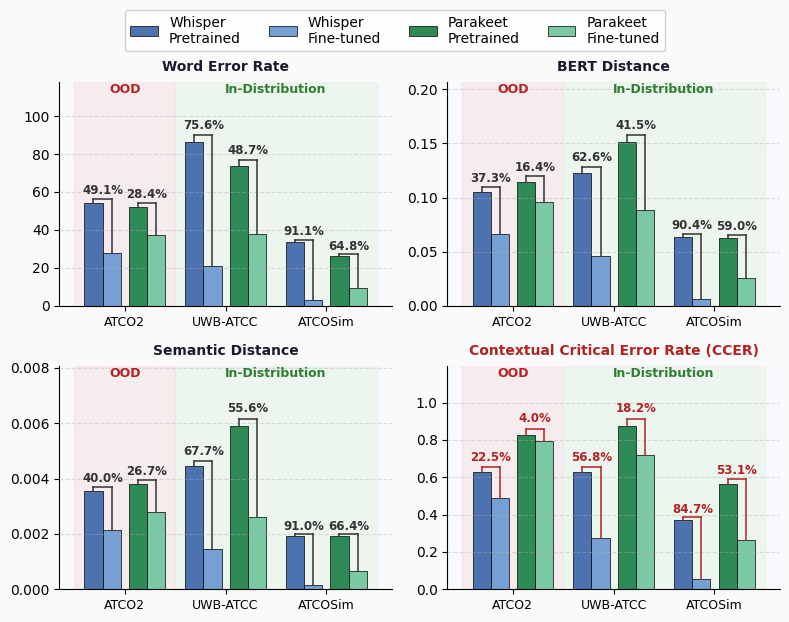

In [ ]:
"""
ccer_improvement_gap.py
=======================
Original grouped bar chart (pretrained vs fine-tuned) with % improvement
annotations bracketed between each model pair. Clean, uncluttered.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# Load & filter
# ─────────────────────────────────────────────

df = pd.read_csv("eval_cache/all_results.csv")
df = df[df["judge"] == "qwen"]

# ─────────────────────────────────────────────
# Config
# ─────────────────────────────────────────────

DATASETS = ["atco2_ood", "uwb_atcc_test", "atcosim_test"]
DATASET_LABELS = {
    "atco2_ood":     "ATCO2",
    "uwb_atcc_test": "UWB-ATCC",
    "atcosim_test":  "ATCOSim",
}

PAIRS = [
    ("whisper-medium",        "pretrained", "combined"),
    ("parakeet-tdt-0.6b-v3", "pretrained", "combined"),
]

MODEL_ORDER = [
    ("whisper-medium",        "pretrained"),
    ("whisper-medium",        "combined"),
    ("parakeet-tdt-0.6b-v3", "pretrained"),
    ("parakeet-tdt-0.6b-v3", "combined"),
]

MODEL_LABELS = {
    ("whisper-medium",        "pretrained"): "Whisper\nPretrained",
    ("whisper-medium",        "combined"):   "Whisper\nFine-tuned",
    ("parakeet-tdt-0.6b-v3", "pretrained"): "Parakeet\nPretrained",
    ("parakeet-tdt-0.6b-v3", "combined"):   "Parakeet\nFine-tuned",
}

# COLORS = {
#     ("whisper-medium",        "pretrained"): "#4C72B0",
#     ("whisper-medium",        "combined"):   "#76A0D4",
#     ("parakeet-tdt-0.6b-v3", "pretrained"): "#CC6633",
#     ("parakeet-tdt-0.6b-v3", "combined"):   "#F0A070",
# }

COLORS = {
    ("whisper-medium",        "pretrained"): "#4C72B0",  # deep blue
    ("whisper-medium",        "combined"):   "#76A0D4",  # light blue

    ("parakeet-tdt-0.6b-v3", "pretrained"): "#2E8B57",  # sea green
    ("parakeet-tdt-0.6b-v3", "combined"):   "#7BC8A4",  # soft mint green
}



METRICS = {
    "WER":      "Word Error Rate",
    "BERTDist": "BERT Distance",
    "SemDist":  "Semantic Distance",
    "CCER":     "Contextual Critical Error Rate (CCER)",
}

# ─────────────────────────────────────────────
# Helper: bracket + % improvement annotation
# ─────────────────────────────────────────────

def annotate_improvement(ax, x_pre, x_ft, y_pre, y_ft, pct, is_ccer=False):
    """
    Draw a small bracket above the pretrained/finetuned bar pair and
    label it with the % improvement.
    """
    x_mid  = (x_pre + x_ft) / 2
    y_top  = max(y_pre, y_ft)
    cap    = y_top * 0.07
    y_line = y_top + cap * 0.6

    color = "#B22222" if is_ccer else "#333333"
    lw    = 1.1

    ax.plot([x_pre, x_pre], [y_pre, y_line], color=color, lw=lw, clip_on=False)
    ax.plot([x_ft,  x_ft],  [y_ft,  y_line], color=color, lw=lw, clip_on=False)
    ax.plot([x_pre, x_ft],  [y_line, y_line], color=color, lw=lw, clip_on=False)

    # sign  = "↓" if pct >= 0 else "↑"
    # label = f"{abs(pct):.1f}%{sign}"
    label = f"{abs(pct):.1f}%"

    ax.text(
        x_mid,
        y_line + cap * 0.3,
        label,
        ha="center",
        va="bottom",
        fontsize=8.5,
        fontweight="bold",
        color=color,
        clip_on=False,
    )

# ─────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────

# fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
fig.patch.set_facecolor("#FAFAFA")
axes = axes.flatten()

bar_width = 0.18
x         = np.arange(len(DATASETS))
gap       = 0.04

offsets = {
    ("whisper-medium",        "pretrained"): -1.5 * bar_width - gap,
    ("whisper-medium",        "combined"):   -0.5 * bar_width - gap,
    ("parakeet-tdt-0.6b-v3", "pretrained"):  0.5 * bar_width + gap,
    ("parakeet-tdt-0.6b-v3", "combined"):    1.5 * bar_width + gap,
}

for ax, (metric, ylabel) in zip(axes, METRICS.items()):

    is_ccer = (metric == "CCER")
    bar_map = {}

    # ── Bars ─────────────────────────────────────────────────────────────
    for model_key in MODEL_ORDER:
        model, variant = model_key
        vals = []
        for ds in DATASETS:
            row = df[
                (df["model"] == model) &
                (df["variant"] == variant) &
                (df["dataset"] == ds)
            ]
            vals.append(row[metric].values[0])

        xs   = x + offsets[model_key]
        bars = ax.bar(
            xs, vals,
            width=bar_width,
            label=MODEL_LABELS[model_key],
            color=COLORS[model_key],
            edgecolor="black",
            linewidth=0.5,
        )

        for i, (bar, val) in enumerate(zip(bars, vals)):
            bar_map[(model_key, i)] = (bar.get_x() + bar.get_width() / 2, val)

    # ── % improvement brackets ────────────────────────────────────────────
    for model, pre_var, ft_var in PAIRS:
        pre_key = (model, pre_var)
        ft_key  = (model, ft_var)
        for ds_idx, ds in enumerate(DATASETS):
            x_pre, h_pre = bar_map[(pre_key, ds_idx)]
            x_ft,  h_ft  = bar_map[(ft_key,  ds_idx)]

            pre_val = df[
                (df["model"] == model) & (df["variant"] == pre_var) & (df["dataset"] == ds)
            ][metric].values[0]
            ft_val = df[
                (df["model"] == model) & (df["variant"] == ft_var) & (df["dataset"] == ds)
            ][metric].values[0]

            pct = (pre_val - ft_val) / pre_val * 100.0

            annotate_improvement(ax, x_pre, x_ft, h_pre, h_ft, pct, is_ccer=is_ccer)

    # ── OOD / In-Domain shading ───────────────────────────────────────────
    # ax.axvspan(-0.5, 0.5, color="#fde8e8", alpha=0.7, zorder=0)
    # ax.axvspan(0.5,  2.5, color="#e8f5e9", alpha=0.7, zorder=0)
    ax.axvspan(-0.5, 0.5, color="#F6D6D6", alpha=0.35, zorder=0)  # soft muted red
    ax.axvspan(0.5,  2.5, color="#DCEFD9", alpha=0.35, zorder=0)  # soft muted green

    ax.text(0,   0.995, "OOD",
            transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=9, color="#B22222", fontweight="bold")
    ax.text(1.5, 0.995, "In-Distribution",
            transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=9, color="#2E7D32", fontweight="bold")

    # ── Titles, ticks, style ──────────────────────────────────────────────
    title_color = "#B22222" if is_ccer else "#1A1A2E"
    ax.set_title(ylabel, fontsize=10, fontweight="bold", color=title_color, pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels([DATASET_LABELS[d] for d in DATASETS], fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_facecolor("#F7F9FC")

    # Extra top margin so brackets don't clip
    ymax = ax.get_ylim()[1]
    ax.set_ylim(0, ymax * 1.25)

# ─────────────────────────────────────────────
# Shared legend
# ─────────────────────────────────────────────

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=4,
    fontsize=10,
    bbox_to_anchor=(0.5, 1.04),
    framealpha=0.9,
    edgecolor="#CCC",
)


# fig.suptitle(
#     "Fine-tuning Reduces Surface Errors Aggressively — "
#     "But Contextual Errors (CCER) Remain Largely Intact",
#     fontsize=13,
#     fontweight="bold",
#     color="#1A1A2E",
#     y=1.07,
# )

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    "ccer_improvement_gap.png",
    dpi=600,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)

print("✓ Saved: ccer_improvement_gap.png")
plt.show()

In [1]:
import pandas as pd

df = pd.read_csv("eval_cache/all_results.csv")
df = df[df["judge"] == "qwen"]

DATASETS = ["atco2_ood", "uwb_atcc_test", "atcosim_test"]
METRICS = ["WER", "BERTDist", "SemDist", "CCER"]

models = [
    ("whisper-medium",        "pretrained"),
    ("whisper-medium",        "combined"),
    ("parakeet-tdt-0.6b-v3", "pretrained"),
    ("parakeet-tdt-0.6b-v3", "combined"),
]

for ds in DATASETS:
    print(f"\n=== {ds} ===")
    for model, variant in models:
        row = df[
            (df["model"] == model) &
            (df["variant"] == variant) &
            (df["dataset"] == ds)
        ]
        if len(row) == 0:
            print(f"  {model} | {variant}: NO DATA")
            continue
        vals = {m: row[m].values[0] for m in METRICS}
        print(f"  {model} | {variant}: " + 
              " | ".join(f"{m}={vals[m]:.4f}" for m in METRICS))


=== atco2_ood ===
  whisper-medium | pretrained: WER=54.1246 | BERTDist=0.1054 | SemDist=0.0035 | CCER=0.6299
  whisper-medium | combined: WER=27.5499 | BERTDist=0.0661 | SemDist=0.0021 | CCER=0.4879
  parakeet-tdt-0.6b-v3 | pretrained: WER=51.8370 | BERTDist=0.1147 | SemDist=0.0038 | CCER=0.8257
  parakeet-tdt-0.6b-v3 | combined: WER=37.1344 | BERTDist=0.0959 | SemDist=0.0028 | CCER=0.7928

=== uwb_atcc_test ===
  whisper-medium | pretrained: WER=86.1836 | BERTDist=0.1231 | SemDist=0.0045 | CCER=0.6296
  whisper-medium | combined: WER=21.0706 | BERTDist=0.0460 | SemDist=0.0014 | CCER=0.2723
  parakeet-tdt-0.6b-v3 | pretrained: WER=73.7233 | BERTDist=0.1511 | SemDist=0.0059 | CCER=0.8758
  parakeet-tdt-0.6b-v3 | combined: WER=37.8028 | BERTDist=0.0883 | SemDist=0.0026 | CCER=0.7166

=== atcosim_test ===
  whisper-medium | pretrained: WER=33.3904 | BERTDist=0.0637 | SemDist=0.0019 | CCER=0.3689
  whisper-medium | combined: WER=2.9553 | BERTDist=0.0061 | SemDist=0.0002 | CCER=0.0564
  p

Saved: wer_vs_ccer_atcosim_test.png


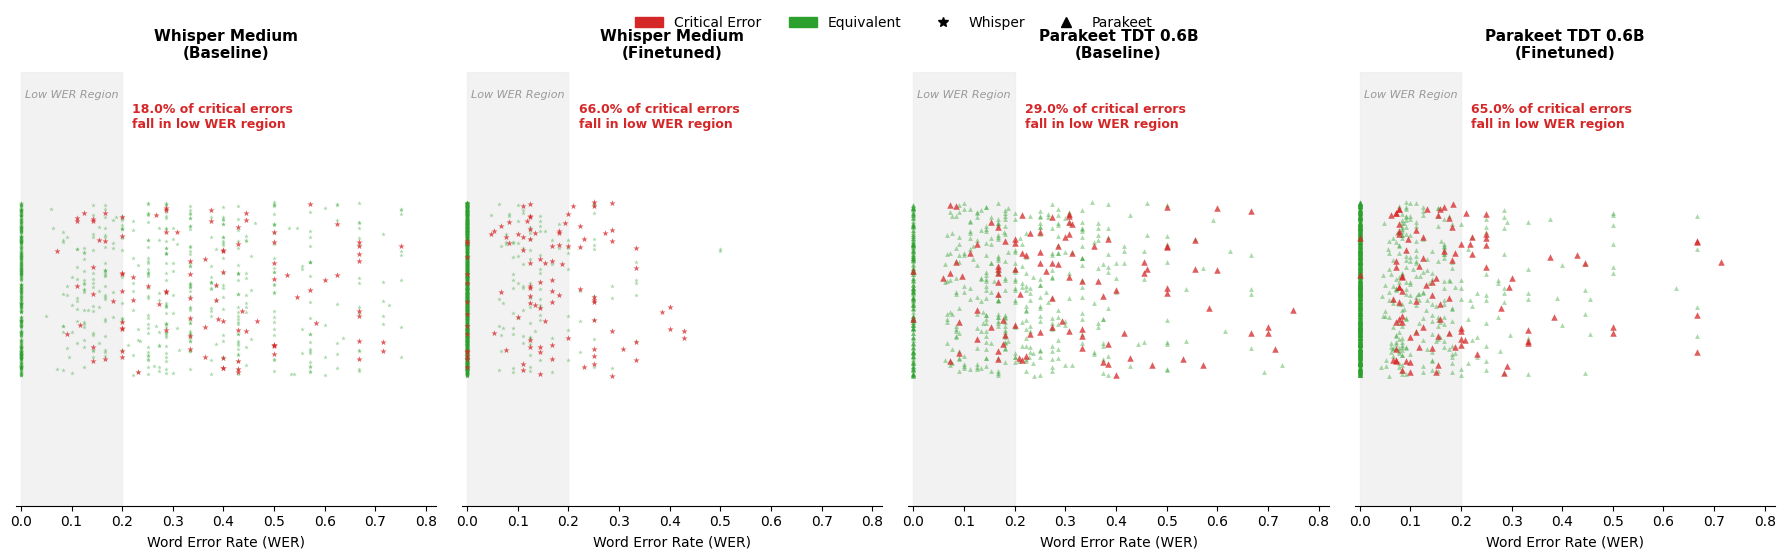

In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/llama_70b_annotation"

DATASET = "atcosim_test"   # change this to switch datasets

FILES = {
    "Whisper Medium\n(Baseline)":
        "whisper-medium_pretrained_" + DATASET + "_predictions.json",

    "Whisper Medium\n(Finetuned)":
        "whisper-medium-combined_" + DATASET + "_predictions.json",

    "Parakeet TDT 0.6B\n(Baseline)":
        "parakeet-tdt-0.6b-v3_pretrained_" + DATASET + "_predictions.json",

    "Parakeet TDT 0.6B\n(Finetuned)":
        "parakeet-tdt-0.6b-v3-combined_" + DATASET + "_predictions.json",
}

# Same colors as your original plot
COLOR = {
    "Critical_Errors": "#d62728",
    "Equivalent": "#2ca02c",
}

# ONLY model-type-specific shapes
MARKERS = {
    "Whisper": "*",     # circle
    "Parakeet": "^",    # triangle
}

rng = np.random.default_rng(42)

# ============================================================
# LOAD JSON
# ============================================================

def load_records(filename):
    path = os.path.join(BASE_DIR, filename)

    with open(path) as f:
        data = json.load(f)

    return data["records"]

# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(18, 5.5), sharey=True)

for ax_idx, (ax, (title, filename)) in enumerate(zip(axes, FILES.items())):

    records = load_records(filename)

    # keep only valid evaluated samples
    records = [
        r for r in records
        if r["contextual_status"] in ("Critical_Errors", "Equivalent")
        and r["WER"] <= 0.8
    ]
    # keep only random subset of critical samples
    records = rng.choice(
        [r for r in records if r["contextual_status"] == "Critical_Errors"],
        size=min(100, sum(r["contextual_status"] == "Critical_Errors" for r in records)),
        replace=False
    ).tolist() + [
        r for r in records if r["contextual_status"] == "Equivalent"
    ]
    wers = np.array([r["WER"] for r in records])
    statuses = [r["contextual_status"] for r in records]

    jitter = rng.uniform(-0.4, 0.4, size=len(wers))

    # Determine marker by model family
    marker = MARKERS["Whisper"] if "Whisper" in title else MARKERS["Parakeet"]

    # ========================================================
    # Low-WER shaded region
    # ========================================================

    ax.axvspan(0, 0.2, color="#efefef", alpha=0.8, zorder=0)

    ax.text(
        0.10,
        0.96,
        "Low WER Region",
        transform=ax.get_xaxis_transform(),
        fontsize=8,
        color="#999999",
        verticalalignment="top",
        style="italic",
        ha="center",
    )

    # ========================================================
    # Scatter points
    # ========================================================

    for status in ["Equivalent", "Critical_Errors"]:

        mask = np.array([s == status for s in statuses])

        ax.scatter(
            wers[mask],
            jitter[mask],
            c=COLOR[status],
            marker=marker,
            alpha=0.40 if status == "Equivalent" else 0.75,
            s=12 if status == "Equivalent" else 22,
            linewidths=0,
            zorder=1 if status == "Equivalent" else 2,
        )

    # ========================================================
    # % critical errors in low-WER region
    # ========================================================

    crit_wers = wers[[s == "Critical_Errors" for s in statuses]]

    pct_low = (
        100 * np.sum(crit_wers < 0.2) / len(crit_wers)
        if len(crit_wers) > 0 else 0
    )

    ax.text(
        0.22,
        0.93,
        f"{pct_low:.1f}% of critical errors\nfall in low WER region",
        transform=ax.get_xaxis_transform(),
        fontsize=9,
        color="#d62728",
        verticalalignment="top",
        fontweight="bold",
    )

    # ========================================================
    # Axis styling
    # ========================================================

    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)

    ax.set_xlabel("Word Error Rate (WER)", fontsize=10)

    ax.set_xlim(-0.01, 0.82)
    ax.set_ylim(-1, 1)

    ax.set_yticks([])

    ax.spines["left"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ============================================================
# LEGENDS
# ============================================================

# Color legend
status_handles = [
    mpatches.Patch(
        color=COLOR["Critical_Errors"],
        label="Critical Error"
    ),
    mpatches.Patch(
        color=COLOR["Equivalent"],
        label="Equivalent"
    ),
]

# Shape legend
shape_handles = [
    Line2D(
        [0], [0],
        marker="*",
        color="black",
        linestyle="None",
        markersize=7,
        label="Whisper"
    ),
    Line2D(
        [0], [0],
        marker="^",
        color="black",
        linestyle="None",
        markersize=7,
        label="Parakeet"
    ),
]

fig.legend(
    handles=status_handles + shape_handles,
    loc="upper center",
    ncol=4,
    fontsize=10,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)

# fig.suptitle(
#     f"Low WER Does Not Imply Operational Safety ({DATASET})",
#     fontsize=14,
#     fontweight="bold",
#     y=1.06,
# )

plt.tight_layout()

out_path = f"wer_vs_ccer_{DATASET}.png"

plt.savefig(out_path, dpi=600, bbox_inches="tight")

print(f"Saved: {out_path}")

Saved: wer_whisper_only_atcosim_test.png


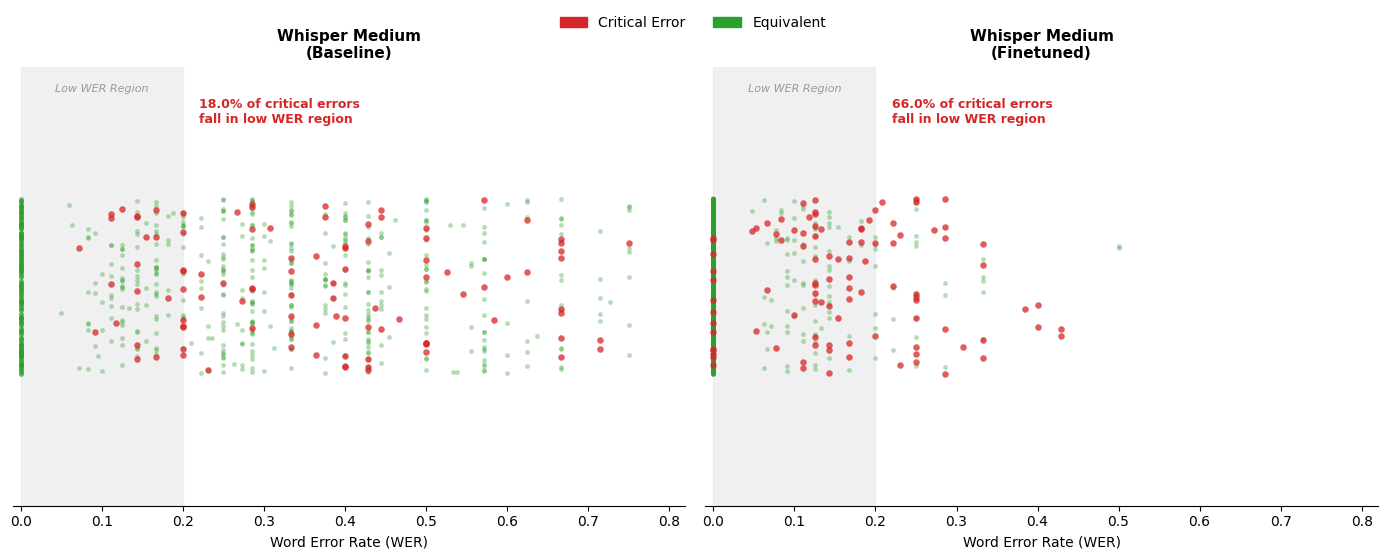

In [53]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/llama_70b_annotation"

DATASET = "atcosim_test"   # change dataset here

FILES = {
    "Whisper Medium\n(Baseline)":
        "whisper-medium_pretrained_" + DATASET + "_predictions.json",

    "Whisper Medium\n(Finetuned)":
        "whisper-medium-combined_" + DATASET + "_predictions.json",
}

COLOR = {
    "Critical_Errors": "#d62728",
    "Equivalent": "#2ca02c",
}

rng = np.random.default_rng(42)

# ============================================================
# LOAD
# ============================================================

def load_records(filename):
    path = os.path.join(BASE_DIR, filename)
    with open(path) as f:
        data = json.load(f)
    return data["records"]

# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for ax, (title, filename) in zip(axes, FILES.items()):

    records = load_records(filename)

    # --------------------------------------------------------
    # filter valid records
    # --------------------------------------------------------
    records = [
        r for r in records
        if r["contextual_status"] in ("Critical_Errors", "Equivalent")
        and r["WER"] <= 0.8
    ]

    # --------------------------------------------------------
    # downsample ONLY critical errors (avoid red overload)
    # --------------------------------------------------------
    critical = [r for r in records if r["contextual_status"] == "Critical_Errors"]
    equivalent = [r for r in records if r["contextual_status"] == "Equivalent"]

    if len(critical) > 100:
        critical = list(rng.choice(critical, size=100, replace=False))

    records = critical + equivalent

    wers = np.array([r["WER"] for r in records])
    statuses = [r["contextual_status"] for r in records]

    jitter = rng.uniform(-0.4, 0.4, size=len(wers))

    # --------------------------------------------------------
    # background region
    # --------------------------------------------------------
    ax.axvspan(0, 0.2, color="#efefef", alpha=0.9, zorder=0)
    ax.text(
        0.10, 0.96, "Low WER Region",
        transform=ax.get_xaxis_transform(),
        fontsize=8, color="#999999",
        va="top", ha="center", style="italic"
    )

    # --------------------------------------------------------
    # scatter
    # --------------------------------------------------------
    for status in ["Equivalent", "Critical_Errors"]:
        mask = np.array([s == status for s in statuses])

        ax.scatter(
            wers[mask],
            jitter[mask],
            c=COLOR[status],
            marker="o",
            alpha=0.35 if status == "Equivalent" else 0.75,
            s=12 if status == "Equivalent" else 22,
            linewidths=0
        )

    # --------------------------------------------------------
    # % critical in low WER region
    # --------------------------------------------------------
    crit_wers = np.array([r["WER"] for r in records if r["contextual_status"] == "Critical_Errors"])

    pct_low = (
        100 * np.sum(crit_wers < 0.2) / len(crit_wers)
        if len(crit_wers) > 0 else 0
    )

    ax.text(
        0.22, 0.93,
        f"{pct_low:.1f}% of critical errors\nfall in low WER region",
        transform=ax.get_xaxis_transform(),
        fontsize=9,
        color="#d62728",
        fontweight="bold",
        va="top"
    )

    # --------------------------------------------------------
    # styling
    # --------------------------------------------------------
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Word Error Rate (WER)", fontsize=10)
    ax.set_xlim(-0.01, 0.82)
    ax.set_ylim(-1, 1)
    ax.set_yticks([])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

# ============================================================
# LEGEND
# ============================================================

handles = [
    mpatches.Patch(color=COLOR["Critical_Errors"], label="Critical Error"),
    mpatches.Patch(color=COLOR["Equivalent"], label="Equivalent"),
    # Line2D([0], [0], marker="*", color="black", linestyle="None",
    #        markersize=8, label="Whisper")
]

fig.legend(
    handles=handles,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

# fig.suptitle(
#     f"Low WER Does Not Imply Operational Safety ({DATASET})",
#     fontsize=13,
#     fontweight="bold",
#     y=1.05
# )

plt.tight_layout()

out_path = f"wer_whisper_only_{DATASET}.png"
plt.savefig(out_path, dpi=600, bbox_inches="tight")

print(f"Saved: {out_path}")

Fixed threshold (25th pct of baseline): 0.125
Saved: wer_whisper_only_atcosim_test.png


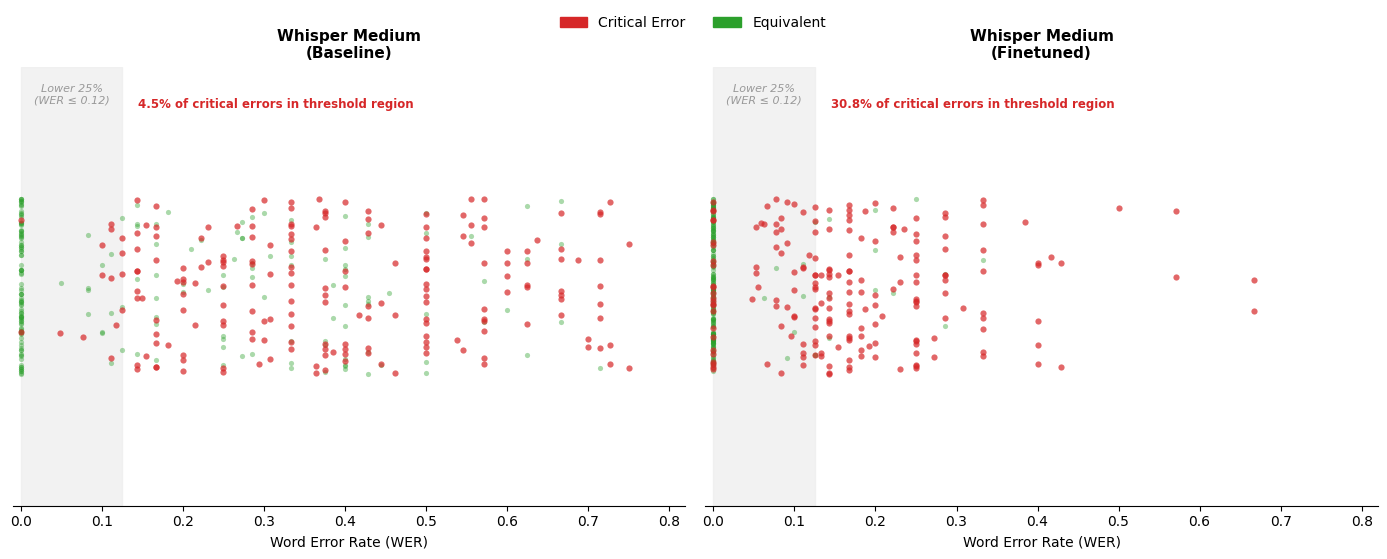

In [54]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/llama_70b_annotation"
DATASET  = "atcosim_test"

FILES = {
    "Whisper Medium\n(Baseline)":
        "whisper-medium_pretrained_" + DATASET + "_predictions.json",
    "Whisper Medium\n(Finetuned)":
        "whisper-medium-combined_" + DATASET + "_predictions.json",
}

COLOR = {"Critical_Errors": "#d62728", "Equivalent": "#2ca02c"}
rng   = np.random.default_rng(42)
N_EACH = 200   # show this many of each class per subplot

# ============================================================
# LOAD
# ============================================================

def load_records(filename):
    with open(os.path.join(BASE_DIR, filename)) as f:
        return json.load(f)["records"]

def get_valid(records):
    return [r for r in records
            if r["contextual_status"] in ("Critical_Errors", "Equivalent")
            and r["WER"] <= 0.8]

# ============================================================
# COMPUTE FIXED THRESHOLD FROM BASELINE
# ============================================================

baseline_file = list(FILES.values())[0]
baseline_records = get_valid(load_records(baseline_file))
baseline_wers    = np.array([r["WER"] for r in baseline_records])
THRESHOLD = np.percentile(baseline_wers, 25)
print(f"Fixed threshold (25th pct of baseline): {THRESHOLD:.3f}")

# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for ax, (title, filename) in zip(axes, FILES.items()):

    records    = get_valid(load_records(filename))
    critical   = [r for r in records if r["contextual_status"] == "Critical_Errors"]
    equivalent = [r for r in records if r["contextual_status"] == "Equivalent"]

    # honest stats on full data
    crit_wers_full = np.array([r["WER"] for r in critical])
    eq_wers_full   = np.array([r["WER"] for r in equivalent])
    pct_crit_in_threshold = 100 * np.sum(crit_wers_full < THRESHOLD) / len(crit_wers_full) if len(crit_wers_full) else 0
    total = len(critical) + len(equivalent)
    pct_critical_overall  = 100 * len(critical) / total if total else 0

    # balanced downsample for display
    n_crit = min(N_EACH, len(critical))
    n_eq   = min(N_EACH, len(equivalent))
    critical_plot   = list(rng.choice(critical,   size=n_crit, replace=False))
    equivalent_plot = list(rng.choice(equivalent, size=n_eq,   replace=False))

    plot_records = critical_plot + equivalent_plot
    wers         = np.array([r["WER"] for r in plot_records])
    statuses     = [r["contextual_status"] for r in plot_records]
    jitter        = rng.uniform(-0.4, 0.4, size=len(wers))

    # background
    ax.axvspan(0, THRESHOLD, color="#efefef", alpha=0.8, zorder=0)
    ax.text(
        THRESHOLD / 2, 0.96, f"Lower 25%\n(WER ≤ {THRESHOLD:.2f})",
        transform=ax.get_xaxis_transform(),
        fontsize=8, color="#999999", va="top", ha="center", style="italic"
    )

    # scatter — equivalent first, critical on top
    for status in ["Equivalent", "Critical_Errors"]:
        mask = np.array([s == status for s in statuses])
        ax.scatter(
            wers[mask], jitter[mask],
            c=COLOR[status], marker="o",
            alpha=0.4 if status == "Equivalent" else 0.7,
            s=14  if status == "Equivalent" else 20,
            linewidths=0
        )

    # annotations
    ax.text(
        THRESHOLD + 0.02, 0.93,
        f"{pct_crit_in_threshold:.1f}% of critical errors in threshold region",
        transform=ax.get_xaxis_transform(),
        fontsize=8.5, color="#d62728", fontweight="bold", va="top"
    )
    # ax.text(
    #     THRESHOLD + 0.02, 0.75,
    #     f"Overall CCER: {pct_critical_overall:.1f}%\n(n={len(critical)} critical / {total} total)",
    #     transform=ax.get_xaxis_transform(),
    #     fontsize=8, color="#555555", va="top"
    # )

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Word Error Rate (WER)", fontsize=10)
    ax.set_xlim(-0.01, 0.82)
    ax.set_ylim(-1, 1)
    ax.set_yticks([])
    ax.spines[["top", "right", "left"]].set_visible(False)

# ============================================================
# LEGEND  +  note about balanced display
# ============================================================

fig.legend(
    handles=[
        mpatches.Patch(color=COLOR["Critical_Errors"], label="Critical Error"),
        mpatches.Patch(color=COLOR["Equivalent"],      label="Equivalent"),
    ],
    loc="upper center", ncol=2, frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

# fig.text(0.5, -0.02,
#          f"Note: {N_EACH} samples shown per class for visual clarity. "
#          f"Percentages computed on full data.",
#          ha="center", fontsize=8, color="gray")

plt.tight_layout()
out_path = f"wer_whisper_only_{DATASET}.png"
plt.savefig(out_path, dpi=600, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

In [56]:
import json
import numpy as np
import os

BASE_DIR = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/llama_70b_annotation"
DATASET  = "atcosim_test"

file_path = os.path.join(
    BASE_DIR,
    f"whisper-medium_pretrained_{DATASET}_predictions.json"
)

with open(file_path) as f:
    data = json.load(f)

records = data["records"]

# keep only valid ones
records = [
    r for r in records
    if r["contextual_status"] in ("Critical_Errors", "Equivalent")
    and r["WER"] <= 0.8
]

wers = np.array([r["WER"] for r in records])
statuses = np.array([r["contextual_status"] for r in records])

low_wer_threshold  = np.percentile(wers, 25)
high_wer_threshold = np.percentile(wers, 75)

# ============================================================
# CASE 1: Low WER but Critical Error
# ============================================================

low_critical = [
    r for r in records
    if r["contextual_status"] == "Critical_Errors"
    and r["WER"] <= low_wer_threshold
]

# ============================================================
# CASE 2: High WER but Equivalent
# ============================================================

high_equivalent = [
    r for r in records
    if r["contextual_status"] == "Equivalent"
    and r["WER"] >= high_wer_threshold
]

# ============================================================
# PRINT EXAMPLES
# ============================================================

print("\n" + "="*80)
print("LOW WER BUT CRITICAL ERRORS")
print("="*80)

for i, r in enumerate(low_critical[:10]):  # show top 10
    print(f"\nExample {i+1}")
    print(f"WER: {r['WER']:.3f}")
    print(f"REF: {r['reference']}")
    print(f"HYP: {r['hypothesis']}")
    print("-"*60)


print("\n" + "="*80)
print("HIGH WER BUT EQUIVALENT")
print("="*80)

for i, r in enumerate(high_equivalent[:10]):
    print(f"\nExample {i+1}")
    print(f"WER: {r['WER']:.3f}")
    print(f"REF: {r['reference']}")
    print(f"HYP: {r['hypothesis']}")
    print("-"*60)


LOW WER BUT CRITICAL ERRORS

Example 1
WER: 0.000
REF: yeah continue
HYP: yeah continue
------------------------------------------------------------

Example 2
WER: 0.000
REF: station calling
HYP: station calling
------------------------------------------------------------

Example 3
WER: 0.125
REF: netherlands 414 descend now to flight level 290
HYP: netherlands 4140 descend now to flight level 290
------------------------------------------------------------

Example 4
WER: 0.125
REF: jet aviation 701 is identified fly heading 250
HYP: jet division 701 is identified fly heading 250
------------------------------------------------------------

Example 5
WER: 0.125
REF: jet aviation 701 descend to flight level 250
HYP: jet division 701 descend to flight level 250
------------------------------------------------------------

Example 6
WER: 0.100
REF: air france 689 radar contact call you back with direct
HYP: air fall 689 radar contact call you back with direct
-------------------------

Fixed threshold (25th pct): 0.231
Saved: wer_whisper_only_atcosim_test.png


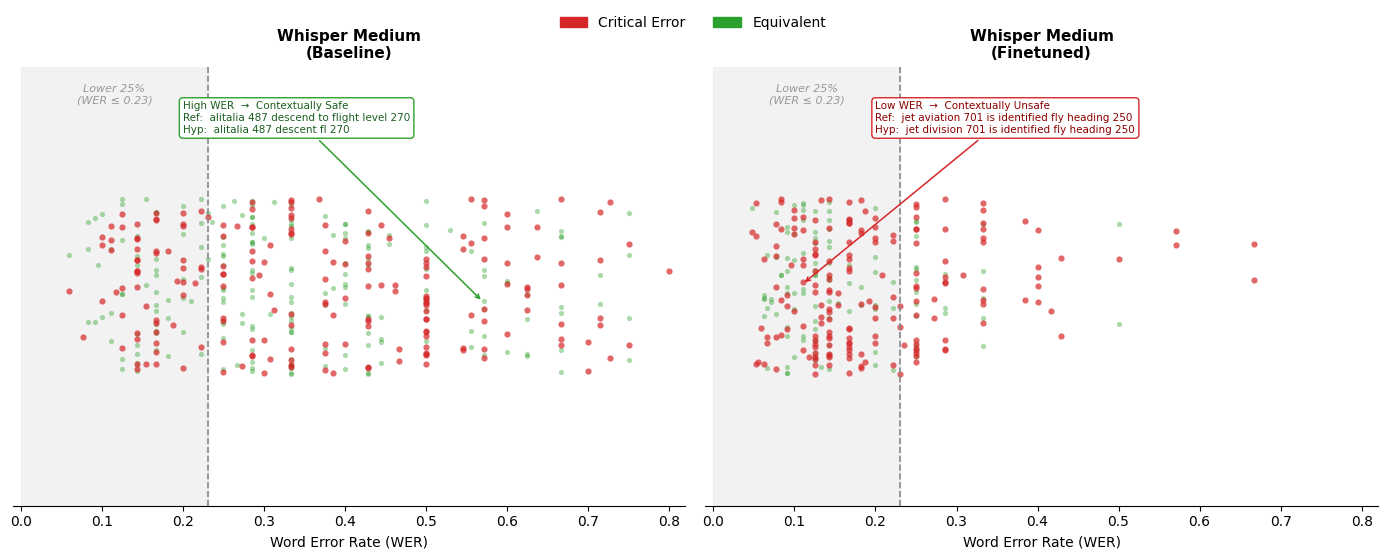

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/llama_70b_annotation"
DATASET  = "atcosim_test"

FILES = {
    "Whisper Medium\n(Baseline)":
        "whisper-medium_pretrained_" + DATASET + "_predictions.json",
    "Whisper Medium\n(Finetuned)":
        "whisper-medium-combined_" + DATASET + "_predictions.json",
}

COLOR = {"Critical_Errors": "#d62728", "Equivalent": "#2ca02c"}
rng   = np.random.default_rng(42)
N_EACH = 200

# ============================================================
# LOAD
# ============================================================

def load_records(filename):
    with open(os.path.join(BASE_DIR, filename)) as f:
        return json.load(f)["records"]

def get_valid(records):
    return [
        r for r in records
        if r["contextual_status"] in ("Critical_Errors", "Equivalent")
        and r["WER"] <= 0.8
        and r["WER"] > 1e-8
    ]

# ============================================================
# THRESHOLD
# ============================================================

baseline_file    = list(FILES.values())[0]
baseline_records = get_valid(load_records(baseline_file))
baseline_wers    = np.array([r["WER"] for r in baseline_records])
THRESHOLD        = np.percentile(baseline_wers, 25)
print(f"Fixed threshold (25th pct): {THRESHOLD:.3f}")

# ============================================================
# MANUAL ANNOTATION TEXT — edit these to your chosen examples
# ============================================================

# Green box: shown on the BASELINE (left) subplot
# A high-WER transcription that is still contextually safe
ANNOTATION_GREEN = {
    "title":  "High WER  →  Contextually Safe",
    "ref":    "alitalia 487 descend to flight level 270",           # ← your ref
    "hyp":    "alitalia 487 descent fl 270",          # ← your hyp
    "xy":     (0.57, -0.07),    # tune after first run
    "xytext": (0.20, 0.70),
}

# WER: 0.571
# REF: alitalia 487 descend to flight level 270
# HYP: alitalia 487 descent fl 270

# Red box: shown on the FINETUNED (right) subplot
# A low-WER transcription that contains a safety-critical error
# WER: 0.750
# REF: frequency 134 decimal 4 correction 133 decimal 4
# HYP: frequency 134.04 correction 133.04

# REF: jet aviation 701 is identified fly heading 250
# HYP: jet division 701 is identified fly heading 250
ANNOTATION_RED = {
    "title":  "Low WER  →  Contextually Unsafe",
    "ref":    "jet aviation 701 is identified fly heading 250",           # ← your ref
    "hyp":    "jet division 701 is identified fly heading 250",          # ← your hyp
    "xy":     (0.11, 0.01),    # tune after first run
    "xytext": (0.20, 0.70),
}

# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for ax_idx, (ax, (title, filename)) in enumerate(zip(axes, FILES.items())):

    records    = get_valid(load_records(filename))
    critical   = [r for r in records if r["contextual_status"] == "Critical_Errors"]
    equivalent = [r for r in records if r["contextual_status"] == "Equivalent"]

    # stats on full data
    crit_wers = np.array([r["WER"] for r in critical])
    pct_crit_in_threshold = (
        100 * np.sum(crit_wers < THRESHOLD) / len(crit_wers)
        if len(crit_wers) else 0
    )

    # balanced downsample for display
    n_crit = min(N_EACH, len(critical))
    n_eq   = min(N_EACH, len(equivalent))
    critical_plot   = list(rng.choice(critical,   size=n_crit, replace=False))
    equivalent_plot = list(rng.choice(equivalent, size=n_eq,   replace=False))

    plot_records = critical_plot + equivalent_plot
    wers         = np.array([r["WER"] for r in plot_records])
    statuses     = [r["contextual_status"] for r in plot_records]
    jitter       = rng.uniform(-0.4, 0.4, size=len(wers))

    # ── background shading ──────────────────────────────────────────────
    ax.axvspan(0, THRESHOLD, color="#efefef", alpha=0.8, zorder=0)
    ax.axvline(THRESHOLD, color="#888888", linewidth=1.2, linestyle="--", zorder=2)
    ax.text(
        THRESHOLD / 2, 0.96,
        f"Lower 25%\n(WER ≤ {THRESHOLD:.2f})",
        transform=ax.get_xaxis_transform(),
        fontsize=8, color="#999999", va="top", ha="center", style="italic"
    )

    # ── scatter ─────────────────────────────────────────────────────────
    for status in ["Equivalent", "Critical_Errors"]:
        mask = np.array([s == status for s in statuses])
        ax.scatter(
            wers[mask], jitter[mask],
            c=COLOR[status], marker="o",
            alpha=0.4 if status == "Equivalent" else 0.7,
            s=14  if status == "Equivalent" else 20,
            linewidths=0
        )

    # # ── % stat annotation ────────────────────────────────────────────────
    # ax.text(
    #     THRESHOLD + 0.02, 0.93,
    #     f"{pct_crit_in_threshold:.1f}% of critical errors in low-WER region",
    #     transform=ax.get_xaxis_transform(),
    #     fontsize=8.5, color="#d62728", fontweight="bold", va="top"
    # )

    # ── MANUAL ANNOTATIONS ───────────────────────────────────────────────

    # Green box on LEFT subplot (baseline) — high WER but safe
    if ax_idx == 0:
        ann = ANNOTATION_GREEN
        label = f"{ann['title']}\nRef:  {ann['ref']}\nHyp:  {ann['hyp']}"
        ax.annotate(
            label,
            xy=ann["xy"],
            xytext=ann["xytext"],
            fontsize=7.5,
            color="#1b5e20",
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#2ca02c", lw=1.0),
            arrowprops=dict(arrowstyle="->", color="#2ca02c", lw=1.1),
        )

    # Red box on RIGHT subplot (finetuned) — low WER but critical
    if ax_idx == 1:
        ann = ANNOTATION_RED
        label = f"{ann['title']}\nRef:  {ann['ref']}\nHyp:  {ann['hyp']}"
        ax.annotate(
            label,
            xy=ann["xy"],
            xytext=ann["xytext"],
            fontsize=7.5,
            color="#8b0000",
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#d62728", lw=1.0),
            arrowprops=dict(arrowstyle="->", color="#d62728", lw=1.1),
        )

    # ── axis formatting ──────────────────────────────────────────────────
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Word Error Rate (WER)", fontsize=10)
    ax.set_xlim(-0.01, 0.82)
    ax.set_ylim(-1, 1)
    ax.set_yticks([])
    ax.spines[["top", "right", "left"]].set_visible(False)

# ============================================================
# SUPTITLE + LEGEND
# ============================================================

# fig.suptitle(
#     "ATCOSim: Fine-tuning Compresses Critical Errors into the Low-WER Region",
#     fontsize=12, fontweight="bold", y=1.05
# )

fig.legend(
    handles=[
        mpatches.Patch(color=COLOR["Critical_Errors"], label="Critical Error"),
        mpatches.Patch(color=COLOR["Equivalent"],      label="Equivalent"),
    ],
    loc="upper center", ncol=2, frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)

# fig.text(
#     0.5, -0.02,
#     f"Note: {N_EACH} samples shown per class for visual clarity. "
#     f"Percentages computed on full data.",
#     ha="center", fontsize=8, color="gray"
# )

plt.tight_layout()
out_path = f"wer_whisper_only_{DATASET}.png"
plt.savefig(out_path, dpi=600, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

Fixed threshold (25th pct): 0.231
Saved: wer_whisper_only_atcosim_test_vertical.png


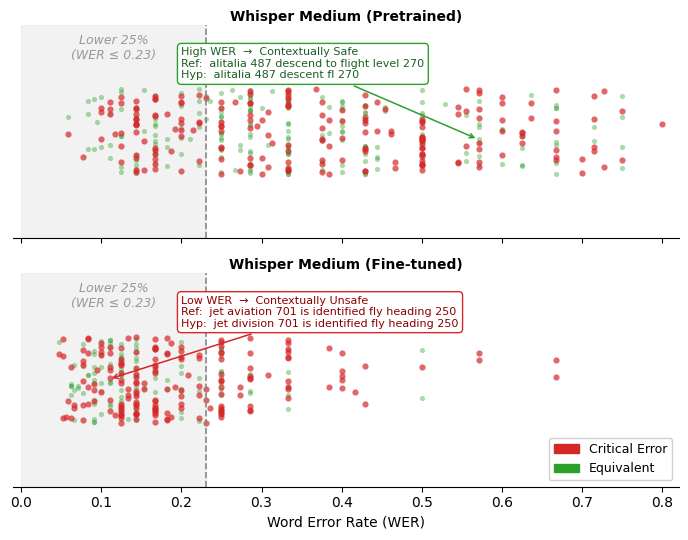

In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/llama_70b_annotation"
DATASET  = "atcosim_test"

FILES = {
    "Whisper Medium (Pretrained)":
        "whisper-medium_pretrained_" + DATASET + "_predictions.json",
    "Whisper Medium (Fine-tuned)":
        "whisper-medium-combined_" + DATASET + "_predictions.json",
}

COLOR = {"Critical_Errors": "#d62728", "Equivalent": "#2ca02c"}
rng   = np.random.default_rng(42)
N_EACH = 200

# ============================================================
# LOAD
# ============================================================

def load_records(filename):
    with open(os.path.join(BASE_DIR, filename)) as f:
        return json.load(f)["records"]

def get_valid(records):
    return [
        r for r in records
        if r["contextual_status"] in ("Critical_Errors", "Equivalent")
        and r["WER"] <= 0.8
        and r["WER"] > 1e-8
    ]

# ============================================================
# THRESHOLD
# ============================================================

baseline_file    = list(FILES.values())[0]
baseline_records = get_valid(load_records(baseline_file))
baseline_wers    = np.array([r["WER"] for r in baseline_records])
THRESHOLD        = np.percentile(baseline_wers, 25)
print(f"Fixed threshold (25th pct): {THRESHOLD:.3f}")

# ============================================================
# MANUAL ANNOTATION TEXT
# ============================================================

ANNOTATION_GREEN = {
    "title":  "High WER  →  Contextually Safe",
    "ref":    "alitalia 487 descend to flight level 270",
    "hyp":    "alitalia 487 descent fl 270",
    "xy":     (0.57, -0.07),
    "xytext": (0.20, 0.50),
}

ANNOTATION_RED = {
    "title":  "Low WER  →  Contextually Unsafe",
    "ref":    "jet aviation 701 is identified fly heading 250",
    "hyp":    "jet division 701 is identified fly heading 250",
    "xy":     (0.11, 0.01),
    "xytext": (0.20, 0.50),
}

# ============================================================
# PLOT — vertical stack, half-page column width
# ============================================================

# Width ~3.3" (single ACL/EMNLP column) or ~7" (full page); height proportional
fig, axes = plt.subplots(2, 1, figsize=(7, 5.5), sharex=True)

for ax_idx, (ax, (title, filename)) in enumerate(zip(axes, FILES.items())):

    records    = get_valid(load_records(filename))
    critical   = [r for r in records if r["contextual_status"] == "Critical_Errors"]
    equivalent = [r for r in records if r["contextual_status"] == "Equivalent"]

    # stats on full data
    crit_wers = np.array([r["WER"] for r in critical])
    pct_crit_in_threshold = (
        100 * np.sum(crit_wers < THRESHOLD) / len(crit_wers)
        if len(crit_wers) else 0
    )

    # balanced downsample for display
    n_crit = min(N_EACH, len(critical))
    n_eq   = min(N_EACH, len(equivalent))
    critical_plot   = list(rng.choice(critical,   size=n_crit, replace=False))
    equivalent_plot = list(rng.choice(equivalent, size=n_eq,   replace=False))

    plot_records = critical_plot + equivalent_plot
    wers         = np.array([r["WER"] for r in plot_records])
    statuses     = [r["contextual_status"] for r in plot_records]
    jitter       = rng.uniform(-0.4, 0.4, size=len(wers))

    # ── background shading ──────────────────────────────────────────────
    ax.axvspan(0, THRESHOLD, color="#efefef", alpha=0.8, zorder=0)
    ax.axvline(THRESHOLD, color="#888888", linewidth=1.2, linestyle="--", zorder=2)
    ax.text(
        THRESHOLD / 2, 0.96,
        f"Lower 25%\n(WER ≤ {THRESHOLD:.2f})",
        transform=ax.get_xaxis_transform(),
        fontsize=9, color="#999999", va="top", ha="center", style="italic"
    )
    # ax.grid(False)

    # ── scatter ─────────────────────────────────────────────────────────
    for status in ["Equivalent", "Critical_Errors"]:
        mask = np.array([s == status for s in statuses])
        ax.scatter(
            wers[mask], jitter[mask],
            c=COLOR[status], marker="o",
            alpha=0.4 if status == "Equivalent" else 0.7,
            s=14  if status == "Equivalent" else 20,
            linewidths=0
        )

    # ── MANUAL ANNOTATIONS ───────────────────────────────────────────────

    # Green box on TOP subplot (baseline)
    if ax_idx == 0:
        ann = ANNOTATION_GREEN
        label = f"{ann['title']}\nRef:  {ann['ref']}\nHyp:  {ann['hyp']}"
        ax.annotate(
            label,
            xy=ann["xy"],
            xytext=ann["xytext"],
            fontsize=8,
            color="#1b5e20",
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#2ca02c", lw=1.0),
            arrowprops=dict(arrowstyle="->", color="#2ca02c", lw=1.1),
        )

    # Red box on BOTTOM subplot (finetuned)
    if ax_idx == 1:
        ann = ANNOTATION_RED
        label = f"{ann['title']}\nRef:  {ann['ref']}\nHyp:  {ann['hyp']}"
        ax.annotate(
            label,
            xy=ann["xy"],
            xytext=ann["xytext"],
            fontsize=8,
            color="#8b0000",
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#d62728", lw=1.0),
            arrowprops=dict(arrowstyle="->", color="#d62728", lw=1.1),
        )

    # # ── subplot label (a) / (b) ──────────────────────────────────────────
    # # label_char = "(a)" if ax_idx == 0 else "(b)"
    # ax.text(
    #     -0.01, 1.02, 
    #     label_char,
    #     transform=ax.transAxes,
    #     fontsize=9, fontweight="bold", va="bottom", ha="left"
    # )

    # ── axis formatting ──────────────────────────────────────────────────
    ax.set_title(title, fontsize=10, fontweight="bold", pad=3)
    ax.set_xlim(-0.01, 0.82)
    ax.set_ylim(-1, 1)
    ax.set_yticks([])
    ax.grid(False)
    ax.spines[["top", "right", "left"]].set_visible(False)

# Only bottom plot gets x-label (sharex=True shares the axis)
axes[1].set_xlabel("Word Error Rate (WER)", fontsize=10)
axes[1].legend(
    handles=[
        mpatches.Patch(color=COLOR["Critical_Errors"], label="Contextual Error"),
        mpatches.Patch(color=COLOR["Equivalent"],      label="Equivalent"),
    ],
    loc="lower right",
    frameon=True,
    framealpha=0.9,
    edgecolor="#cccccc",
    fontsize=9,
)

# ============================================================
# LEGEND
# ============================================================

# fig.legend(
#     handles=[
#         mpatches.Patch(color=COLOR["Critical_Errors"], label="Critical Error"),
#         mpatches.Patch(color=COLOR["Equivalent"],      label="Equivalent"),
#     ],
#     loc="upper center", ncol=2, frameon=False,
#     bbox_to_anchor=(0.5, 1.02),
#     fontsize=9,
# )

plt.tight_layout()
out_path = f"wer_whisper_only_{DATASET}_vertical.png"
plt.savefig(out_path, dpi=600, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

In [15]:
import pandas as pd
import numpy as np
import json
import os

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/llama_70b_annotation"

DATASETS = ["atco2_ood", "uwb_atcc_test", "atcosim_test"]

MODELS = ["whisper-medium", "parakeet-tdt-0.6b-v3"]
VARIANTS = ["pretrained", "combined"]

MODEL_LABEL = {
    "whisper-medium": "Whisper",
    "parakeet-tdt-0.6b-v3": "Parakeet"
}

DATASET_LABEL = {
    "atco2_ood": "ATCO2 (OOD)",
    "uwb_atcc_test": "UWB-ATCC (ID)",
    "atcosim_test": "ATCOSim (ID)"
}

# ============================================================
# LOAD
# ============================================================

def load(file):
    path = os.path.join(BASE_DIR, file)
    with open(path) as f:
        return json.load(f)["records"]

def get_valid(records):
    return [
        r for r in records
        if r["contextual_status"] in ("Critical_Errors", "Equivalent")
        and r.get("WER", None) is not None
    ]

# ============================================================
# FIRST: compute global threshold (25th percentile baseline)
# using ALL pretrained models (more stable)
# ============================================================

all_wers = []

for ds in DATASETS:
    for model in MODELS:
        file = f"{model}_pretrained_{ds}_predictions.json"
        path = os.path.join(BASE_DIR, file)
        if not os.path.exists(path):
            continue

        recs = get_valid(load(file))
        all_wers.extend([r["WER"] for r in recs])

THRESHOLD = np.percentile(all_wers, 25)
print(f"Global WER threshold (25th percentile): {THRESHOLD:.4f}")

# ============================================================
# COMPUTE TABLE
# ============================================================

rows = []

for ds in DATASETS:
    for model in MODELS:
        for var in VARIANTS:

            file = f"{model}_{var}_{ds}_predictions.json"
            path = os.path.join(BASE_DIR, file)

            if not os.path.exists(path):
                continue

            records = get_valid(load(file))

            critical = [r for r in records if r["contextual_status"] == "Critical_Errors"]

            if len(critical) == 0:
                pct_low = np.nan
            else:
                low = [r for r in critical if r["WER"] < THRESHOLD]
                pct_low = 100 * len(low) / len(critical)

            rows.append({
                "Dataset": DATASET_LABEL[ds],
                "Model": MODEL_LABEL[model],
                "Variant": var,
                "Critical Samples": len(critical),
                "% Critical in Low-WER Region": round(pct_low, 2)
            })

df = pd.DataFrame(rows)

# ============================================================
# DISPLAY (paper-ready)
# ============================================================

print("\n")
print(df.to_string(index=False))

Global WER threshold (25th percentile): 0.2727


      Dataset    Model    Variant  Critical Samples  % Critical in Low-WER Region
  ATCO2 (OOD)  Whisper pretrained               654                         14.07
  ATCO2 (OOD) Parakeet pretrained               715                         11.19
UWB-ATCC (ID)  Whisper pretrained              2061                          6.55
UWB-ATCC (ID) Parakeet pretrained              2294                          3.05
 ATCOSim (ID)  Whisper pretrained              1090                         28.53
 ATCOSim (ID) Parakeet pretrained              1293                         47.25


In [85]:
import os
import json
import numpy as np
import pandas as pd
import torch

from bert_score import score as bert_score_fn
from transformers import RobertaTokenizer, RobertaModel

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/llama_70b_annotation"

DATASETS = ["atco2_ood", "uwb_atcc_test", "atcosim_test"]
MODELS   = ["whisper-medium", "parakeet-tdt-0.6b-v3"]
VARIANTS = ["pretrained", "combined"]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# LOAD
# ============================================================

def load(file):
    with open(os.path.join(BASE_DIR, file)) as f:
        return json.load(f)["records"]

def valid(records):
    return [
        r for r in records
        if r["contextual_status"] in ("Critical_Errors", "Equivalent")
        and r["reference"].strip()
        and r["hypothesis"].strip()
    ]

def get_file(model, variant, ds):
    if variant == "combined":
        return f"{model}-combined_{ds}_predictions.json"
    return f"{model}_{variant}_{ds}_predictions.json"

# ============================================================
# SEMDIST MODEL
# ============================================================

class SemDist:
    _instance = None

    @classmethod
    def get(cls):
        if cls._instance is None:
            cls._instance = cls()
        return cls._instance

    def __init__(self):
        print(f"[SemDist] Loading roberta-large on {DEVICE}...")
        self.tokenizer = RobertaTokenizer.from_pretrained("roberta-large")
        self.model = RobertaModel.from_pretrained("roberta-large").to(DEVICE)
        self.model.eval()

    @torch.no_grad()
    def embed(self, texts, batch_size=32):
        outs = []
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            enc = self.tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=128,
                return_tensors="pt"
            ).to(DEVICE)

            out = self.model(**enc)
            mask = enc["attention_mask"].unsqueeze(-1).float()
            emb = (out.last_hidden_state * mask).sum(1) / mask.sum(1)
            outs.append(emb.cpu())

        return torch.cat(outs, 0)

    def compute_per_sample(self, refs, hyps):
        r = self.embed(refs)
        h = self.embed(hyps)
        dist = 1.0 - torch.nn.functional.cosine_similarity(r, h, dim=1)
        return dist.numpy()

semdist_model = SemDist.get()

# ============================================================
# STEP 1: BUILD THRESHOLDS (PRETRAINED ONLY)
# ============================================================

all_bd = []
all_sd = []

print("\nComputing thresholds from pretrained distributions...\n")

for model in MODELS:
    for ds in DATASETS:

        file = get_file(model, "pretrained", ds)
        path = os.path.join(BASE_DIR, file)

        if not os.path.exists(path):
            continue

        recs = valid(load(file))
        refs = [r["reference"] for r in recs]
        hyps = [r["hypothesis"] for r in recs]

        # ---------------- WER ----------------
        wers = np.array([r["WER"] for r in recs])
        all_bd.extend(wers)   # reuse same container style (WER threshold separately below)

        # ---------------- BERT ----------------
        _, _, F1 = bert_score_fn(
            hyps, refs,
            model_type="roberta-large",
            lang="en",
            device=DEVICE
        )
        bd = (1 - F1).cpu().numpy()
        all_bd.extend(bd)

        # ---------------- SEMDIST ----------------
        sd = semdist_model.compute_per_sample(refs, hyps)
        all_sd.extend(sd)

# split thresholds cleanly (IMPORTANT FIX)
# NOTE: we recompute properly per metric below

WER_all = []
BD_all  = []
SD_all  = []

for model in MODELS:
    for ds in DATASETS:
        file = get_file(model, "pretrained", ds)
        path = os.path.join(BASE_DIR, file)

        if not os.path.exists(path):
            continue

        recs = valid(load(file))
        refs = [r["reference"] for r in recs]
        hyps = [r["hypothesis"] for r in recs]

        WER_all.extend([r["WER"] for r in recs])

        _, _, F1 = bert_score_fn(hyps, refs,
                                 model_type="roberta-large",
                                 lang="en",
                                 device=DEVICE)
        BD_all.extend((1 - F1).cpu().numpy())

        SD_all.extend(semdist_model.compute_per_sample(refs, hyps))

WER_THR = np.percentile(WER_all, 25)
BD_THR  = np.percentile(BD_all, 25)
SD_THR  = np.percentile(SD_all, 25)

print("\n=== THRESHOLDS (25th percentile pretrained) ===")
print("WER       :", WER_THR)
print("BERTDist  :", BD_THR)
print("SemDist   :", SD_THR)

# ============================================================
# STEP 2: PARADOX TABLE
# ============================================================

rows = []

for ds in DATASETS:
    for model in MODELS:
        for var in VARIANTS:

            file = get_file(model, var, ds)
            path = os.path.join(BASE_DIR, file)

            if not os.path.exists(path):
                continue

            recs = valid(load(file))

            refs = [r["reference"] for r in recs]
            hyps = [r["hypothesis"] for r in recs]

            idx_crit = [i for i, r in enumerate(recs)
                        if r["contextual_status"] == "Critical_Errors"]

            if len(idx_crit) == 0:
                continue

            # ---------------- WER ----------------
            wers = np.array([r["WER"] for r in recs])
            pct_wer = 100 * np.mean(wers[idx_crit] < WER_THR)

            # ---------------- BERT ----------------
            _, _, F1 = bert_score_fn(
                hyps, refs,
                model_type="roberta-large",
                lang="en",
                device=DEVICE
            )
            bd = (1 - F1).cpu().numpy()
            pct_bd = 100 * np.mean(bd[idx_crit] < BD_THR)

            # ---------------- SEMDIST ----------------
            sd = semdist_model.compute_per_sample(refs, hyps)
            pct_sd = 100 * np.mean(sd[idx_crit] < SD_THR)

            rows.append({
                "Dataset": ds,
                "Model": model,
                "Variant": var,
                "Critical N": len(idx_crit),
                "% WER low": round(pct_wer, 2),
                "% BERTDist low": round(pct_bd, 2),
                "% SemDist low": round(pct_sd, 2),
            })

df = pd.DataFrame(rows)

# ============================================================
# OUTPUT
# ============================================================

print("\n" + "="*90)
print("PARADOX TABLE: Critical Errors in Low-Metric Region")
print("="*90)

print(df.to_string(index=False))

# ============================================================
# DELTA VIEW (FINETUNED - PRETRAINED)
# ============================================================

print("\n" + "="*90)
print("DELTA (Finetuned - Pretrained)")
print("="*90)

for ds in DATASETS:
    for model in MODELS:

        pre = df[(df.Dataset == ds) & (df.Model == model) & (df.Variant == "pretrained")]
        ft  = df[(df.Dataset == ds) & (df.Model == model) & (df.Variant == "combined")]

        if len(pre) == 0 or len(ft) == 0:
            continue

        for metric in ["% WER low", "% BERTDist low", "% SemDist low"]:

            p = pre[metric].values[0]
            f = ft[metric].values[0]
            d = f - p

            flag = "⚠ PARADOX" if d > 5 else ("▲" if d > 0 else "▼")

            print(f"{ds:15s} | {model:22s} | {metric:15s} | "
                  f"Pre {p:5.1f}%  FT {f:5.1f}%  Δ {d:+5.1f} {flag}")

[SemDist] Loading roberta-large on cuda...

Computing thresholds from pretrained distributions...


=== THRESHOLDS (25th percentile pretrained) ===
WER       : 0.2727
BERTDist  : 0.060163125
SemDist   : 0.0015883595

PARADOX TABLE: Critical Errors in Low-Metric Region
      Dataset                Model    Variant  Critical N  % WER low  % BERTDist low  % SemDist low
    atco2_ood       whisper-medium pretrained         654      14.07           13.91          17.28
    atco2_ood       whisper-medium   combined         561      38.15           33.69          36.54
    atco2_ood parakeet-tdt-0.6b-v3 pretrained         715      11.19           10.49          12.03
    atco2_ood parakeet-tdt-0.6b-v3   combined         761      25.36           18.53          25.36
uwb_atcc_test       whisper-medium pretrained        2061       6.55            8.30           8.64
uwb_atcc_test       whisper-medium   combined        1193      41.41           48.78          47.11
uwb_atcc_test parakeet-tdt-0.6b

In [16]:
# import os
# import json
# import numpy as np
# import pandas as pd
# import torch
# from bert_score import score as bert_score_fn
# from transformers import RobertaTokenizer, RobertaModel

# # ============================================================
# # CONFIG
# # ============================================================

# BASE_DIR = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/llama_70b_annotation"

# DATASETS = ["atco2_ood", "uwb_atcc_test", "atcosim_test"]
# MODELS   = ["whisper-medium", "parakeet-tdt-0.6b-v3"]
# VARIANTS = ["pretrained", "combined"]

# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# # ============================================================
# # LOAD HELPERS
# # ============================================================

# def load(file):
#     path = os.path.join(BASE_DIR, file)
#     with open(path) as f:
#         return json.load(f)["records"]

# def valid(records):
#     return [
#         r for r in records
#         if r["contextual_status"] in ("Critical_Errors", "Equivalent")
#         and r["reference"].strip()
#         and r["hypothesis"].strip()
#     ]

# def fname(model, var, ds):
#     if var == "combined":
#         return f"{model}-combined_{ds}_predictions.json"
#     return f"{model}_{var}_{ds}_predictions.json"

# # ============================================================
# # SEMDIST
# # ============================================================

# class SemDist:
#     _instance = None

#     @classmethod
#     def get(cls):
#         if cls._instance is None:
#             cls._instance = cls()
#         return cls._instance

#     def __init__(self):
#         print(f"[SemDist] loading roberta-large on {DEVICE}")
#         self.tokenizer = RobertaTokenizer.from_pretrained("roberta-large")
#         self.model = RobertaModel.from_pretrained("roberta-large").to(DEVICE)
#         self.model.eval()

#     @torch.no_grad()
#     def embed(self, texts, batch_size=32):
#         outs = []
#         for i in range(0, len(texts), batch_size):
#             batch = texts[i:i+batch_size]
#             enc = self.tokenizer(batch, padding=True, truncation=True,
#                                  max_length=128, return_tensors="pt").to(DEVICE)
#             out = self.model(**enc)
#             mask = enc["attention_mask"].unsqueeze(-1).float()
#             emb = (out.last_hidden_state * mask).sum(1) / mask.sum(1)
#             outs.append(emb.cpu())
#         return torch.cat(outs, 0)

#     def compute(self, refs, hyps):
#         r = self.embed(refs)
#         h = self.embed(hyps)
#         return 1 - torch.nn.functional.cosine_similarity(r, h, dim=1)

# semdist = SemDist.get()

# def semdist_per_sample(refs, hyps):
#     r = semdist.embed(refs)
#     h = semdist.embed(hyps)
#     return (1 - torch.nn.functional.cosine_similarity(r, h, dim=1)).cpu().numpy()

# # ============================================================
# # STEP 1: GLOBAL THRESHOLDS (FIXED FROM PRETRAINED ONLY)
# # ============================================================

# all_bd, all_sd = [], []

# for m in MODELS:
#     for ds in DATASETS:
#         f = fname(m, "pretrained", ds)
#         path = os.path.join(BASE_DIR, f)
#         if not os.path.exists(path):
#             continue

#         recs = valid(load(f))
#         refs = [r["reference"] for r in recs]
#         hyps = [r["hypothesis"] for r in recs]

#         # BERTDist
#         _, _, F1 = bert_score_fn(
#             hyps, refs,
#             model_type="roberta-large",
#             lang="en",
#             device=DEVICE
#         )
#         bd = (1 - F1).cpu().numpy()
#         all_bd.extend(bd)

#         # SemDist
#         all_sd.extend(semdist_per_sample(refs, hyps))

# BD_THR = np.percentile(all_bd, 25)
# SD_THR = np.percentile(all_sd, 25)

# print(f"BERTDist threshold: {BD_THR:.4f}")
# print(f"SemDist threshold:  {SD_THR:.4f}")

# # ============================================================
# # STEP 2: TABLE (PARADOX METRIC)
# # ============================================================

# rows = []

# for ds in DATASETS:
#     for m in MODELS:
#         for v in VARIANTS:

#             f = fname(m, v, ds)
#             path = os.path.join(BASE_DIR, f)
#             if not os.path.exists(path):
#                 continue

#             recs = valid(load(f))

#             refs = [r["reference"] for r in recs]
#             hyps = [r["hypothesis"] for r in recs]

#             crit_idx = np.array([
#                 i for i, r in enumerate(recs)
#                 if r["contextual_status"] == "Critical_Errors"
#             ])

#             if len(crit_idx) == 0:
#                 continue

#             # WER (assumed already in JSON)
#             wers = np.array([r["WER"] for r in recs])

#             # BERTDist
#             _, _, F1 = bert_score_fn(
#                 hyps, refs,
#                 model_type="roberta-large",
#                 lang="en",
#                 device=DEVICE
#             )
#             bd = (1 - F1).cpu().numpy()

#             # SemDist
#             sd = semdist_per_sample(refs, hyps)

#             # critical subsets
#             bd_crit = bd[crit_idx]
#             sd_crit = sd[crit_idx]
#             wer_crit = wers[crit_idx]

#             rows.append({
#                 "Dataset": ds,
#                 "Model": m,
#                 "Variant": v,
#                 "Critical N": len(crit_idx),

#                 "% WER low": round(100 * np.mean(wer_crit <= np.percentile(wers, 25)), 2),
#                 "% BERTDist low": round(100 * np.mean(bd_crit <= BD_THR), 2),
#                 "% SemDist low": round(100 * np.mean(sd_crit <= SD_THR), 2),
#             })

# df = pd.DataFrame(rows)

# # ============================================================
# # OUTPUT
# # ============================================================

# print("\n" + "="*100)
# print("PARADOX TABLE: concentration of critical errors in 'low-distance' region")
# print("="*100)
# print(df.to_string(index=False))


Computing BERTScore for 1888 records...
Fixed threshold (25th pct of baseline BERTDist): 0.0241
Computing BERTScore for 1901 records...
Saved: bertdist_whisper_only_atcosim_test.png


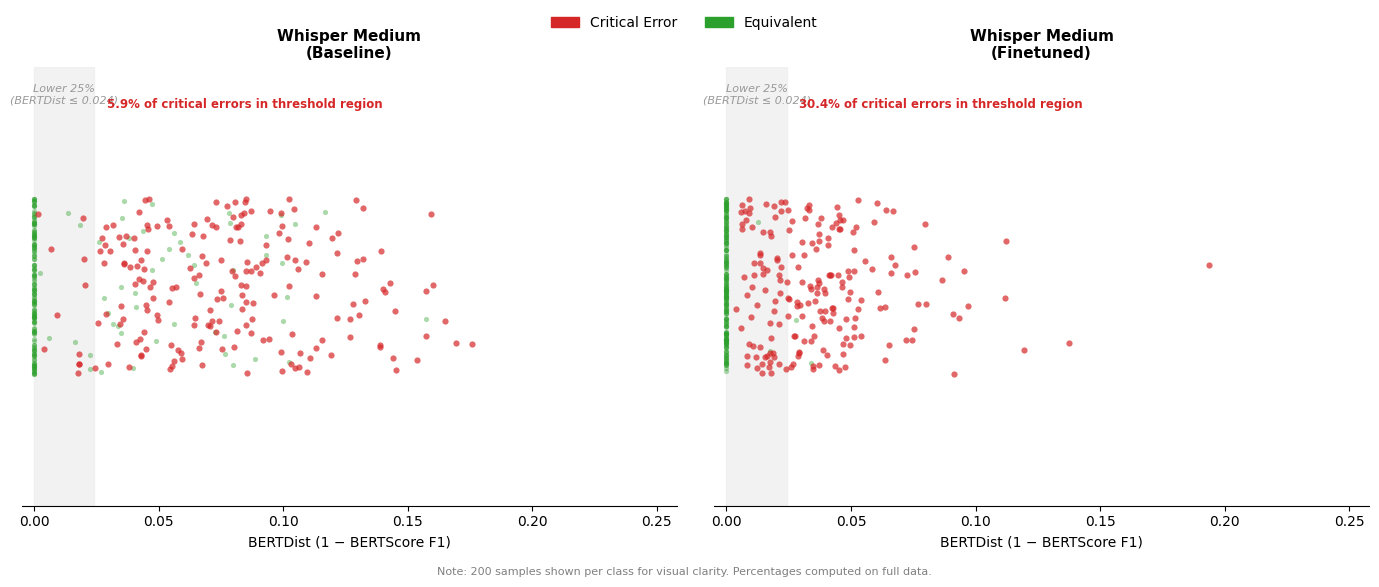

In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
from bert_score import score as bert_score_fn
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/llama_70b_annotation"
DATASET  = "atcosim_test"

FILES = {
    "Whisper Medium\n(Baseline)":
        "whisper-medium_pretrained_" + DATASET + "_predictions.json",
    "Whisper Medium\n(Finetuned)":
        "whisper-medium-combined_" + DATASET + "_predictions.json",
}

COLOR  = {"Critical_Errors": "#d62728", "Equivalent": "#2ca02c"}
rng    = np.random.default_rng(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_EACH = 200

# ============================================================
# LOAD + COMPUTE PER-SAMPLE BERTDist
# ============================================================

def load_with_bertdist(filename):
    with open(os.path.join(BASE_DIR, filename)) as f:
        records = json.load(f)["records"]

    valid = [r for r in records
             if r["contextual_status"] in ("Critical_Errors", "Equivalent")
             and r["reference"].strip() and r["hypothesis"].strip()]

    refs = [r["reference"]  for r in valid]
    hyps = [r["hypothesis"] for r in valid]

    print(f"Computing BERTScore for {len(valid)} records...")
    _, _, F1 = bert_score_fn(
        hyps, refs,
        lang="en",
        rescale_with_baseline=False,
        model_type="roberta-large",
        batch_size=64,
        device=DEVICE,
        verbose=False,
    )
    bertdist = (1.0 - F1).numpy()

    for r, bd in zip(valid, bertdist):
        r["BERTDist"] = float(bd)

    return valid

# ============================================================
# FIXED THRESHOLD FROM BASELINE
# ============================================================

baseline_records = load_with_bertdist(list(FILES.values())[0])
baseline_bd      = np.array([r["BERTDist"] for r in baseline_records])
THRESHOLD        = np.percentile(baseline_bd, 25)
print(f"Fixed threshold (25th pct of baseline BERTDist): {THRESHOLD:.4f}")

# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

all_records = [baseline_records, load_with_bertdist(list(FILES.values())[1])]

for ax, (title, _), records in zip(axes, FILES.items(), all_records):

    critical   = [r for r in records if r["contextual_status"] == "Critical_Errors"]
    equivalent = [r for r in records if r["contextual_status"] == "Equivalent"]

    # honest stats on full data
    crit_bd_full = np.array([r["BERTDist"] for r in critical])
    total        = len(critical) + len(equivalent)
    pct_crit_in_threshold  = 100 * np.sum(crit_bd_full < THRESHOLD) / len(crit_bd_full) if len(crit_bd_full) else 0
    pct_critical_overall   = 100 * len(critical) / total if total else 0

    # balanced downsample
    n_crit = min(N_EACH, len(critical))
    n_eq   = min(N_EACH, len(equivalent))
    plot_records = (list(rng.choice(critical,   size=n_crit, replace=False)) +
                    list(rng.choice(equivalent, size=n_eq,   replace=False)))

    bd       = np.array([r["BERTDist"] for r in plot_records])
    statuses = [r["contextual_status"] for r in plot_records]
    jitter   = rng.uniform(-0.4, 0.4, size=len(bd))

    # background
    ax.axvspan(0, THRESHOLD, color="#efefef", alpha=0.8, zorder=0)
    ax.text(
        THRESHOLD / 2, 0.96, f"Lower 25%\n(BERTDist ≤ {THRESHOLD:.3f})",
        transform=ax.get_xaxis_transform(),
        fontsize=8, color="#999999", va="top", ha="center", style="italic"
    )

    # scatter
    for status in ["Equivalent", "Critical_Errors"]:
        mask = np.array([s == status for s in statuses])
        ax.scatter(
            bd[mask], jitter[mask],
            c=COLOR[status], marker="o",
            alpha=0.4 if status == "Equivalent" else 0.7,
            s=14  if status == "Equivalent" else 20,
            linewidths=0
        )

    ax.text(
        THRESHOLD + 0.005, 0.93,
        f"{pct_crit_in_threshold:.1f}% of critical errors in threshold region",
        transform=ax.get_xaxis_transform(),
        fontsize=8.5, color="#d62728", fontweight="bold", va="top"
    )
    # ax.text(
    #     THRESHOLD + 0.005, 0.75,
    #     f"Overall CCER: {pct_critical_overall:.1f}%\n(n={len(critical)} critical / {total} total)",
    #     transform=ax.get_xaxis_transform(),
    #     fontsize=8, color="#555555", va="top"
    # )

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("BERTDist (1 − BERTScore F1)", fontsize=10)
    ax.set_xlim(-0.005, min(baseline_bd.max() + 0.02, 1.0))
    ax.set_ylim(-1, 1)
    ax.set_yticks([])
    ax.spines[["top", "right", "left"]].set_visible(False)

fig.legend(
    handles=[
        mpatches.Patch(color=COLOR["Critical_Errors"], label="Critical Error"),
        mpatches.Patch(color=COLOR["Equivalent"],      label="Equivalent"),
    ],
    loc="upper center", ncol=2, frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

fig.text(0.5, -0.02,
         f"Note: {N_EACH} samples shown per class for visual clarity. "
         f"Percentages computed on full data.",
         ha="center", fontsize=8, color="gray")

plt.tight_layout()
out_path = f"bertdist_whisper_only_{DATASET}.png"
plt.savefig(out_path, dpi=600, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

Loading roberta-large on cuda...
Computing SemDist for 1888 records...
Fixed threshold (25th pct of baseline SemDist): 0.0006
Computing SemDist for 1901 records...
Saved: semdist_whisper_only_atcosim_test.png


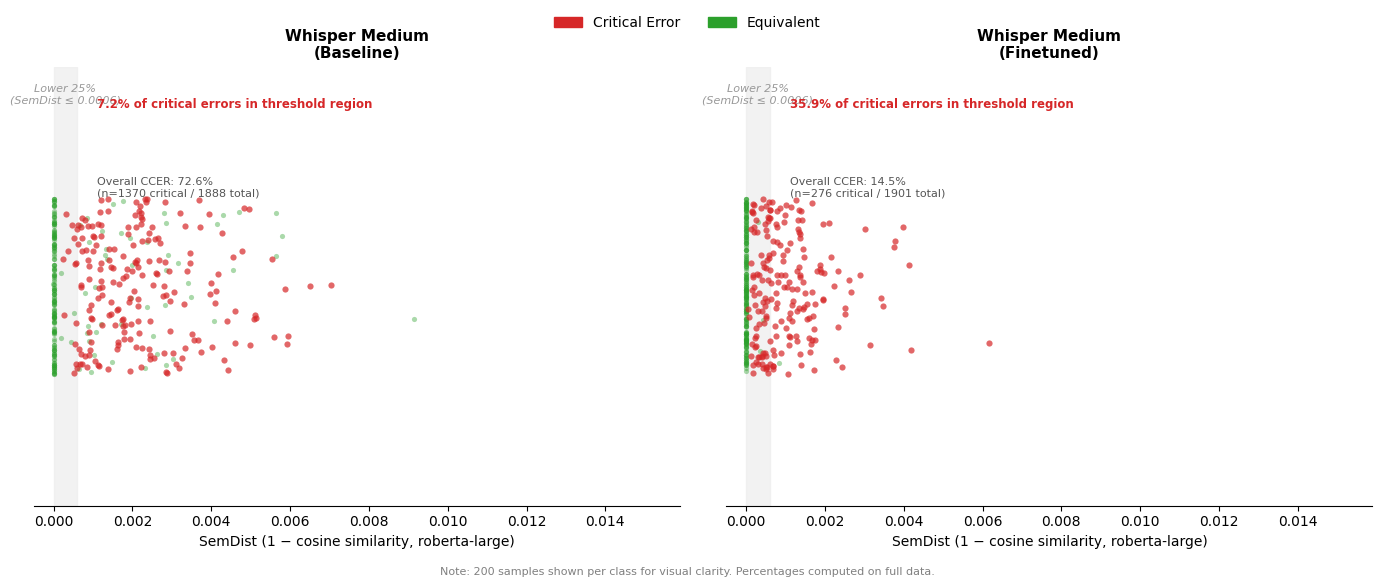

In [63]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
from transformers import RobertaTokenizer, RobertaModel, logging as hf_logging
hf_logging.set_verbosity_error()

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/llama_70b_annotations"
DATASET  = "atcosim_test"

FILES = {
    "Whisper Medium\n(Baseline)":
        "whisper-medium_pretrained_" + DATASET + "_predictions.json",
    "Whisper Medium\n(Finetuned)":
        "whisper-medium-combined_" + DATASET + "_predictions.json",
}

COLOR  = {"Critical_Errors": "#d62728", "Equivalent": "#2ca02c"}
rng    = np.random.default_rng(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_EACH = 200

# ============================================================
# SEMDIST MODEL (load once)
# ============================================================

print(f"Loading roberta-large on {DEVICE}...")
tok = RobertaTokenizer.from_pretrained("roberta-large")
mdl = RobertaModel.from_pretrained("roberta-large").to(DEVICE)
mdl.eval()

@torch.no_grad()
def embed(texts, batch_size=64):
    all_emb = []
    for i in range(0, len(texts), batch_size):
        enc = tok(texts[i:i+batch_size], padding=True, truncation=True,
                  max_length=128, return_tensors="pt").to(DEVICE)
        h    = mdl(**enc).last_hidden_state
        mask = enc["attention_mask"].unsqueeze(-1).float()
        all_emb.append(((h * mask).sum(1) / mask.sum(1)).cpu())
    return torch.cat(all_emb, 0)

def compute_semdist(refs, hyps):
    r = embed(refs)
    h = embed(hyps)
    return (1 - torch.nn.functional.cosine_similarity(r, h, dim=1)).numpy()

# ============================================================
# LOAD + COMPUTE PER-SAMPLE SemDist
# ============================================================

def load_with_semdist(filename):
    with open(os.path.join(BASE_DIR, filename)) as f:
        records = json.load(f)["records"]

    valid = [r for r in records
             if r["contextual_status"] in ("Critical_Errors", "Equivalent")
             and r["reference"].strip() and r["hypothesis"].strip()]

    refs = [r["reference"]  for r in valid]
    hyps = [r["hypothesis"] for r in valid]

    print(f"Computing SemDist for {len(valid)} records...")
    dists = compute_semdist(refs, hyps)
    for r, d in zip(valid, dists):
        r["SemDist"] = float(d)

    return valid

# ============================================================
# FIXED THRESHOLD FROM BASELINE
# ============================================================

baseline_records = load_with_semdist(list(FILES.values())[0])
baseline_sd      = np.array([r["SemDist"] for r in baseline_records])
THRESHOLD        = np.percentile(baseline_sd, 25)
print(f"Fixed threshold (25th pct of baseline SemDist): {THRESHOLD:.4f}")

# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

all_records = [baseline_records, load_with_semdist(list(FILES.values())[1])]

for ax, (title, _), records in zip(axes, FILES.items(), all_records):

    critical   = [r for r in records if r["contextual_status"] == "Critical_Errors"]
    equivalent = [r for r in records if r["contextual_status"] == "Equivalent"]

    crit_sd_full = np.array([r["SemDist"] for r in critical])
    total        = len(critical) + len(equivalent)
    pct_crit_in_threshold = 100 * np.sum(crit_sd_full < THRESHOLD) / len(crit_sd_full) if len(crit_sd_full) else 0
    pct_critical_overall  = 100 * len(critical) / total if total else 0

    n_crit = min(N_EACH, len(critical))
    n_eq   = min(N_EACH, len(equivalent))
    plot_records = (list(rng.choice(critical,   size=n_crit, replace=False)) +
                    list(rng.choice(equivalent, size=n_eq,   replace=False)))

    sd       = np.array([r["SemDist"] for r in plot_records])
    statuses = [r["contextual_status"] for r in plot_records]
    jitter   = rng.uniform(-0.4, 0.4, size=len(sd))

    ax.axvspan(0, THRESHOLD, color="#efefef", alpha=0.8, zorder=0)
    ax.text(
        THRESHOLD / 2, 0.96, f"Lower 25%\n(SemDist ≤ {THRESHOLD:.4f})",
        transform=ax.get_xaxis_transform(),
        fontsize=8, color="#999999", va="top", ha="center", style="italic"
    )

    for status in ["Equivalent", "Critical_Errors"]:
        mask = np.array([s == status for s in statuses])
        ax.scatter(
            sd[mask], jitter[mask],
            c=COLOR[status], marker="o",
            alpha=0.4 if status == "Equivalent" else 0.7,
            s=14  if status == "Equivalent" else 20,
            linewidths=0
        )

    ax.text(
        THRESHOLD + 0.0005, 0.93,
        f"{pct_crit_in_threshold:.1f}% of critical errors in threshold region",
        transform=ax.get_xaxis_transform(),
        fontsize=8.5, color="#d62728", fontweight="bold", va="top"
    )
    ax.text(
        THRESHOLD + 0.0005, 0.75,
        f"Overall CCER: {pct_critical_overall:.1f}%\n(n={len(critical)} critical / {total} total)",
        transform=ax.get_xaxis_transform(),
        fontsize=8, color="#555555", va="top"
    )

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("SemDist (1 − cosine similarity, roberta-large)", fontsize=10)
    ax.set_xlim(-0.0005, min(baseline_sd.max() + 0.005, 1.0))
    ax.set_ylim(-1, 1)
    ax.set_yticks([])
    ax.spines[["top", "right", "left"]].set_visible(False)

fig.legend(
    handles=[
        mpatches.Patch(color=COLOR["Critical_Errors"], label="Critical Error"),
        mpatches.Patch(color=COLOR["Equivalent"],      label="Equivalent"),
    ],
    loc="upper center", ncol=2, frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

fig.text(0.5, -0.02,
         f"Note: {N_EACH} samples shown per class for visual clarity. "
         f"Percentages computed on full data.",
         ha="center", fontsize=8, color="gray")

plt.tight_layout()
out_path = f"semdist_whisper_only_{DATASET}.png"
plt.savefig(out_path, dpi=600, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

In [17]:
# import pandas as pd
# import numpy as np
# import json
# import os

# # ============================================================
# # CONFIG
# # ============================================================

# BASE_DIR = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/llama_70b_annotation"

# DATASETS = ["atco2_ood", "uwb_atcc_test", "atcosim_test"]

# MODELS = ["whisper-medium", "parakeet-tdt-0.6b-v3"]
# VARIANTS = ["pretrained", "combined"]

# # ============================================================
# # LOAD
# # ============================================================

# def load(file):
#     with open(os.path.join(BASE_DIR, file)) as f:
#         return json.load(f)["records"]

# def valid(records):
#     return [
#         r for r in records
#         if r["contextual_status"] in ("Critical_Errors", "Equivalent")
#         and r["reference"].strip()
#         and r["hypothesis"].strip()
#     ]

# # ============================================================
# # PLACEHOLDER: plug your SemDist class here
# # ============================================================

# class SemDist:
#     _instance = None

#     @classmethod
#     def get(cls):
#         if cls._instance is None:
#             cls._instance = cls()
#         return cls._instance

#     def __init__(self):
#         print(f"[SemDist] Loading roberta-large on {DEVICE}...")
#         self.tokenizer = RobertaTokenizer.from_pretrained("roberta-large")
#         self.model = RobertaModel.from_pretrained("roberta-large").to(DEVICE)
#         self.model.eval()

#     @torch.no_grad()
#     def _embed(self, texts, batch_size=32):
#         all_emb = []
#         for i in range(0, len(texts), batch_size):
#             batch = texts[i:i+batch_size]
#             enc = self.tokenizer(batch, padding=True, truncation=True,
#                                  max_length=128, return_tensors="pt").to(DEVICE)
#             out = self.model(**enc)
#             mask = enc["attention_mask"].unsqueeze(-1).float()
#             emb  = (out.last_hidden_state * mask).sum(1) / mask.sum(1)
#             all_emb.append(emb.cpu())
#         return torch.cat(all_emb, 0)

#     def compute(self, references, hypotheses):
#         # Filter empty pairs
#         pairs = [(r, h) for r, h in zip(references, hypotheses) if r.strip() and h.strip()]
#         refs, hyps = zip(*pairs)
#         r = self._embed(list(refs))
#         h = self._embed(list(hyps))
#         dist = 1.0 - torch.nn.functional.cosine_similarity(r, h, dim=1)
#         return round(dist.mean().item(), 6)
#     def compute_per_sample_semdist(self, references, hypotheses):
#         pairs = [(r, h) for r, h in zip(references, hypotheses)
#                 if r.strip() and h.strip()]
#         refs, hyps = zip(*pairs)

#         r = self._embed(list(refs))
#         h = self._embed(list(hyps))

#         dist = 1.0 - torch.nn.functional.cosine_similarity(r, h, dim=1)
#         return dist.cpu().numpy()


# semdist_model = SemDist.get()

# def compute_semdist_per_sample(refs, hyps):
#     r = semdist_model._embed(refs)
#     h = semdist_model._embed(hyps)
#     dist = 1.0 - torch.nn.functional.cosine_similarity(r, h, dim=1)
#     return dist.cpu().numpy()

# # ============================================================
# # BUILD GLOBAL THRESHOLDS (25th percentile baseline pretrained)
# # ============================================================

# all_bd = []
# all_sd = []

# for ds in DATASETS:
#     for m in MODELS:
#         file = f"{m}_pretrained_{ds}_predictions.json"
#         path = os.path.join(BASE_DIR, file)
#         if not os.path.exists(path):
#             continue

#         recs = valid(load(file))
#         refs = [r["reference"] for r in recs]
#         hyps = [r["hypothesis"] for r in recs]

#         # BERTDist
#         _, _, F1 = bert_score_fn(hyps, refs,
#                                  model_type="roberta-large",
#                                  lang="en",
#                                  device="cuda")

#         all_bd.extend((1 - F1).cpu().numpy())

#         # SemDist
#         all_sd.extend(compute_semdist_per_sample(refs, hyps))

# BD_THR = np.percentile(all_bd, 25)
# SD_THR = np.percentile(all_sd, 25)

# print("BERTDist threshold:", BD_THR)
# print("SemDist threshold:", SD_THR)

# # ============================================================
# # TABLE
# # ============================================================

# rows = []

# for ds in DATASETS:
#     for model in MODELS:
#         for var in VARIANTS:

#             file = f"{model}_{var}_{ds}_predictions.json"
#             path = os.path.join(BASE_DIR, file)

#             if not os.path.exists(path):
#                 continue

#             recs = valid(load(file))

#             refs = [r["reference"] for r in recs]
#             hyps = [r["hypothesis"] for r in recs]

#             critical_idx = [i for i, r in enumerate(recs)
#                             if r["contextual_status"] == "Critical_Errors"]

#             if len(critical_idx) == 0:
#                 continue

#             # ---------------------------
#             # BERTDist per-sample
#             # ---------------------------
#             _, _, F1 = bert_score_fn(
#                 hyps, refs,
#                 model_type="roberta-large",
#                 lang="en",
#                 device="cuda"
#             )
#             bd = (1 - F1).cpu().numpy()

#             bd_crit = bd[critical_idx]
#             pct_bd = 100 * np.mean(bd_crit < BD_THR)

#             # ---------------------------
#             # SemDist per-sample
#             # ---------------------------
#             sd = compute_semdist_per_sample(refs, hyps)
#             sd_crit = sd[critical_idx]
#             pct_sd = 100 * np.mean(sd_crit < SD_THR)

#             rows.append({
#                 "Dataset": ds,
#                 "Model": model,
#                 "Variant": var,
#                 "Critical Samples": len(critical_idx),
#                 "% Critical (BERTDist low)": round(pct_bd, 2),
#                 "% Critical (SemDist low)": round(pct_sd, 2),
#             })

# df = pd.DataFrame(rows)

# print(df.to_string(index=False))

Saved: radar_error_distribution_atcosim_test.png


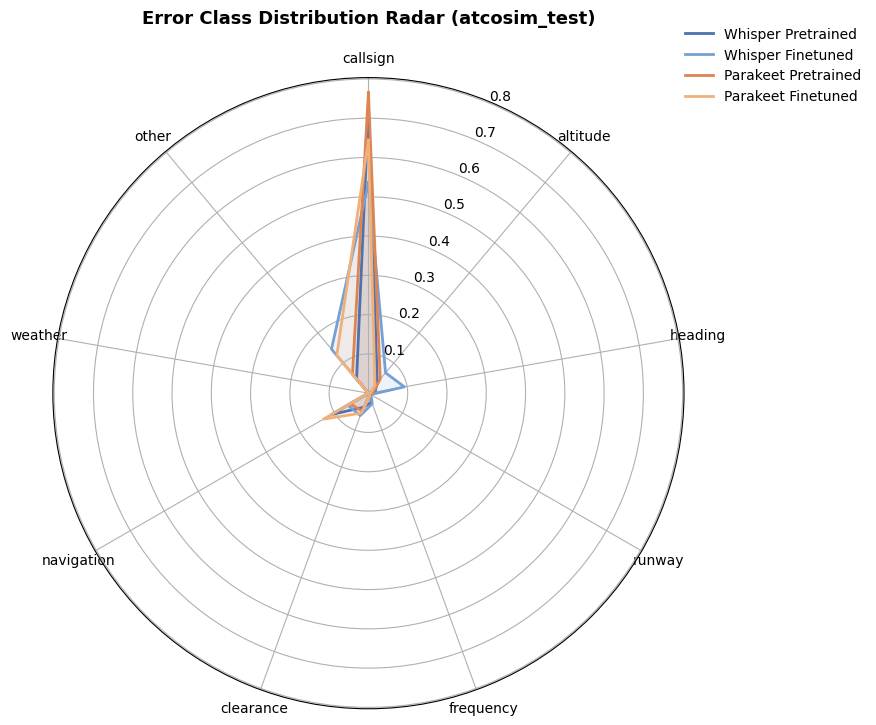

In [18]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/llama_70b_annotation"
DATASET = "atcosim_test"

CLASSES = [
    "callsign", "altitude", "heading", "runway",
    "frequency", "clearance", "navigation", "weather", "other"
]

FILES = {
    "Whisper Pretrained": "whisper-medium_pretrained_" + DATASET + "_predictions.json",
    "Whisper Finetuned": "whisper-medium-combined_" + DATASET + "_predictions.json",
    "Parakeet Pretrained": "parakeet-tdt-0.6b-v3_pretrained_" + DATASET + "_predictions.json",
    "Parakeet Finetuned": "parakeet-tdt-0.6b-v3-combined_" + DATASET + "_predictions.json",
}

COLORS = {
    "Whisper Pretrained": "#4C72B0",
    "Whisper Finetuned": "#76a0d4",
    "Parakeet Pretrained": "#DD8452",
    "Parakeet Finetuned": "#f0b07a",
}

# ============================================================
# LOAD
# ============================================================

def load_records(path):
    with open(os.path.join(BASE_DIR, path)) as f:
        return json.load(f)["records"]

# ============================================================
# STRICT ERROR COUNTING (NO INFERENCE)
# ============================================================

def compute_distribution(records):
    """
    STRICT RULE:
    - Only count explicit transcription_errors
    - Use entity_type exactly as given
    - No errors → contributes NOTHING
    """

    counts = {c: 0 for c in CLASSES}
    total_errors = 0

    for r in records:
        errs = r.get("transcription_errors", [])

        # IMPORTANT: do NOT treat no-error samples as "other"
        for e in errs:
            et = e.get("entity_type")

            if et in counts:
                counts[et] += 1
            else:
                counts["other"] += 1

            total_errors += 1

    # normalize over total ERROR INSTANCES (not samples)
    if total_errors == 0:
        return np.zeros(len(CLASSES))

    return np.array([counts[c] / total_errors for c in CLASSES])

# ============================================================
# RADAR SETUP
# ============================================================

N = len(CLASSES)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(9, 9))
ax = plt.subplot(111, polar=True)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(CLASSES, fontsize=10)

# ============================================================
# PLOT
# ============================================================

for name, file in FILES.items():

    records = load_records(file)
    dist = compute_distribution(records)

    values = dist.tolist()
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=name,
        color=COLORS[name]
    )

    ax.fill(
        angles,
        values,
        alpha=0.12,
        color=COLORS[name]
    )

# ============================================================
# FINAL STYLING
# ============================================================

ax.set_title(
    f"Error Class Distribution Radar ({DATASET})",
    fontsize=13,
    fontweight="bold",
    pad=20
)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.3, 1.1),
    frameon=False
)

plt.tight_layout()

out_path = f"radar_error_distribution_{DATASET}.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")

print(f"Saved: {out_path}")

Saved: radar_error_distribution_all_datasets.png


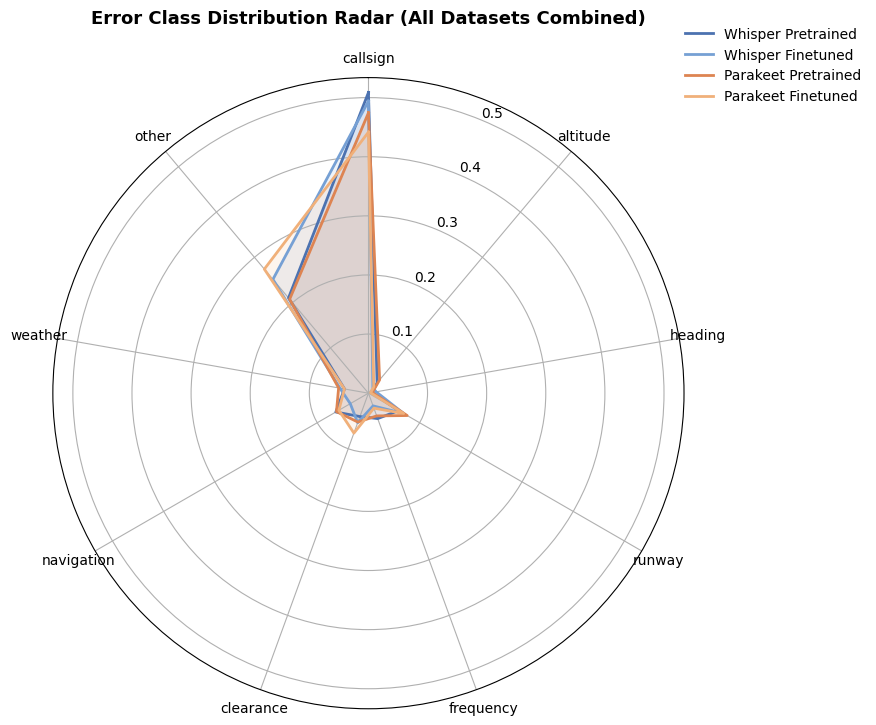

In [19]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/qwen_72b_annotation"

DATASETS = ["atcosim_test", "uwb_atcc_test", "atco2_ood"]

CLASSES = [
    "callsign", "altitude", "heading", "runway",
    "frequency", "clearance", "navigation", "weather", "other"
]

FILES = {
    "Whisper Pretrained": "whisper-medium_pretrained_{ds}_predictions.json",
    "Whisper Finetuned": "whisper-medium-combined_{ds}_predictions.json",
    "Parakeet Pretrained": "parakeet-tdt-0.6b-v3_pretrained_{ds}_predictions.json",
    "Parakeet Finetuned": "parakeet-tdt-0.6b-v3-combined_{ds}_predictions.json",
}

COLORS = {
    "Whisper Pretrained": "#4C72B0",
    "Whisper Finetuned": "#76a0d4",
    "Parakeet Pretrained": "#DD8452",
    "Parakeet Finetuned": "#f0b07a",
}

# ============================================================
# LOAD
# ============================================================

def load_records(path):
    with open(os.path.join(BASE_DIR, path)) as f:
        return json.load(f)["records"]

# ============================================================
# AGGREGATE ACROSS DATASETS
# ============================================================

def compute_distribution_across_datasets(file_template):
    counts = {c: 0 for c in CLASSES}
    total_errors = 0

    for ds in DATASETS:
        path = file_template.format(ds=ds)
        records = load_records(path)

        for r in records:
            errs = r.get("transcription_errors", [])

            for e in errs:
                et = e.get("entity_type")

                if et in counts:
                    counts[et] += 1
                else:
                    counts["other"] += 1

                total_errors += 1

    if total_errors == 0:
        return np.zeros(len(CLASSES))

    return np.array([counts[c] / total_errors for c in CLASSES])

# ============================================================
# RADAR SETUP
# ============================================================

N = len(CLASSES)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(9, 9))
ax = plt.subplot(111, polar=True)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(CLASSES, fontsize=10)

# ============================================================
# PLOT MODELS
# ============================================================

for name, template in FILES.items():

    dist = compute_distribution_across_datasets(template)

    values = dist.tolist()
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=name,
        color=COLORS[name]
    )

    ax.fill(
        angles,
        values,
        alpha=0.12,
        color=COLORS[name]
    )

# ============================================================
# FINAL STYLE
# ============================================================

ax.set_title(
    "Error Class Distribution Radar (All Datasets Combined)",
    fontsize=13,
    fontweight="bold",
    pad=20
)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.3, 1.1),
    frameon=False
)

plt.tight_layout()

out_path = "radar_error_distribution_all_datasets.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")

print(f"Saved: {out_path}")

Saved: radar_error_distribution_all_datasets.png


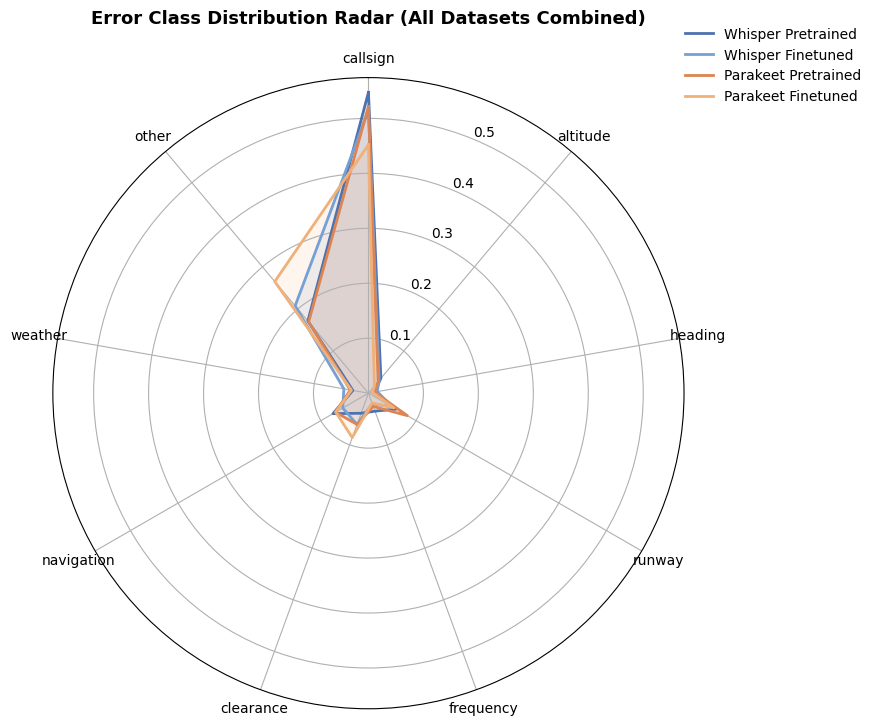

In [20]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/deepseek_llama_70b_annotation"

DATASETS = ["atcosim_test", "uwb_atcc_test", "atco2_ood"]

CLASSES = [
    "callsign", "altitude", "heading", "runway",
    "frequency", "clearance", "navigation", "weather", "other"
]

FILES = {
    "Whisper Pretrained": "whisper-medium_pretrained_{ds}_predictions.json",
    "Whisper Finetuned": "whisper-medium-combined_{ds}_predictions.json",
    "Parakeet Pretrained": "parakeet-tdt-0.6b-v3_pretrained_{ds}_predictions.json",
    "Parakeet Finetuned": "parakeet-tdt-0.6b-v3-combined_{ds}_predictions.json",
}

COLORS = {
    "Whisper Pretrained": "#4C72B0",
    "Whisper Finetuned": "#76a0d4",
    "Parakeet Pretrained": "#DD8452",
    "Parakeet Finetuned": "#f0b07a",
}

# ============================================================
# LOAD
# ============================================================

def load_records(path):
    with open(os.path.join(BASE_DIR, path)) as f:
        return json.load(f)["records"]

# ============================================================
# AGGREGATE ACROSS DATASETS
# ============================================================

def compute_distribution_across_datasets(file_template):
    counts = {c: 0 for c in CLASSES}
    total_errors = 0

    for ds in DATASETS:
        path = file_template.format(ds=ds)
        records = load_records(path)

        for r in records:
            errs = r.get("transcription_errors", [])

            for e in errs:
                et = e.get("entity_type")

                if et in counts:
                    counts[et] += 1
                else:
                    counts["other"] += 1

                total_errors += 1

    if total_errors == 0:
        return np.zeros(len(CLASSES))

    return np.array([counts[c] / total_errors for c in CLASSES])

# ============================================================
# RADAR SETUP
# ============================================================

N = len(CLASSES)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(9, 9))
ax = plt.subplot(111, polar=True)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(CLASSES, fontsize=10)

# ============================================================
# PLOT MODELS
# ============================================================

for name, template in FILES.items():

    dist = compute_distribution_across_datasets(template)

    values = dist.tolist()
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=name,
        color=COLORS[name]
    )

    ax.fill(
        angles,
        values,
        alpha=0.12,
        color=COLORS[name]
    )

# ============================================================
# FINAL STYLE
# ============================================================

ax.set_title(
    "Error Class Distribution Radar (All Datasets Combined)",
    fontsize=13,
    fontweight="bold",
    pad=20
)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.3, 1.1),
    frameon=False
)

plt.tight_layout()

out_path = "radar_error_distribution_all_datasets.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")

print(f"Saved: {out_path}")

In [49]:
import os, json, glob
from collections import Counter
import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.inter_rater import fleiss_kappa

JUDGES = {
    "llama": "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/llama_70b_annotation",
    "qwen":  "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/qwen_72b_annotation",
    "deepseek": "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/deepseek_llama_70b_annotation"
}

# ✅ FIXED: Use (reference, hypothesis) as key
def load_all(judge_dir):
    records = {}
    for fpath in sorted(glob.glob(os.path.join(judge_dir, "*.json"))):
        with open(fpath) as f:
            data = json.load(f)
        for r in data["records"]:
            # if r["WER"] <= 1e-8:
            #     continue
            key = (r["reference"].strip().lower(), r["hypothesis"].strip().lower())
            records[key] = r
    return records

llama_records = load_all(JUDGES["llama"])
qwen_records  = load_all(JUDGES["qwen"])
deepseek_records = load_all(JUDGES["deepseek"])

# class distribution per judge
for name, recs in [("llama", llama_records), ("qwen", qwen_records), ("deepseek", deepseek_records)]:
    counts = Counter(r["contextual_status"] for r in recs.values())
    print(f"\n[{name}] Total: {len(recs)}")
    for k, v in counts.items():
        print(f"  {k}: {v} ({100*v/len(recs):.1f}%)")

# agreement between judges on shared keys
shared_keys = set(llama_records) & set(qwen_records) & set(deepseek_records)
print(f"\nShared samples (by reference+hypothesis): {len(shared_keys)}")
print(f"Llama only: {len(llama_records) - len(shared_keys)}")
print(f"Qwen only:  {len(qwen_records)  - len(shared_keys)}")
print(f"Deepseek only:  {len(deepseek_records)  - len(shared_keys)}")

agree = sum(
    llama_records[k]["contextual_status"] == qwen_records[k]["contextual_status"]
    for k in shared_keys
    if llama_records[k]["contextual_status"] != "Error"
    and qwen_records[k]["contextual_status"]  != "Error"
)
valid_shared = sum(
    1 for k in shared_keys
    if llama_records[k]["contextual_status"] != "Error"
    and qwen_records[k]["contextual_status"]  != "Error"
)
print(f"\nJudge agreement on valid shared: {agree}/{valid_shared} ({100*agree/valid_shared:.1f}%)")

# disagreement breakdown
disagree_cases = Counter()
for k in shared_keys:
    l = llama_records[k]["contextual_status"]
    q = qwen_records[k]["contextual_status"]
    d = deepseek_records[k]["contextual_status"]
    if l != "Error" and q != "Error" and d != "Error" and (l != q or l != d or q != d):
        disagree_cases[(l, q, d)] += 1
print("\nDisagreement breakdown (llama_label, qwen_label, deepseek_label):")
for (l, q, d), cnt in disagree_cases.items():
    print(f"  llama={l}, qwen={q}, deepseek={d}: {cnt}")

rng = np.random.default_rng(42)

# ── categorize each shared sample ────────────────────────────────────────────
agreed_critical  = []
agreed_equivalent = []
disagreed        = []

for key in shared_keys:
    l = llama_records[key]
    q = qwen_records[key]
    d = deepseek_records[key]
    ls = l["contextual_status"]
    qs = q["contextual_status"]
    ds = d["contextual_status"]
    if ls == "Error" or qs == "Error" or ds == "Error":
        continue

    # key is now a tuple (reference, hypothesis)
    reference, hypothesis = key
    
    row = {
        "reference":         reference,
        "hypothesis":        hypothesis,
        "judge1_llama":      ls,
        "judge2_qwen":       qs,
        "judge3_deepseek":   ds,
        "judge1_llama_CCER": ls == "Critical_Errors",
        "judge2_qwen_CCER":  qs == "Critical_Errors",
        "judge3_deepseek_CCER": ds == "Critical_Errors",
        "human1_CCER":       "",
        "human2_CCER":       "",
    }

    if ls == qs == ds == "Critical_Errors":
        agreed_critical.append(row)
    elif ls == qs == ds == "Equivalent":
        agreed_equivalent.append(row)
    else:
        disagreed.append(row)

print(f"\nAgreed critical (3-way):   {len(agreed_critical)}")
print(f"Agreed equivalent (3-way): {len(agreed_equivalent)}")
print(f"Disagreed:                 {len(disagreed)}")

# ── sample ───────────────────────────────────────────────────────────────────

total = len(agreed_critical) + len(agreed_equivalent) + len(disagreed)
n_total = 500
n_crit = round(n_total * len(agreed_critical) / total)
n_eq   = round(n_total * len(agreed_equivalent) / total)
n_dis  = n_total - n_crit - n_eq

sampled_critical   = list(rng.choice(agreed_critical,   size=min(n_crit, len(agreed_critical)), replace=False))
sampled_equivalent = list(rng.choice(agreed_equivalent, size=min(n_eq,   len(agreed_equivalent)), replace=False))
sampled_disagreed  = list(rng.choice(disagreed,         size=min(n_dis,  len(disagreed)), replace=False))

for r in sampled_critical:   r["sample_type"] = "agreed_critical"
for r in sampled_equivalent: r["sample_type"] = "agreed_equivalent"
for r in sampled_disagreed:  r["sample_type"] = "disagreed"

all_samples = sampled_critical + sampled_equivalent + sampled_disagreed
rng.shuffle(all_samples)

df = pd.DataFrame(all_samples, columns=[
    "reference", "hypothesis",
    "judge1_llama", "judge2_qwen", "judge3_deepseek",
    "judge1_llama_CCER", "judge2_qwen_CCER", "judge3_deepseek_CCER",
    "human1_CCER", "human2_CCER",
    "sample_type"
])

# Add majority vote
def majority_vote(row):
    votes = [row["judge1_llama_CCER"], row["judge2_qwen_CCER"], row["judge3_deepseek_CCER"]]
    return sum(votes) >= 2

df["llm_consensus_CCER"] = df.apply(majority_vote, axis=1)

out = "./eval_cache/annotation_sheet.csv"
df.to_csv(out, index=False)

print(f"\nSaved {len(df)} samples to {out}")
print(f"\nSampling coverage:")
print(f"  Agreed Critical:   {n_crit}/{len(agreed_critical)} ({100*n_crit/max(1,len(agreed_critical)):.1f}%)")
print(f"  Agreed Equivalent: {n_eq}/{len(agreed_equivalent)} ({100*n_eq/max(1,len(agreed_equivalent)):.1f}%)")
print(f"  Disagreed:         {n_dis}/{len(disagreed)} ({100*n_dis/max(1,len(disagreed)):.1f}%)")



[llama] Total: 21036
  Critical_Errors: 13715 (65.2%)
  Equivalent: 6847 (32.5%)
  Error: 473 (2.2%)
  other: 1 (0.0%)

[qwen] Total: 21036
  Equivalent: 9247 (44.0%)
  Critical_Errors: 11360 (54.0%)
  Error: 429 (2.0%)

[deepseek] Total: 21036
  Critical_Errors: 14474 (68.8%)
  Equivalent: 6160 (29.3%)
  Error: 402 (1.9%)

Shared samples (by reference+hypothesis): 21036
Llama only: 0
Qwen only:  0
Deepseek only:  0

Judge agreement on valid shared: 16828/20547 (81.9%)

Disagreement breakdown (llama_label, qwen_label, deepseek_label):
  llama=Critical_Errors, qwen=Equivalent, deepseek=Critical_Errors: 2508
  llama=Equivalent, qwen=Equivalent, deepseek=Critical_Errors: 1436
  llama=Equivalent, qwen=Critical_Errors, deepseek=Critical_Errors: 491
  llama=Critical_Errors, qwen=Critical_Errors, deepseek=Equivalent: 668
  llama=Critical_Errors, qwen=Equivalent, deepseek=Equivalent: 538
  llama=Equivalent, qwen=Critical_Errors, deepseek=Equivalent: 180
  llama=other, qwen=Critical_Errors, de

In [60]:
len(agreed_critical), len(agreed_equivalent), len(disagreed), len(agreed_critical)/(len(agreed_critical)+len(agreed_equivalent)+len(disagreed))

(9988, 4729, 5822, 0.4862943668143532)

In [61]:
df_tarun = pd.read_excel("/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/eval_cache/annotation_sheet_tarun modified.xlsx")
df_tarun.head()

,reference,hypothesis,human2_CCER
0,air portugal five six seven climb flight level...,airport over five six seven climb flat level t...,True
1,roger then taxi via all alfa and echo on taxiw...,roger and packs my alpha and echo unpacks by e...,True
2,easy 5597 turn left papa lima and contact grou...,you do 5497 turn left pop up windmill and cont...,True
3,contract romeo golf,contractor romeo golf,True
4,16 right cleared to land qantas 7702,16 right clear land qatari 702,True


In [3]:

# ── Inter-rater agreement ────────────────────────────────────────────────────
df = pd.read_csv("./eval_cache/annotation_sheet_shared.csv")
valid = df[df["sample_type"].isin(["agreed_critical", "agreed_equivalent", "disagreed"])]

j1 = valid["judge1_llama_CCER"].astype(bool)
j2 = valid["judge2_qwen_CCER"].astype(bool)
j3 = valid["judge3_deepseek_CCER"].astype(bool)


# Pairwise Cohen's Kappa
kappa_j1_j2 = cohen_kappa_score(j1, j2)
kappa_j1_j3 = cohen_kappa_score(j1, j3)
kappa_j2_j3 = cohen_kappa_score(j2, j3)

print(f"\n=== PAIRWISE AGREEMENT ===")
print(f"Cohen's κ (Llama vs Qwen):     {kappa_j1_j2:.4f}")
print(f"Cohen's κ (Llama vs DeepSeek): {kappa_j1_j3:.4f}")
print(f"Cohen's κ (Qwen vs DeepSeek):  {kappa_j2_j3:.4f}")

# Fleiss' Kappa (3-way)
def prepare_fleiss_matrix(df):
    N = len(df)
    matrix = np.zeros((N, 2))
    for i, (_, row) in enumerate(df.iterrows()):
        judges = [row["judge1_llama_CCER"], row["judge2_qwen_CCER"], row["judge3_deepseek_CCER"]]
        matrix[i, 0] = sum(not j for j in judges)  # Equivalent
        matrix[i, 1] = sum(j for j in judges)      # Critical
    return matrix

rating_matrix = prepare_fleiss_matrix(valid)
fleiss_k = fleiss_kappa(rating_matrix, method='fleiss')

print(f"\n=== 3-WAY AGREEMENT ===")
print(f"Fleiss' κ: {fleiss_k:.4f}")

# Interpretation
def interpret(k):
    if k < 0:    return "Less than chance"
    elif k < 0.2: return "Slight"
    elif k < 0.4: return "Fair"
    elif k < 0.6: return "Moderate"
    elif k < 0.8: return "Substantial"
    else:         return "Almost perfect"

print(f"\nInterpretation:")
print(f"  Llama-Qwen: {interpret(kappa_j1_j2)}")
print(f"  Llama-DeepSeek: {interpret(kappa_j1_j3)}")
print(f"  Qwen-DeepSeek: {interpret(kappa_j2_j3)}")
print(f"  3-way (Fleiss): {interpret(fleiss_k)}")

# Bootstrap confidence intervals (optional but recommended)
def bootstrap_kappa(y1, y2, n_bootstrap=1000):
    kappas = []
    n = len(y1)
    indices = np.arange(n)
    for _ in range(n_bootstrap):
        idx = rng.choice(indices, size=n, replace=True)
        k = cohen_kappa_score(y1.iloc[idx], y2.iloc[idx])
        kappas.append(k)
    ci_low, ci_high = np.percentile(kappas, [2.5, 97.5])
    return ci_low, ci_high

print(f"\n=== 95% CONFIDENCE INTERVALS ===")
ci_j1_j2 = bootstrap_kappa(j1, j2)
ci_j1_j3 = bootstrap_kappa(j1, j3)
ci_j2_j3 = bootstrap_kappa(j2, j3)
print(f"Llama-Qwen:     [{ci_j1_j2[0]:.4f}, {ci_j1_j2[1]:.4f}]")
print(f"Llama-DeepSeek: [{ci_j1_j3[0]:.4f}, {ci_j1_j3[1]:.4f}]")
print(f"Qwen-DeepSeek:  [{ci_j2_j3[0]:.4f}, {ci_j2_j3[1]:.4f}]")


=== PAIRWISE AGREEMENT ===
Cohen's κ (Llama vs Qwen):     0.5356
Cohen's κ (Llama vs DeepSeek): 0.5240
Cohen's κ (Qwen vs DeepSeek):  0.3649

=== 3-WAY AGREEMENT ===
Fleiss' κ: 0.4662

Interpretation:
  Llama-Qwen: Moderate
  Llama-DeepSeek: Moderate
  Qwen-DeepSeek: Fair
  3-way (Fleiss): Moderate

=== 95% CONFIDENCE INTERVALS ===
Llama-Qwen:     [0.4662, 0.6045]
Llama-DeepSeek: [0.4514, 0.5981]
Qwen-DeepSeek:  [0.2941, 0.4347]


In [3]:
import pandas as pd
import numpy as np

from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.inter_rater import fleiss_kappa

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# ============================================================
# FILES
# ============================================================

LLM_FILE = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/eval_cache/annotation_sheet_shared.xlsx"

rng = np.random.default_rng(42)

# ============================================================
# LOAD
# ============================================================

df_llm = pd.read_excel(LLM_FILE)

# ============================================================
# NORMALIZE KEYS
# ============================================================

def make_key(df):
    return (
        df["reference"].astype(str).str.strip().str.lower()
        + "|||"
        + df["hypothesis"].astype(str).str.strip().str.lower()
    )

df_llm["key"] = make_key(df_llm)

valid = df_llm

print(f"\nMerged samples: {len(valid)}")

# ============================================================
# BOOLEAN CONVERSION
# ============================================================

def to_bool(x):
    return str(x).strip().lower() in [
        "true",
        "1",
        "1.0",
        "yes"
    ]

j1 = valid["judge1_llama_CCER"].map(to_bool)
j2 = valid["judge2_qwen_CCER"].map(to_bool)
j3 = valid["judge3_deepseek_CCER"].map(to_bool)

h1 = valid["human1_CCER"].map(to_bool)
h2 = valid["human2_CCER"].map(to_bool)

# ============================================================
# CONSENSUS LABELS (IMPORTANT)
# ============================================================

gold = valid["human_consensus_CCER"].map(to_bool)
llm_consensus = valid["llm_consensus_CCER"].map(to_bool)

# align everything
mask = gold.notna()
valid_masked = valid[mask]

gold = gold[mask]
llm_consensus = llm_consensus[mask]

j1 = j1[mask]
j2 = j2[mask]
j3 = j3[mask]
h1 = h1[mask]
h2 = h2[mask]

# ============================================================
# POPULATION WEIGHTS
# ============================================================

pop_counts = {
    "agreed_critical":   9988,
    "agreed_equivalent": 4729,
    "disagreed":         5822
}

total_pop = sum(pop_counts.values())
sample_counts = valid["sample_type"].value_counts()

weights = valid["sample_type"].map(
    lambda x: (pop_counts[x] / total_pop) /
              (sample_counts[x] / len(valid))
).values

def weighted_kappa(y1, y2, w):
    y1, y2 = np.array(y1, dtype=int), np.array(y2, dtype=int)
    w = np.array(w)

    cm = np.zeros((2, 2))

    for i in range(len(y1)):
        cm[y1[i], y2[i]] += w[i]

    n = w.sum()

    Po = np.diag(cm).sum() / n
    Pe = ((cm.sum(axis=1)/n) * (cm.sum(axis=0)/n)).sum()

    return (Po - Pe) / (1 - Pe)

# ============================================================
# WEIGHTED KAPPA (reliability)
# ============================================================

print(f"\n=== WEIGHTED KAPPA ===")

print(f"Human-Llama:     {weighted_kappa(h1, j1, weights):.4f}")
print(f"Human-Qwen:      {weighted_kappa(h1, j2, weights):.4f}")
print(f"Human-DeepSeek:  {weighted_kappa(h1, j3, weights):.4f}")

print(f"Llama-Qwen:      {weighted_kappa(j1, j2, weights):.4f}")
print(f"Llama-DeepSeek:  {weighted_kappa(j1, j3, weights):.4f}")
print(f"Qwen-DeepSeek:   {weighted_kappa(j2, j3, weights):.4f}")

# ============================================================
# COHEN KAPPA (reliability)
# ============================================================

kappa_j1_j2 = cohen_kappa_score(j1, j2)
kappa_j1_j3 = cohen_kappa_score(j1, j3)
kappa_j2_j3 = cohen_kappa_score(j2, j3)

kappa_h1_h2 = cohen_kappa_score(h1, h2)

print(f"\n=== HUMAN vs HUMAN ===")
print(f"Human1 vs Human2: {kappa_h1_h2:.4f}")

# ============================================================
# FLEISS KAPPA
# ============================================================

def prepare_fleiss_matrix(df):
    N = len(df)
    matrix = np.zeros((N, 2))

    for i, (_, row) in enumerate(df.iterrows()):

        judges = [
            to_bool(row["judge1_llama_CCER"]),
            to_bool(row["judge2_qwen_CCER"]),
            to_bool(row["judge3_deepseek_CCER"]),
            to_bool(row["human2_CCER"]),
        ]

        matrix[i, 0] = sum(not j for j in judges)
        matrix[i, 1] = sum(j for j in judges)

    return matrix

rating_matrix = prepare_fleiss_matrix(valid)
fleiss_k = fleiss_kappa(rating_matrix, method="fleiss")

print(f"\n=== FLEISS ===")
print(f"Fleiss κ: {fleiss_k:.4f}")

# ============================================================
# PAIRWISE COHEN KAPPA
# ============================================================

kappa_j1_j2 = cohen_kappa_score(j1, j2)
kappa_j1_j3 = cohen_kappa_score(j1, j3)
kappa_j2_j3 = cohen_kappa_score(j2, j3)

kappa_h1_j1 = cohen_kappa_score(h1, j1)
kappa_h1_j2 = cohen_kappa_score(h1, j2)
kappa_h1_j3 = cohen_kappa_score(h1, j3)

kappa_h1_h2 = cohen_kappa_score(h1, h2)

print(f"\n=== LLM vs LLM AGREEMENT ===")
print(f"Cohen's κ (Llama vs Qwen):     {kappa_j1_j2:.4f}")
print(f"Cohen's κ (Llama vs DeepSeek): {kappa_j1_j3:.4f}")
print(f"Cohen's κ (Qwen vs DeepSeek):  {kappa_j2_j3:.4f}")

print(f"\n=== HUMAN vs LLM AGREEMENT ===")
print(f"Cohen's κ (Human vs Llama):    {kappa_h1_j1:.4f}")
print(f"Cohen's κ (Human vs Qwen):     {kappa_h1_j2:.4f}")
print(f"Cohen's κ (Human vs DeepSeek): {kappa_h1_j3:.4f}")


print(f"\n=== HUMAN vs HUMAN AGREEMENT ===")
print(f"Cohen's κ (Human1 vs Human2):  {kappa_h1_h2:.4f}")


# ============================================================
# INTERPRETATION
# ============================================================

def interpret(k):
    if k < 0:
        return "Less than chance"
    elif k < 0.2:
        return "Slight"
    elif k < 0.4:
        return "Fair"
    elif k < 0.6:
        return "Moderate"
    elif k < 0.8:
        return "Substantial"
    else:
        return "Almost perfect"

# ============================================================
# EVALUATION vs HUMAN CONSENSUS (MAIN RESULT)
# ============================================================

def percentage_agreement(y1, y2):
    return (np.array(y1).astype(int) == np.array(y2).astype(int)).mean() * 100

def compute_metrics(name, y_true, y_pred):

    y_true = np.array(y_true).astype(int)
    y_pred = np.array(y_pred).astype(int)

    print(f"\n{name}")
    print("-" * len(name))

    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1:        {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Agreement: {percentage_agreement(y_true, y_pred):.2f}%")

print(f"\n=== AGAINST HUMAN CONSENSUS (GOLD) ===")

compute_metrics("Llama vs Human Consensus", gold, j1)
compute_metrics("Qwen vs Human Consensus", gold, j2)
compute_metrics("DeepSeek vs Human Consensus", gold, j3)

compute_metrics("LLM Consensus vs Human Consensus", gold, llm_consensus)
compute_metrics("Human vs LLM Consensus", h1, llm_consensus)

kappa_h1_llm_consensus = cohen_kappa_score(h1, llm_consensus)
print(f"Cohen's κ (Human vs LLM Consensus): {kappa_h1_llm_consensus:.4f}")

# ============================================================
# HUMAN1 vs LLM CONSENSUS (weighted and unweighted)
# ============================================================

print(f"\n=== HUMAN1 vs LLM CONSENSUS ===")

# Unweighted Cohen's kappa (stratified sample)
kappa_h1_consensus = cohen_kappa_score(h1, llm_consensus)
print(f"Cohen's κ (Human1 vs LLM Consensus): {kappa_h1_consensus:.4f}  ({interpret(kappa_h1_consensus)})")

# Weighted kappa (population-reweighted)
# Note: weights are aligned to valid (500 samples after gold label filter)
# h1 and llm_consensus are already masked to same indices
wk_h1_consensus = weighted_kappa(h1, llm_consensus, weights[mask])
print(f"Weighted κ (Human1 vs LLM Consensus): {wk_h1_consensus:.4f}  ({interpret(wk_h1_consensus)})")

# For reference: human-human ceiling
print(f"\nHuman-Human ceiling:")
print(f"Cohen's κ  (Human1 vs Human2): {kappa_h1_h2:.4f}  ({interpret(kappa_h1_h2)})")
wk_h1_h2 = weighted_kappa(h1, h2, weights[mask])
print(f"Weighted κ (Human1 vs Human2): {wk_h1_h2:.4f}  ({interpret(wk_h1_h2)})")

# Weighted kappa for LLM Consensus vs Human Consensus
print(f"Weighted κ (LLM Consensus vs Human Consensus): {weighted_kappa(gold, llm_consensus, weights):.4f}")



Merged samples: 500

=== WEIGHTED KAPPA ===
Human-Llama:     0.5603
Human-Qwen:      0.5792
Human-DeepSeek:  0.5736
Llama-Qwen:      0.6527
Llama-DeepSeek:  0.6207
Qwen-DeepSeek:   0.5094

=== HUMAN vs HUMAN ===
Human1 vs Human2: 0.6502

=== FLEISS ===
Fleiss κ: 0.5057

=== LLM vs LLM AGREEMENT ===
Cohen's κ (Llama vs Qwen):     0.5356
Cohen's κ (Llama vs DeepSeek): 0.5240
Cohen's κ (Qwen vs DeepSeek):  0.3649

=== HUMAN vs LLM AGREEMENT ===
Cohen's κ (Human vs Llama):    0.5112
Cohen's κ (Human vs Qwen):     0.5139
Cohen's κ (Human vs DeepSeek): 0.5382

=== HUMAN vs HUMAN AGREEMENT ===
Cohen's κ (Human1 vs Human2):  0.6502

=== AGAINST HUMAN CONSENSUS (GOLD) ===

Llama vs Human Consensus
------------------------
Accuracy:  0.8060
Precision: 0.8413
Recall:    0.8085
F1:        0.8246
Agreement: 80.60%

Qwen vs Human Consensus
-----------------------
Accuracy:  0.7740
Precision: 0.9204
Recall:    0.6560
F1:        0.7660
Agreement: 77.40%

DeepSeek vs Human Consensus
------------------

In [16]:
# Where do h1 and h2 actually disagree?
disagree_mask = h1 != h2
print("Total h1-h2 disagreements:", disagree_mask.sum())
print("By sample_type:")
print(valid[disagree_mask]["sample_type"].value_counts())

Total h1-h2 disagreements: 87
By sample_type:
sample_type
disagreed            58
agreed_critical      15
agreed_equivalent    14
Name: count, dtype: int64


Loaded: 500 rows
After dropping missing gold labels: 500 rows

Weight sanity check — unique weights: [0.7087 0.7675 1.621 ]
Weight sum: 500.00  (expected ≈ 500)

=== WEIGHTED KAPPA (population-reweighted) ===
  Human1 – Llama          κ = 0.5603  (Moderate)
  Human1 – Qwen           κ = 0.5792  (Moderate)
  Human1 – DeepSeek       κ = 0.5736  (Moderate)
  Llama  – Qwen           κ = 0.6527  (Substantial)
  Llama  – DeepSeek       κ = 0.6207  (Substantial)
  Qwen   – DeepSeek       κ = 0.5094  (Moderate)
  Human1 – Human2         κ = 0.6647  (Substantial)

=== COHEN'S KAPPA (unweighted) ===

  LLM vs LLM
    Llama  – Qwen:     0.5356  (Moderate)
    Llama  – DeepSeek: 0.5240  (Moderate)
    Qwen   – DeepSeek: 0.3649  (Fair)

  Human1 vs LLM
    Human1 – Llama:    0.5112  (Moderate)
    Human1 – Qwen:     0.5139  (Moderate)
    Human1 – DeepSeek: 0.5382  (Moderate)

  Human2 vs LLM
    Human2 – Llama:    0.5462  (Moderate)
    Human2 – Qwen:     0.4629  (Moderate)
    Human2 – DeepSeek: 

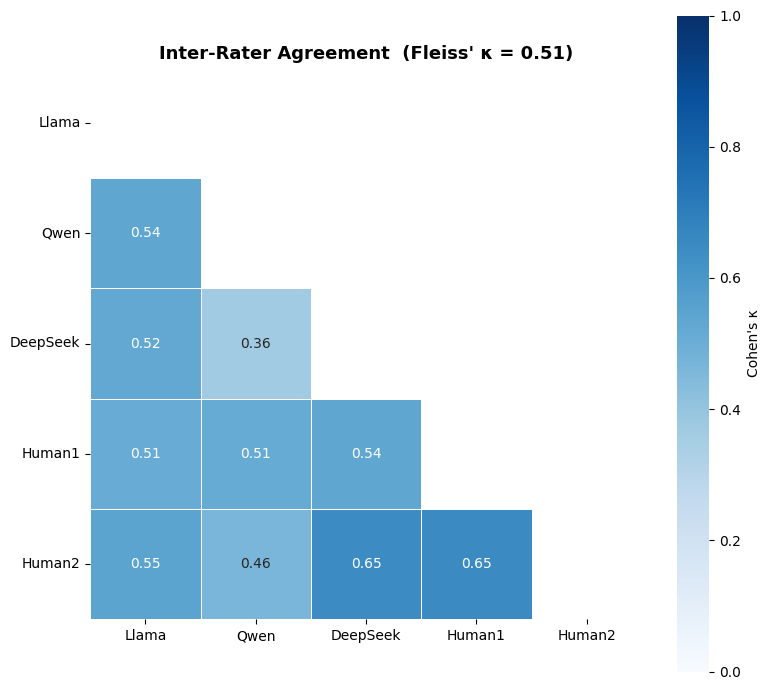

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    cohen_kappa_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from statsmodels.stats.inter_rater import fleiss_kappa

# ============================================================
# CONFIG
# ============================================================

LLM_FILE = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/eval_cache/annotation_sheet_shared.xlsx"

POP_COUNTS = {
    "agreed_critical":   9988,
    "agreed_equivalent": 4729,
    "disagreed":         5822,
}
TOTAL_POP = sum(POP_COUNTS.values())

# ============================================================
# LOAD & CLEAN
# ============================================================

df = pd.read_excel(LLM_FILE)
print(f"Loaded: {len(df)} rows")

def to_bool(x):
    return str(x).strip().lower() in {"true", "1", "1.0", "yes"}

# ============================================================
# APPLY MASK (drop rows where gold label is missing)
# ============================================================

gold_raw = df["human_consensus_CCER"].map(to_bool)
mask = df["human_consensus_CCER"].notna()
df = df[mask].reset_index(drop=True)
print(f"After dropping missing gold labels: {len(df)} rows")

# ============================================================
# LABELS  (all derived from the same filtered, reset df)
# ============================================================

j1   = df["judge1_llama_CCER"].map(to_bool)
j2   = df["judge2_qwen_CCER"].map(to_bool)
j3   = df["judge3_deepseek_CCER"].map(to_bool)
h1   = df["human1_CCER"].map(to_bool)
h2   = df["human2_CCER"].map(to_bool)
gold = df["human_consensus_CCER"].map(to_bool)
llm_consensus = df["llm_consensus_CCER"].map(to_bool)

# ============================================================
# POPULATION WEIGHTS  (computed from the same filtered df)
# ============================================================

sample_counts = df["sample_type"].value_counts()

weights = df["sample_type"].map(
    lambda x: (POP_COUNTS[x] / TOTAL_POP) / (sample_counts[x] / len(df))
).values

print(f"\nWeight sanity check — unique weights: {np.unique(weights.round(4))}")
print(f"Weight sum: {weights.sum():.2f}  (expected ≈ {len(df)})")

# ============================================================
# HELPERS
# ============================================================

def weighted_kappa(y1, y2, w):
    """Population-reweighted Cohen's kappa for binary labels."""
    y1 = np.array(y1, dtype=int)
    y2 = np.array(y2, dtype=int)
    w  = np.array(w,  dtype=float)

    cm = np.zeros((2, 2))
    for i in range(len(y1)):
        cm[y1[i], y2[i]] += w[i]

    n  = w.sum()
    Po = np.diag(cm).sum() / n
    Pe = ((cm.sum(axis=1) / n) @ (cm.sum(axis=0) / n))
    return (Po - Pe) / (1 - Pe)


def interpret(k):
    if k < 0:    return "Less than chance"
    if k < 0.2:  return "Slight"
    if k < 0.4:  return "Fair"
    if k < 0.6:  return "Moderate"
    if k < 0.8:  return "Substantial"
    return "Almost perfect"


def compute_metrics(name, y_true, y_pred):
    y_true = np.array(y_true, dtype=int)
    y_pred = np.array(y_pred, dtype=int)
    agreement = (y_true == y_pred).mean() * 100

    print(f"\n{name}")
    print("-" * len(name))
    print(f"  Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  Recall:    {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  F1:        {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  Agreement: {agreement:.2f}%")

# ============================================================
# WEIGHTED KAPPA
# ============================================================

print("\n=== WEIGHTED KAPPA (population-reweighted) ===")
pairs_wk = [
    ("Human1 – Llama",    h1, j1),
    ("Human1 – Qwen",     h1, j2),
    ("Human1 – DeepSeek", h1, j3),
    ("Llama  – Qwen",     j1, j2),
    ("Llama  – DeepSeek", j1, j3),
    ("Qwen   – DeepSeek", j2, j3),
    ("Human1 – Human2",   h1, h2),
]
for label, a, b in pairs_wk:
    k = weighted_kappa(a, b, weights)
    print(f"  {label:<22}  κ = {k:.4f}  ({interpret(k)})")

# ============================================================
# COHEN'S KAPPA (unweighted, for comparison & heatmap)
# ============================================================

kappa_j1_j2 = cohen_kappa_score(j1, j2)
kappa_j1_j3 = cohen_kappa_score(j1, j3)
kappa_j2_j3 = cohen_kappa_score(j2, j3)
kappa_h1_j1 = cohen_kappa_score(h1, j1)
kappa_h1_j2 = cohen_kappa_score(h1, j2)
kappa_h1_j3 = cohen_kappa_score(h1, j3)
kappa_h2_j1 = cohen_kappa_score(h2, j1)
kappa_h2_j2 = cohen_kappa_score(h2, j2)
kappa_h2_j3 = cohen_kappa_score(h2, j3)
kappa_h1_h2 = cohen_kappa_score(h1, h2)

print("\n=== COHEN'S KAPPA (unweighted) ===")
print("\n  LLM vs LLM")
print(f"    Llama  – Qwen:     {kappa_j1_j2:.4f}  ({interpret(kappa_j1_j2)})")
print(f"    Llama  – DeepSeek: {kappa_j1_j3:.4f}  ({interpret(kappa_j1_j3)})")
print(f"    Qwen   – DeepSeek: {kappa_j2_j3:.4f}  ({interpret(kappa_j2_j3)})")

print("\n  Human1 vs LLM")
print(f"    Human1 – Llama:    {kappa_h1_j1:.4f}  ({interpret(kappa_h1_j1)})")
print(f"    Human1 – Qwen:     {kappa_h1_j2:.4f}  ({interpret(kappa_h1_j2)})")
print(f"    Human1 – DeepSeek: {kappa_h1_j3:.4f}  ({interpret(kappa_h1_j3)})")

print("\n  Human2 vs LLM")
print(f"    Human2 – Llama:    {kappa_h2_j1:.4f}  ({interpret(kappa_h2_j1)})")
print(f"    Human2 – Qwen:     {kappa_h2_j2:.4f}  ({interpret(kappa_h2_j2)})")
print(f"    Human2 – DeepSeek: {kappa_h2_j3:.4f}  ({interpret(kappa_h2_j3)})")

print("\n  Human vs Human")
print(f"    Human1 – Human2:   {kappa_h1_h2:.4f}  ({interpret(kappa_h1_h2)})")

# ============================================================
# FLEISS KAPPA  3 LLMs
# ============================================================


def weighted_fleiss_kappa(rating_matrix, w):
    """
    Population-reweighted Fleiss kappa.
    rating_matrix: (N, k) where each row sums to number of raters
    w: sample weights (N,)
    """
    w = np.array(w, dtype=float)
    N, k = rating_matrix.shape
    n = rating_matrix[0].sum()  # raters per sample (assumed constant)

    # Weighted proportions per category
    W = w.sum()
    p_j = (rating_matrix * w[:, None]).sum(axis=0) / (W * n)

    # Weighted P_i (agreement within each sample)
    P_i = ((rating_matrix ** 2).sum(axis=1) - n) / (n * (n - 1))

    # Weighted mean observed agreement
    P_bar = (w * P_i).sum() / W

    # Expected agreement by chance
    P_e = (p_j ** 2).sum()

    return (P_bar - P_e) / (1 - P_e)


def build_fleiss_llm(dataframe):
    N = len(dataframe)
    matrix = np.zeros((N, 2), dtype=float)
    for i, (_, row) in enumerate(dataframe.iterrows()):
        judges = [
            to_bool(row["judge1_llama_CCER"]),
            to_bool(row["judge2_qwen_CCER"]),
            to_bool(row["judge3_deepseek_CCER"]),
        ]
        matrix[i, 0] = sum(not j for j in judges)
        matrix[i, 1] = sum(j for j in judges)
    return matrix

# ============================================================
# FLEISS KAPPA — unweighted (stratified sample) 
#              + weighted (population-reweighted)
# ============================================================

llm_matrix = build_fleiss_llm(df)

fleiss_llm_unweighted = fleiss_kappa(llm_matrix, method="fleiss")
fleiss_llm_weighted   = weighted_fleiss_kappa(llm_matrix, weights)

print(f"\n=== FLEISS κ (3 LLMs) ===")
print(f"  Unweighted (stratified sample):      {fleiss_llm_unweighted:.4f}  ({interpret(fleiss_llm_unweighted)})")
print(f"  Weighted   (population-reweighted):  {fleiss_llm_weighted:.4f}  ({interpret(fleiss_llm_weighted)})")


# fleiss_k = fleiss_kappa(build_fleiss_matrix(df), method="fleiss")
# print(f"\n=== FLEISS κ (3 LLMs + Human2) ===")
# print(f"  Fleiss κ = {fleiss_k:.4f}  ({interpret(fleiss_k)})")

# ============================================================
# EVALUATION vs HUMAN CONSENSUS GOLD
# ============================================================

print("\n=== vs HUMAN CONSENSUS (GOLD) ===")
compute_metrics("Llama        vs Gold", gold, j1)
compute_metrics("Qwen         vs Gold", gold, j2)
compute_metrics("DeepSeek     vs Gold", gold, j3)
compute_metrics("LLM Consensus vs Gold", gold, llm_consensus)

# ============================================================
# HEATMAP  (fully symmetric 5×5)
# ============================================================

judge_names = ["Llama", "Qwen", "DeepSeek", "Human1", "Human2"]

kappa_matrix = np.array([
    [1.0,         kappa_j1_j2,  kappa_j1_j3,  kappa_h1_j1,  kappa_h2_j1],
    [kappa_j1_j2, 1.0,          kappa_j2_j3,  kappa_h1_j2,  kappa_h2_j2],
    [kappa_j1_j3, kappa_j2_j3,  1.0,          kappa_h1_j3,  kappa_h2_j3],
    [kappa_h1_j1, kappa_h1_j2,  kappa_h1_j3,  1.0,          kappa_h1_h2],
    [kappa_h2_j1, kappa_h2_j2,  kappa_h2_j3,  kappa_h1_h2,  1.0        ],
])

# verify symmetry
assert np.allclose(kappa_matrix, kappa_matrix.T), "Matrix is not symmetric!"

df_kappa = pd.DataFrame(kappa_matrix, index=judge_names, columns=judge_names)

mask_upper = np.triu(np.ones_like(df_kappa, dtype=bool))

plt.figure(figsize=(8, 7))
ax = sns.heatmap(
    df_kappa,
    mask=mask_upper,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Cohen's κ"},
    vmin=0,
    vmax=1,
)
plt.title(
    f"Inter-Rater Agreement  (Fleiss' κ = {fleiss_k:.2f})",
    fontsize=13,
    fontweight="bold",
)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()

out_path = "kappa_heatmap.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"\nSaved heatmap → {out_path}")
plt.show()

In [17]:
# print(df_h1.columns)
# print(df_llm.columns)
# print(len(valid))

In [1]:
"""
Error Type Annotation Dataset Preparation
==========================================
Prepares a dataset for human annotation of ATC error categories.
Outputs both a wide CSV (for κ computation) and a long CSV (for human annotators).
"""

import os
import json
import glob
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

# ============================================================
# CONFIG — update paths to match your environment
# ============================================================

JUDGES = {
    "llama":    "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/llama_70b_annotation",
    "qwen":     "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/qwen_72b_annotation",
    "deepseek": "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/deepseek_llama_70b_annotation",
}

ANNOTATION_SHEET  = "./eval_cache/annotation_sheet_shared.csv"
OUT_WIDE          = "./eval_cache/error_type_annotation_wide.csv"
OUT_LONG          = "./eval_cache/error_type_annotation_long.csv"

VALID_CLASSES = [
    "callsign", "altitude", "heading", "runway",
    "frequency", "clearance", "navigation", "weather", "other"
]
VALID_CLASSES_SET = set(VALID_CLASSES)

# ============================================================
# STEP 1 — Frequency analysis across all critical records
# ============================================================

def get_error_types(records):
    """
    For each Critical_Errors record, return the set of valid entity_types.
    Multi-label: a record can have multiple types.
    """
    out = []
    for r in records:
        if r.get("contextual_status") != "Critical_Errors":
            continue
        types = set()
        for err in r.get("transcription_errors", []):
            et = err.get("entity_type", "").lower().strip()
            if et in VALID_CLASSES_SET:
                types.add(et)
        if types:
            out.append(types)
    return out



print("=" * 60)
print("STEP 1: Error type frequency per judge")
print("=" * 60)

for judge_name, judge_dir in JUDGES.items():
    all_types = []
    for fpath in sorted(glob.glob(os.path.join(judge_dir, "*.json"))):
        with open(fpath) as f:
            records = json.load(f)["records"]
        all_types.extend(get_error_types(records))

    if not all_types:
        print(f"\n[{judge_name}] No critical records found — check path: {judge_dir}")
        continue

    class_counts = Counter()
    for types in all_types:
        for t in types:
            class_counts[t] += 1

    print(f"\n[{judge_name}] Critical records with ≥1 error type: {len(all_types)}")
    print(f"  Multi-label (>1 type): {sum(1 for t in all_types if len(t) > 1)}")
    for cls, cnt in class_counts.most_common():
        print(f"  {cls:15s}: {cnt:5d}  ({100 * cnt / len(all_types):.1f}%)")

# ============================================================
# STEP 2 — Build composite key lookup per judge
# ============================================================

def load_judge_index(judge_dir):
    """
    Returns dict:
        (reference, hypothesis) -> frozenset(entity_types)
    """
    index = {}
    for fpath in sorted(glob.glob(os.path.join(judge_dir, "*.json"))):
        with open(fpath) as f:
            data = json.load(f)
        for r in data["records"]:
            if r.get("contextual_status") != "Critical_Errors":
                continue
            key = (
                r.get("reference", "").strip().lower(),
                r.get("hypothesis", "").strip().lower(),
            )
            types = set()
            for err in r.get("transcription_errors", []):
                et = err.get("entity_type", "").lower().strip()
                if et in VALID_CLASSES_SET:
                    types.add(et)
            index[key] = frozenset(types)
    return index

print("\n" + "=" * 60)
print("STEP 2: Building judge indexes")
print("=" * 60)

judge_indexes = {}
for judge_name, judge_dir in JUDGES.items():
    idx = load_judge_index(judge_dir)
    judge_indexes[judge_name] = idx
    print(f"  [{judge_name}] Indexed {len(idx)} critical (ref, hyp) pairs")

# ============================================================
# STEP 3 — Load annotation sheet and filter to agreed_critical
# ============================================================

print("\n" + "=" * 60)
print("STEP 3: Loading annotation sheet")
print("=" * 60)

df = pd.read_csv(ANNOTATION_SHEET)
critical_df = df[df["sample_type"] == "agreed_critical"].copy().reset_index(drop=True)
print(f"  Agreed-critical samples: {len(critical_df)}")

# Normalised key columns for joining
critical_df["_ref_key"] = critical_df["reference"].str.strip().str.lower()
critical_df["_hyp_key"] = critical_df["hypothesis"].str.strip().str.lower()

# ============================================================
# STEP 4 — Add per-class binary columns for each judge
# ============================================================

print("\n" + "=" * 60)
print("STEP 4: Adding judge binary columns")
print("=" * 60)

# Track how many samples each judge matched
match_counts = defaultdict(int)

for cls in VALID_CLASSES:
    for judge_name, idx in judge_indexes.items():
        col = f"judge_{judge_name}_{cls}"

        def lookup(row, _idx=idx, _cls=cls):
            key = (row["_ref_key"], row["_hyp_key"])
            types = _idx.get(key)
            if types is None:
                return np.nan       # judge never saw this sample
            return int(_cls in types)

        critical_df[col] = critical_df.apply(lookup, axis=1)

# Report match rate per judge (using first class as proxy — same for all)
for judge_name in judge_indexes:
    col = f"judge_{judge_name}_{VALID_CLASSES[0]}"
    matched = critical_df[col].notna().sum()
    print(f"  [{judge_name}] Matched {matched}/{len(critical_df)} samples")
    if matched < len(critical_df):
        missing = critical_df[critical_df[col].isna()][["reference", "hypothesis"]].head(5)
        print(f"    First unmatched samples:")
        print(missing.to_string(index=False))

# Human annotation placeholders — NaN so downstream κ can use dropna()
for cls in VALID_CLASSES:
    critical_df[f"human1_{cls}"] = np.nan
    critical_df[f"human2_{cls}"] = np.nan

# Drop internal key columns
critical_df.drop(columns=["_ref_key", "_hyp_key"], inplace=True)

# ============================================================
# STEP 5 — Save wide CSV (one row per sample, all binary columns)
# ============================================================

os.makedirs(os.path.dirname(OUT_WIDE), exist_ok=True)
critical_df.to_csv(OUT_WIDE, index=False)
print(f"\n[Wide CSV] Saved {OUT_WIDE}")
print(f"  Shape: {critical_df.shape}")
print(f"  Columns: {list(critical_df.columns)}")

# ============================================================
# STEP 6 — Save long CSV (one row per sample × class — easier to annotate)
#
# Each human annotator fills in a single 0/1 column (human1 or human2)
# per row. Judge votes are shown for context.
# ============================================================

rows = []
for _, row in critical_df.iterrows():
    for cls in VALID_CLASSES:
        rows.append({
            "reference":        row["reference"],
            "hypothesis":       row.get("hypothesis", ""),
            "error_class":      cls,
            # Judge votes (may be NaN if judge didn't see this sample)
            "judge_llama":      row.get(f"judge_llama_{cls}",    np.nan),
            "judge_qwen":       row.get(f"judge_qwen_{cls}",     np.nan),
            "judge_deepseek":   row.get(f"judge_deepseek_{cls}", np.nan),
            # Human annotators fill these in (0 = not this class, 1 = yes this class)
            "human1":           np.nan,
            "human2":           np.nan,
        })

long_df = pd.DataFrame(rows)
long_df.to_csv(OUT_LONG, index=False)
print(f"\n[Long CSV] Saved {OUT_LONG}")
print(f"  Shape: {long_df.shape}  ({len(critical_df)} samples × {len(VALID_CLASSES)} classes)")

# ============================================================
# STEP 7 — Sanity checks
# ============================================================

print("\n" + "=" * 60)
print("STEP 7: Sanity checks")
print("=" * 60)

# Check inter-judge agreement on class assignments (before human annotation)
judge_names = list(judge_indexes.keys())
if len(judge_names) >= 2:
    from sklearn.metrics import cohen_kappa_score

    print("\n  Pairwise inter-judge Cohen's κ per class:")
    print(f"  {'class':15s}", end="")
    pairs = [(judge_names[i], judge_names[j])
             for i in range(len(judge_names))
             for j in range(i+1, len(judge_names))]
    for a, b in pairs:
        print(f"  {a[:5]} vs {b[:5]}", end="")
    print()

    for cls in VALID_CLASSES:
        print(f"  {cls:15s}", end="")
        for a, b in pairs:
            col_a = f"judge_{a}_{cls}"
            col_b = f"judge_{b}_{cls}"
            subset = critical_df[[col_a, col_b]].dropna()
            if len(subset) < 2 or subset[col_a].nunique() < 2 or subset[col_b].nunique() < 2:
                print(f"  {'N/A':>12s}", end="")
            else:
                kappa = cohen_kappa_score(subset[col_a].astype(int), subset[col_b].astype(int))
                print(f"  {kappa:>12.3f}", end="")
        print()

print("\nDone. Share OUT_LONG with human annotators.")
print("After annotation, use OUT_WIDE for κ computation across all annotators.")

STEP 1: Error type frequency per judge

[llama] Critical records with ≥1 error type: 13845
  Multi-label (>1 type): 298
  callsign       : 10415  (75.2%)
  clearance      :  1139  (8.2%)
  other          :   943  (6.8%)
  runway         :   576  (4.2%)
  navigation     :   468  (3.4%)
  altitude       :   258  (1.9%)
  weather        :   227  (1.6%)
  frequency      :   156  (1.1%)
  heading        :   112  (0.8%)

[qwen] Critical records with ≥1 error type: 11421
  Multi-label (>1 type): 6351
  callsign       :  9456  (82.8%)
  other          :  3606  (31.6%)
  runway         :  1650  (14.4%)
  clearance      :  1311  (11.5%)
  navigation     :  1149  (10.1%)
  weather        :   860  (7.5%)
  frequency      :   764  (6.7%)
  altitude       :   438  (3.8%)
  heading        :   118  (1.0%)

[deepseek] Critical records with ≥1 error type: 14596
  Multi-label (>1 type): 5426
  callsign       : 12191  (83.5%)
  other          :  3078  (21.1%)
  runway         :  1536  (10.5%)
  navigation

In [9]:
"""
Error Type Annotation Dataset Preparation + Evaluation
======================================================

This script:

1. Builds annotation sheets from judge JSON outputs
2. Saves:
      - Wide CSV
      - Long CSV
3. AFTER human annotation:
      - Loads annotated long CSV
      - Merges human labels back into wide format
      - Computes:
            * Cohen's κ
            * Precision
            * Recall
            * F1
            * Accuracy

NOTE:
- Only ONE human annotator is assumed.
- Human fills ONLY the `human1` column in OUT_LONG.
"""

import os
import json
import glob
import numpy as np
import pandas as pd

from collections import Counter, defaultdict

from sklearn.metrics import (
    cohen_kappa_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)

# ============================================================
# CONFIG
# ============================================================

JUDGES = {
    "llama":    "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/llama_70b_annotation",
    "qwen":     "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/qwen_72b_annotation",
    "deepseek": "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/deepseek_llama_70b_annotation",
}

ANNOTATION_SHEET = "./eval_cache/annotation_sheet_shared.csv"

OUT_WIDE = "./eval_cache/error_type_annotation_wide.csv"

OUT_LONG = "./eval_cache/error_type_annotation_long.csv"

# AFTER HUMAN ANNOTATION:
ANNOTATED_LONG = "./eval_cache/error_type_annotation_long_annotated.csv"

VALID_CLASSES = [
    "callsign",
    "altitude",
    "heading",
    "runway",
    "frequency",
    "clearance",
    "navigation",
    "weather",
    "other",
]

VALID_CLASSES_SET = set(VALID_CLASSES)

# ============================================================
# STEP 1 — Frequency analysis
# ============================================================

def get_error_types(records):

    out = []

    for r in records:

        if r.get("contextual_status") != "Critical_Errors":
            continue

        types = set()

        for err in r.get("transcription_errors", []):

            et = err.get("entity_type", "").lower().strip()

            if et in VALID_CLASSES_SET:
                types.add(et)

        if types:
            out.append(types)

    return out


print("=" * 60)
print("STEP 1: Error type frequency per judge")
print("=" * 60)

for judge_name, judge_dir in JUDGES.items():

    all_types = []

    for fpath in sorted(glob.glob(os.path.join(judge_dir, "*.json"))):

        with open(fpath) as f:
            records = json.load(f)["records"]

        all_types.extend(get_error_types(records))

    if not all_types:
        print(f"\n[{judge_name}] No critical records found")
        continue

    class_counts = Counter()

    for types in all_types:
        for t in types:
            class_counts[t] += 1

    print(f"\n[{judge_name}] Critical records with ≥1 type: {len(all_types)}")

    print(f"  Multi-label (>1 type): "
          f"{sum(1 for t in all_types if len(t) > 1)}")

    for cls, cnt in class_counts.most_common():

        print(f"  {cls:15s}: {cnt:5d} "
              f"({100 * cnt / len(all_types):.1f}%)")

# ============================================================
# STEP 2 — Build judge indexes
# ============================================================

def load_judge_index(judge_dir):

    index = {}

    for fpath in sorted(glob.glob(os.path.join(judge_dir, "*.json"))):

        with open(fpath) as f:
            data = json.load(f)

        for r in data["records"]:

            if r.get("contextual_status") != "Critical_Errors":
                continue

            key = (
                r.get("reference", "").strip().lower(),
                r.get("hypothesis", "").strip().lower(),
            )

            types = set()

            for err in r.get("transcription_errors", []):

                et = err.get("entity_type", "").lower().strip()

                if et in VALID_CLASSES_SET:
                    types.add(et)

            index[key] = frozenset(types)

    return index


print("\n" + "=" * 60)
print("STEP 2: Building judge indexes")
print("=" * 60)

judge_indexes = {}

for judge_name, judge_dir in JUDGES.items():

    idx = load_judge_index(judge_dir)

    judge_indexes[judge_name] = idx

    print(f"  [{judge_name}] Indexed {len(idx)} critical pairs")

# ============================================================
# STEP 3 — Load annotation sheet
# ============================================================

print("\n" + "=" * 60)
print("STEP 3: Loading annotation sheet")
print("=" * 60)

df = pd.read_csv(ANNOTATION_SHEET)

critical_df = (
    df[df["sample_type"] == "agreed_critical"]
    .copy()
    .reset_index(drop=True)
)

print(f"  Agreed-critical samples: {len(critical_df)}")

critical_df["_ref_key"] = (
    critical_df["reference"]
    .str.strip()
    .str.lower()
)

critical_df["_hyp_key"] = (
    critical_df["hypothesis"]
    .str.strip()
    .str.lower()
)

# ============================================================
# STEP 4 — Add judge binary columns
# ============================================================

print("\n" + "=" * 60)
print("STEP 4: Adding judge binary columns")
print("=" * 60)

for cls in VALID_CLASSES:

    for judge_name, idx in judge_indexes.items():

        col = f"judge_{judge_name}_{cls}"

        def lookup(row, _idx=idx, _cls=cls):

            key = (row["_ref_key"], row["_hyp_key"])

            types = _idx.get(key)

            if types is None:
                return np.nan

            return int(_cls in types)

        critical_df[col] = critical_df.apply(lookup, axis=1)

for judge_name in judge_indexes:

    col = f"judge_{judge_name}_{VALID_CLASSES[0]}"

    matched = critical_df[col].notna().sum()

    print(f"  [{judge_name}] Matched "
          f"{matched}/{len(critical_df)} samples")

# ============================================================
# STEP 5 — Placeholder human columns
# ============================================================

for cls in VALID_CLASSES:
    critical_df[f"human1_{cls}"] = np.nan

critical_df.drop(columns=["_ref_key", "_hyp_key"], inplace=True)

# ============================================================
# STEP 6 — Save wide CSV
# ============================================================

os.makedirs(os.path.dirname(OUT_WIDE), exist_ok=True)

critical_df.to_csv(OUT_WIDE, index=False)

print(f"\n[Wide CSV] Saved {OUT_WIDE}")
print(f"  Shape: {critical_df.shape}")

# ============================================================
# STEP 7 — Save long CSV
# ============================================================

rows = []

for _, row in critical_df.iterrows():

    for cls in VALID_CLASSES:

        rows.append({

            "reference": row["reference"],
            "hypothesis": row.get("hypothesis", ""),
            "error_class": cls,

            "judge_llama":
                row.get(f"judge_llama_{cls}", np.nan),

            "judge_qwen":
                row.get(f"judge_qwen_{cls}", np.nan),

            "judge_deepseek":
                row.get(f"judge_deepseek_{cls}", np.nan),

            # HUMAN FILLS THIS
            "human1": np.nan,
        })

long_df = pd.DataFrame(rows)

long_df.to_csv(OUT_LONG, index=False)

print(f"\n[Long CSV] Saved {OUT_LONG}")

print(f"  Shape: {long_df.shape}")

# ============================================================
# STEP 8 — Pairwise inter-judge κ
# ============================================================

print("\n" + "=" * 60)
print("STEP 8: Pairwise inter-judge Cohen κ")
print("=" * 60)

judge_names = list(judge_indexes.keys())

pairs = [
    (judge_names[i], judge_names[j])
    for i in range(len(judge_names))
    for j in range(i + 1, len(judge_names))
]

print(f"\n{'class':15s}", end="")

for a, b in pairs:
    print(f"{a[:5]} vs {b[:5]:>12s}", end="")

print()

for cls in VALID_CLASSES:

    print(f"{cls:15s}", end="")

    for a, b in pairs:

        col_a = f"judge_{a}_{cls}"
        col_b = f"judge_{b}_{cls}"

        subset = critical_df[[col_a, col_b]].dropna()

        if (
            len(subset) < 2
            or subset[col_a].nunique() < 2
            or subset[col_b].nunique() < 2
        ):
            print(f"{'N/A':>17s}", end="")
            continue

        kappa = cohen_kappa_score(
            subset[col_a].astype(int),
            subset[col_b].astype(int),
        )

        print(f"{kappa:17.3f}", end="")

    print()

# ============================================================
# STEP 9 — HUMAN EVALUATION
# ============================================================

print("\n" + "=" * 60)
print("STEP 9: Human agreement evaluation")
print("=" * 60)

if not os.path.exists(ANNOTATED_LONG):

    print(f"\nAnnotated file not found:")
    print(f"  {ANNOTATED_LONG}")

    print("\nPlease:")
    print("1. Open OUT_LONG")
    print("2. Fill human1 column with 0/1")
    print("3. Save as:")
    print(f"   {ANNOTATED_LONG}")

else:

    print(f"\nLoading annotated file:")
    print(f"  {ANNOTATED_LONG}")

    annotated_df = pd.read_csv(ANNOTATED_LONG)

    # --------------------------------------------------------
    # Human annotation distribution (mirrors Step 1)
    # --------------------------------------------------------

    print("\nHuman annotator error type distribution:")
    print("=" * 60)

    # Filter to rows where human1 == 1 (annotated as present)
    human_positive = annotated_df[annotated_df["human1"] == 1]

    # Group by reference/hypothesis pair to get per-record type sets
    # (mirrors how Step 1 builds a set of types per critical record)
    human_type_sets = (
        human_positive
        .groupby(["reference", "hypothesis"])["error_class"]
        .apply(lambda x: frozenset(x.tolist()))
        .tolist()
    )

    total_records = annotated_df[["reference", "hypothesis"]].drop_duplicates().shape[0]
    records_with_type = len(human_type_sets)

    print(f"\n[human1] Critical records with ≥1 type: {records_with_type}")
    print(f"  Multi-label (>1 type): {sum(1 for t in human_type_sets if len(t) > 1)}")

    class_counts = Counter(
        cls
        for types in human_type_sets
        for cls in types
    )

    for cls, cnt in class_counts.most_common():
        print(f"  {cls:15s}: {cnt:5d} "
              f"({100 * cnt / records_with_type:.1f}%)")
              
    # --------------------------------------------------------
    # Pivot human annotations back to wide
    # --------------------------------------------------------

    human1_wide = (
        annotated_df
        .pivot_table(
            index=["reference", "hypothesis"],
            columns="error_class",
            values="human1",
        )
        .reset_index()
    )

    human1_wide.columns = [

        f"human1_{c}"
        if c not in ["reference", "hypothesis"]
        else c

        for c in human1_wide.columns
    ]

    eval_df = critical_df.merge(
        human1_wide,
        on=["reference", "hypothesis"],
        how="left",
        suffixes=("", "_new")
    )

    # Remove old placeholder cols
    for cls in VALID_CLASSES:

        old_col = f"human1_{cls}"
        new_col = f"{old_col}_new"

        if new_col in eval_df.columns:
            eval_df.drop(columns=[old_col], inplace=True)
            eval_df.rename(columns={new_col: old_col}, inplace=True)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    print("\nPer-class agreement with human annotator:")
    print("=" * 60)

    for cls in VALID_CLASSES:

        print(f"\n[{cls}]")

        human_col = f"human1_{cls}"

        for judge_name in judge_names:

            judge_col = f"judge_{judge_name}_{cls}"

            subset = eval_df[[judge_col, human_col]].dropna()

            if len(subset) < 2:

                print(f"  {judge_name:10s}: insufficient data")
                continue

            y_true = subset[human_col].astype(int)
            y_pred = subset[judge_col].astype(int)

            try:
                kappa = cohen_kappa_score(y_true, y_pred)
            except:
                kappa = np.nan

            precision = precision_score(
                y_true,
                y_pred,
                zero_division=0
            )

            recall = recall_score(
                y_true,
                y_pred,
                zero_division=0
            )

            f1 = f1_score(
                y_true,
                y_pred,
                zero_division=0
            )

            acc = accuracy_score(y_true, y_pred)

            print(
                f"  {judge_name:10s} | "
                f"κ={kappa:6.3f} | "
                f"Acc={acc:6.3f} | "
                f"P={precision:6.3f} | "
                f"R={recall:6.3f} | "
                f"F1={f1:6.3f} | "
                f"N={len(subset)}"
            )

print("\nDone.")

STEP 1: Error type frequency per judge

[llama] Critical records with ≥1 type: 13845
  Multi-label (>1 type): 298
  callsign       : 10415 (75.2%)
  clearance      :  1139 (8.2%)
  other          :   943 (6.8%)
  runway         :   576 (4.2%)
  navigation     :   468 (3.4%)
  altitude       :   258 (1.9%)
  weather        :   227 (1.6%)
  frequency      :   156 (1.1%)
  heading        :   112 (0.8%)

[qwen] Critical records with ≥1 type: 11421
  Multi-label (>1 type): 6351
  callsign       :  9456 (82.8%)
  other          :  3606 (31.6%)
  runway         :  1650 (14.4%)
  clearance      :  1311 (11.5%)
  navigation     :  1149 (10.1%)
  weather        :   860 (7.5%)
  frequency      :   764 (6.7%)
  altitude       :   438 (3.8%)
  heading        :   118 (1.0%)

[deepseek] Critical records with ≥1 type: 14596
  Multi-label (>1 type): 5426
  callsign       : 12191 (83.5%)
  other          :  3078 (21.1%)
  runway         :  1536 (10.5%)
  navigation     :  1357 (9.3%)
  clearance      : 

In [ ]:
# ! pip install krippendorff


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [30]:
import krippendorff

def krippendorff_alpha_per_class(dataframe, judge_cols, valid_classes):
    """
    Computes Krippendorff's alpha for each error class across all judges.
    Uses nominal metric (binary labels, no ordering assumed).
    Missing values (NaN) are handled natively.
    """
    print("\n=== KRIPPENDORFF'S α PER CLASS ===")
    print(f"  {'class':15s}  {'α':>8s}  interpretation")
    print(f"  {'-'*15}  {'-'*8}  {'-'*20}")

    results = {}
    for cls in valid_classes:
        # Build reliability matrix: shape (raters, items)
        # krippendorff expects NaN for missing
        cols = [f"judge_{j}_{cls}" for j in judge_cols]
        matrix = dataframe[cols].T.values.astype(float)  # (n_raters, n_items)

        # Replace any non-NaN with int to be safe
        matrix = np.where(np.isnan(matrix), np.nan, matrix)

        try:
            alpha = krippendorff.alpha(
                reliability_data=matrix,
                level_of_measurement="nominal"
            )
        except Exception as e:
            alpha = float("nan")
            print(f"  {cls:15s}  ERROR: {e}")
            continue

        results[cls] = alpha
        print(f"  {cls:15s}  {alpha:>8.3f}  {interpret(alpha)}")

    return results

for cls in VALID_CLASSES:
    col = f"judge_llama_{cls}"
    n_positive = (critical_df[col] == 1).sum()
    n_total    = critical_df[col].notna().sum()
    print(f"  {cls:15s}  positives: {n_positive:3d} / {n_total}  ({100*n_positive/n_total:.1f}%)")

# Run it
alpha_results = krippendorff_alpha_per_class(
    critical_df,
    judge_cols=["llama", "qwen", "deepseek"],
    valid_classes=VALID_CLASSES
)

  callsign         positives: 113 / 150  (75.3%)
  altitude         positives:   2 / 150  (1.3%)
  heading          positives:   1 / 150  (0.7%)
  runway           positives:   6 / 150  (4.0%)
  frequency        positives:   4 / 150  (2.7%)
  clearance        positives:  17 / 150  (11.3%)
  navigation       positives:   5 / 150  (3.3%)
  weather          positives:   1 / 150  (0.7%)
  other            positives:  13 / 150  (8.7%)

=== KRIPPENDORFF'S α PER CLASS ===
  class                   α  interpretation
  ---------------  --------  --------------------
  callsign            0.573  Moderate
  altitude            0.434  Moderate
  heading             0.494  Moderate
  runway              0.309  Fair
  frequency           0.649  Substantial
  clearance           0.423  Moderate
  navigation          0.501  Moderate
  weather             0.371  Fair
  other               0.251  Fair


In [32]:
print("\nPositive counts per judge per class:")
print(f"  {'class':15s}  {'llama':>8s}  {'qwen':>8s}  {'deepseek':>8s}")
for cls in VALID_CLASSES:
    counts = [
        (critical_df[f"judge_{j}_{cls}"] == 1).sum()
        for j in ["llama", "qwen", "deepseek"]
    ]
    print(f"  {cls:15s}  {counts[0]:>8d}  {counts[1]:>8d}  {counts[2]:>8d}")


Positive counts per judge per class:
  class               llama      qwen  deepseek
  callsign              113       128       126
  altitude                2         4         3
  heading                 1         1         4
  runway                  6        32        24
  frequency               4        11         9
  clearance              17        24        26
  navigation              5        14        11
  weather                 1        16        10
  other                  13        47        39


In [31]:
def krippendorff_alpha_overall(dataframe, judge_cols, valid_classes):
    """
    Pools all class columns into one long reliability matrix.
    Treats each (sample, class) pair as an independent item.
    """
    all_cols_per_judge = {
        j: [f"judge_{j}_{cls}" for cls in valid_classes]
        for j in judge_cols
    }

    # Stack: for each judge, concatenate all class columns into one long vector
    rows = []
    for j in judge_cols:
        row = np.concatenate([
            dataframe[col].values.astype(float)
            for col in all_cols_per_judge[j]
        ])
        rows.append(row)

    matrix = np.array(rows)  # (n_raters, n_items * n_classes)

    alpha = krippendorff.alpha(
        reliability_data=matrix,
        level_of_measurement="nominal"
    )
    print(f"\n  Overall α (all classes pooled): {alpha:.3f}  ({interpret(alpha)})")
    return alpha

alpha_overall = krippendorff_alpha_overall(
    critical_df,
    judge_cols=["llama", "qwen", "deepseek"],
    valid_classes=VALID_CLASSES
)


  Overall α (all classes pooled): 0.646  (Substantial)


the LLM judge is reliable for operational safety assessment (CCER) but only moderately reliable for fine-grained error taxonomy, particularly for rare and ambiguous categories.

In [1]:
"""
Prompt Robustness Analysis: Accuracy + Consistency Metrics
===========================================================
Analyzes LLM-as-Judge outputs across prompt variants with ground truth.

Metrics computed:
1. Accuracy (per-prompt, per-model)
2. Inter-prompt agreement (Fleiss' Kappa, pairwise agreement)
3. Robustness-accuracy tradeoffs (consistent-correct, consistent-wrong, etc.)
4. Prompt sensitivity analysis
5. Comprehensive visualizations
"""

import json
import os
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# Statistical tests
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, cohen_kappa_score
)
from scipy.stats import entropy

# ============================================================
# CONFIGURATION
# ============================================================

OUTPUT_ROOT = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/prompt_robustness_outputs"
BENCHMARK_JSON = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/eval_cache/prompt_robustness_benchmark.json"
EXCEL_PATH = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/eval_cache/annotation_sheet_shared.xlsx"
ANALYSIS_OUTPUT = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/prompt_robustness_analysis"

MODELS = ["qwen", "llama", "deepseek"]
PROMPTS = ["cot_v3", "compressed", "no_examples", "lenient"]

# ============================================================
# DATA LOADING
# ============================================================

def load_all_outputs() -> Dict[str, Dict[str, List[dict]]]:
    """
    Returns: {model: {prompt: [records]}}
    """
    data = defaultdict(dict)
    
    for model in MODELS:
        for prompt in PROMPTS:
            path = Path(OUTPUT_ROOT) / prompt / f"{model}.json"
            if path.exists():
                with open(path) as f:
                    content = json.load(f)
                    data[model][prompt] = content['records']
                print(f"✓ Loaded {model}/{prompt}: {len(content['records'])} samples")
            else:
                print(f"✗ Missing: {path}")
    
    return data

def load_ground_truth() -> pd.DataFrame:
    """Load ground truth from Excel and benchmark JSON for matching."""
    # Load Excel
    df = pd.read_excel(EXCEL_PATH)
    
    # Load benchmark for sample_id mapping
    with open(BENCHMARK_JSON) as f:
        benchmark = json.load(f)
    
    # Create lookup: (ref, hyp) -> ground truth
    gt_lookup = {}
    for _, row in df.iterrows():
        key = (row['reference'], row['hypothesis'])
        gt_lookup[key] = row['human_consensus_CCER']
    
    # Build ground truth array aligned with benchmark
    ground_truth = []
    matched = 0
    
    for i, sample in enumerate(benchmark):
        key = (sample['reference'], sample['hypothesis'])
        if key in gt_lookup:
            ground_truth.append({
                'sample_index': i,
                'sample_id': sample['sample_id'],
                'reference': sample['reference'],
                'hypothesis': sample['hypothesis'],
                'ground_truth': gt_lookup[key],
            })
            matched += 1
        else:
            # Missing ground truth - mark as None
            ground_truth.append({
                'sample_index': i,
                'sample_id': sample['sample_id'],
                'reference': sample['reference'],
                'hypothesis': sample['hypothesis'],
                'ground_truth': None,
            })
    
    print(f"\nGround truth loaded: {matched}/300 samples matched ({100*matched/300:.1f}%)")
    return pd.DataFrame(ground_truth)

# ============================================================
# METRIC COMPUTATION
# ============================================================

def compute_accuracy_metrics(
    predictions: List[bool],
    ground_truth: List[bool],
    label: str = ""
) -> dict:
    """Compute accuracy, precision, recall, F1."""
    
    # Filter out None values
    valid_pairs = [(p, g) for p, g in zip(predictions, ground_truth) if g is not None and p is not None]
    if not valid_pairs:
        return {
            'accuracy': 0.0,
            'precision': 0.0,
            'recall': 0.0,
            'f1': 0.0,
            'n_samples': 0,
        }
    
    preds, gt = zip(*valid_pairs)
    
    acc = accuracy_score(gt, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        gt, preds, average='binary', zero_division=0
    )
    
    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'n_samples': len(valid_pairs),
    }

def fleiss_kappa(matrix: np.ndarray) -> float:
    """
    Compute Fleiss' Kappa for multi-rater agreement.
    
    Args:
        matrix: (n_samples, n_categories) - count of ratings per category per sample
    
    Returns:
        Fleiss' Kappa score
    """
    n_samples, n_categories = matrix.shape
    n_raters = matrix.sum(axis=1)[0]  # Assume constant raters per sample
    
    # Proportion of all assignments in category j
    p_j = matrix.sum(axis=0) / (n_samples * n_raters)
    
    # Extent of agreement for each sample
    P_i = (matrix ** 2).sum(axis=1) - n_raters
    P_i = P_i / (n_raters * (n_raters - 1))
    
    # Mean agreement
    P_bar = P_i.mean()
    
    # Expected agreement
    P_e = (p_j ** 2).sum()
    
    # Fleiss' Kappa
    kappa = (P_bar - P_e) / (1 - P_e)
    return kappa

def compute_inter_prompt_agreement(
    data: Dict[str, Dict[str, List[dict]]],
    model: str,
    ground_truth_df: pd.DataFrame
) -> dict:
    """Compute agreement metrics across prompts for a single model."""
    
    n_samples = len(ground_truth_df)
    n_prompts = len(PROMPTS)
    
    # Build prediction matrix: (n_samples, n_prompts)
    pred_matrix = np.full((n_samples, n_prompts), np.nan)
    
    for j, prompt in enumerate(PROMPTS):
        if prompt in data[model]:
            records = data[model][prompt]
            for rec in records:
                idx = rec['sample_index']
                if idx < n_samples:
                    pred_matrix[idx, j] = rec.get('is_critical')
    
    # Filter to rows with all prompts present
    complete_mask = ~np.isnan(pred_matrix).any(axis=1)
    pred_complete = pred_matrix[complete_mask]
    
    if len(pred_complete) == 0:
        return {'error': 'No complete samples'}
    
    # Pairwise agreement rate
    pairwise_agreements = []
    for i in range(n_prompts):
        for j in range(i + 1, n_prompts):
            agree = (pred_complete[:, i] == pred_complete[:, j]).mean()
            pairwise_agreements.append(agree)
    
    # Overall agreement (all prompts match)
    all_agree = np.all(pred_complete == pred_complete[:, 0:1], axis=1).mean()
    
    # Fleiss' Kappa (convert to count matrix)
    # For binary: category 0 = False, category 1 = True
    kappa_matrix = np.zeros((len(pred_complete), 2))
    for i, row in enumerate(pred_complete):
        kappa_matrix[i, 0] = (row == 0).sum()  # Count False
        kappa_matrix[i, 1] = (row == 1).sum()  # Count True
    
    kappa = fleiss_kappa(kappa_matrix)
    
    # Per-sample entropy (low = consistent)
    entropies = []
    for row in pred_complete:
        p_true = row.mean()
        if 0 < p_true < 1:
            ent = entropy([p_true, 1 - p_true], base=2)
            entropies.append(ent)
    
    return {
        'n_complete_samples': len(pred_complete),
        'pairwise_agreement_mean': np.mean(pairwise_agreements),
        'pairwise_agreement_std': np.std(pairwise_agreements),
        'all_prompts_agree_rate': all_agree,
        'fleiss_kappa': kappa,
        'mean_entropy': np.mean(entropies) if entropies else 0.0,
    }

def compute_robustness_accuracy_breakdown(
    data: Dict[str, Dict[str, List[dict]]],
    model: str,
    ground_truth_df: pd.DataFrame
) -> dict:
    """
    Categorize samples into:
    - Consistent-Correct: All prompts agree + match ground truth
    - Consistent-Wrong: All prompts agree but wrong
    - Recoverable: Majority vote correct despite disagreement
    - Catastrophic: Majority vote wrong or tie
    """
    
    n_samples = len(ground_truth_df)
    n_prompts = len(PROMPTS)
    
    # Build prediction matrix
    pred_matrix = np.full((n_samples, n_prompts), np.nan)
    
    for j, prompt in enumerate(PROMPTS):
        if prompt in data[model]:
            records = data[model][prompt]
            for rec in records:
                idx = rec['sample_index']
                if idx < n_samples:
                    pred_matrix[idx, j] = rec.get('is_critical')
    
    # Get ground truth
    gt = ground_truth_df['ground_truth'].values
    
    categories = {
        'consistent_correct': 0,
        'consistent_wrong': 0,
        'recoverable': 0,
        'catastrophic': 0,
        'incomplete': 0,
    }
    
    for i in range(n_samples):
        row = pred_matrix[i]
        
        # Skip if ground truth missing
        if pd.isna(gt[i]):
            continue
        
        # Skip if not all prompts present
        if np.isnan(row).any():
            categories['incomplete'] += 1
            continue
        
        # Check consistency
        all_same = len(set(row)) == 1
        majority_vote = row.mean() > 0.5
        
        if all_same:
            if row[0] == gt[i]:
                categories['consistent_correct'] += 1
            else:
                categories['consistent_wrong'] += 1
        else:
            if majority_vote == gt[i]:
                categories['recoverable'] += 1
            else:
                categories['catastrophic'] += 1
    
    total = sum(categories.values())
    percentages = {k: 100 * v / total if total > 0 else 0 
                   for k, v in categories.items()}
    
    return {
        'counts': categories,
        'percentages': percentages,
    }

# ============================================================
# MAIN ANALYSIS
# ============================================================

def main():
    os.makedirs(ANALYSIS_OUTPUT, exist_ok=True)
    
    print("=" * 60)
    print("PROMPT ROBUSTNESS ANALYSIS")
    print("=" * 60)
    
    # Load data
    data = load_all_outputs()
    gt_df = load_ground_truth()
    
    # ========================================
    # 1. ACCURACY METRICS (per model, per prompt)
    # ========================================
    
    print("\n" + "=" * 60)
    print("1. ACCURACY METRICS")
    print("=" * 60)
    
    accuracy_results = []
    
    for model in MODELS:
        for prompt in PROMPTS:
            if prompt not in data[model]:
                continue
            
            records = data[model][prompt]
            
            # Extract predictions
            predictions = [None] * len(gt_df)
            for rec in records:
                idx = rec['sample_index']
                if idx < len(predictions):
                    predictions[idx] = rec.get('is_critical')
            
            # Compute metrics
            metrics = compute_accuracy_metrics(
                predictions,
                gt_df['ground_truth'].tolist(),
                label=f"{model}/{prompt}"
            )
            
            accuracy_results.append({
                'model': model,
                'prompt': prompt,
                **metrics
            })
            
            print(f"{model:>10} | {prompt:>15} | Acc: {metrics['accuracy']:.3f} | F1: {metrics['f1']:.3f} | N: {metrics['n_samples']}")
    
    acc_df = pd.DataFrame(accuracy_results)
    
    # ========================================
    # 2. INTER-PROMPT AGREEMENT (per model)
    # ========================================
    
    print("\n" + "=" * 60)
    print("2. INTER-PROMPT AGREEMENT")
    print("=" * 60)
    
    agreement_results = []
    
    for model in MODELS:
        metrics = compute_inter_prompt_agreement(data, model, gt_df)
        
        if 'error' in metrics:
            print(f"{model:>10} | ERROR: {metrics['error']}")
            continue
        
        agreement_results.append({
            'model': model,
            **metrics
        })
        
        print(f"\n{model.upper()}:")
        print(f"  Complete samples: {metrics['n_complete_samples']}")
        print(f"  Pairwise agreement: {metrics['pairwise_agreement_mean']:.3f} ± {metrics['pairwise_agreement_std']:.3f}")
        print(f"  All prompts agree: {metrics['all_prompts_agree_rate']:.3f}")
        print(f"  Fleiss' Kappa: {metrics['fleiss_kappa']:.3f}")
        print(f"  Mean entropy: {metrics['mean_entropy']:.3f}")
    
    agreement_df = pd.DataFrame(agreement_results)
    
    # ========================================
    # 3. ROBUSTNESS-ACCURACY BREAKDOWN
    # ========================================
    
    print("\n" + "=" * 60)
    print("3. ROBUSTNESS-ACCURACY BREAKDOWN")
    print("=" * 60)
    
    breakdown_results = []
    
    for model in MODELS:
        breakdown = compute_robustness_accuracy_breakdown(data, model, gt_df)
        
        breakdown_results.append({
            'model': model,
            **breakdown['counts']
        })
        
        print(f"\n{model.upper()}:")
        for category, pct in breakdown['percentages'].items():
            count = breakdown['counts'][category]
            print(f"  {category:>20}: {count:>3} ({pct:>5.1f}%)")
    
    breakdown_df = pd.DataFrame(breakdown_results)
    
    # ========================================
    # 4. SAVE RESULTS
    # ========================================
    
    acc_df.to_csv(f"{ANALYSIS_OUTPUT}/accuracy_by_prompt.csv", index=False)
    agreement_df.to_csv(f"{ANALYSIS_OUTPUT}/inter_prompt_agreement.csv", index=False)
    breakdown_df.to_csv(f"{ANALYSIS_OUTPUT}/robustness_accuracy_breakdown.csv", index=False)
    
    print(f"\n✓ Results saved to {ANALYSIS_OUTPUT}/")
    
    # ========================================
    # 5. VISUALIZATIONS
    # ========================================
    
    print("\n" + "=" * 60)
    print("GENERATING VISUALIZATIONS")
    print("=" * 60)
    
    # Plot 1: Accuracy heatmap
    fig, ax = plt.subplots(figsize=(10, 6))
    pivot = acc_df.pivot(index='model', columns='prompt', values='accuracy')
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=1.0, ax=ax)
    ax.set_title('Accuracy by Model and Prompt Variant', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{ANALYSIS_OUTPUT}/accuracy_heatmap.png", dpi=300)
    print("✓ Saved: accuracy_heatmap.png")
    plt.close()
    
    # Plot 2: F1 heatmap
    fig, ax = plt.subplots(figsize=(10, 6))
    pivot_f1 = acc_df.pivot(index='model', columns='prompt', values='f1')
    sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=1.0, ax=ax)
    ax.set_title('F1 Score by Model and Prompt Variant', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{ANALYSIS_OUTPUT}/f1_heatmap.png", dpi=300)
    print("✓ Saved: f1_heatmap.png")
    plt.close()
    
    # Plot 3: Accuracy variance (robustness indicator)
    fig, ax = plt.subplots(figsize=(10, 6))
    variance_data = []
    for model in MODELS:
        model_accs = acc_df[acc_df['model'] == model]['accuracy'].values
        variance_data.append({
            'model': model,
            'mean_accuracy': model_accs.mean(),
            'std_accuracy': model_accs.std(),
        })
    
    var_df = pd.DataFrame(variance_data)
    x = np.arange(len(MODELS))
    ax.bar(x, var_df['mean_accuracy'], yerr=var_df['std_accuracy'], 
           capsize=10, alpha=0.7, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    ax.set_xticks(x)
    ax.set_xticklabels(MODELS)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Mean Accuracy ± Std Dev Across Prompts\n(Lower std = more robust)', 
                 fontsize=14, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{ANALYSIS_OUTPUT}/accuracy_variance.png", dpi=300)
    print("✓ Saved: accuracy_variance.png")
    plt.close()
    
    # Plot 4: Robustness-Accuracy Breakdown
    fig, ax = plt.subplots(figsize=(12, 6))
    breakdown_df_plot = breakdown_df.set_index('model')[['consistent_correct', 'consistent_wrong', 
                                                           'recoverable', 'catastrophic']]
    breakdown_df_plot.plot(kind='bar', stacked=True, ax=ax, 
                           color=['#2ecc71', '#e74c3c', '#f39c12', '#8e44ad'])
    ax.set_ylabel('Number of Samples', fontsize=12)
    ax.set_title('Robustness-Accuracy Breakdown by Model', fontsize=14, fontweight='bold')
    ax.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"{ANALYSIS_OUTPUT}/robustness_breakdown.png", dpi=300)
    print("✓ Saved: robustness_breakdown.png")
    plt.close()
    
    # Plot 5: Agreement metrics comparison
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Fleiss' Kappa
    axes[0, 0].bar(agreement_df['model'], agreement_df['fleiss_kappa'], 
                   color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    axes[0, 0].set_title("Fleiss' Kappa (Inter-Prompt Agreement)", fontweight='bold')
    axes[0, 0].set_ylim(0, 1)
    axes[0, 0].axhline(y=0.6, color='green', linestyle='--', alpha=0.3, label='Substantial')
    axes[0, 0].axhline(y=0.4, color='orange', linestyle='--', alpha=0.3, label='Moderate')
    axes[0, 0].legend()
    
    # Pairwise agreement
    axes[0, 1].bar(agreement_df['model'], agreement_df['pairwise_agreement_mean'],
                   yerr=agreement_df['pairwise_agreement_std'],
                   capsize=10, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    axes[0, 1].set_title('Mean Pairwise Agreement ± Std', fontweight='bold')
    axes[0, 1].set_ylim(0, 1)
    
    # All prompts agree rate
    axes[1, 0].bar(agreement_df['model'], agreement_df['all_prompts_agree_rate'],
                   color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    axes[1, 0].set_title('Full Agreement Rate (All 4 Prompts)', fontweight='bold')
    axes[1, 0].set_ylim(0, 1)
    
    # Mean entropy
    axes[1, 1].bar(agreement_df['model'], agreement_df['mean_entropy'],
                   color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    axes[1, 1].set_title('Mean Per-Sample Entropy (Lower = More Consistent)', fontweight='bold')
    axes[1, 1].set_ylim(0, 1)
    
    plt.tight_layout()
    plt.savefig(f"{ANALYSIS_OUTPUT}/agreement_metrics.png", dpi=300)
    print("✓ Saved: agreement_metrics.png")
    plt.close()
    
    print("\n" + "=" * 60)
    print("ANALYSIS COMPLETE")
    print("=" * 60)
    print(f"All outputs saved to: {ANALYSIS_OUTPUT}/")

if __name__ == "__main__":
    main()

PROMPT ROBUSTNESS ANALYSIS
✓ Loaded qwen/cot_v3: 300 samples
✓ Loaded qwen/compressed: 300 samples
✓ Loaded qwen/no_examples: 300 samples
✓ Loaded qwen/lenient: 300 samples
✓ Loaded llama/cot_v3: 300 samples
✓ Loaded llama/compressed: 300 samples
✓ Loaded llama/no_examples: 300 samples
✓ Loaded llama/lenient: 300 samples
✓ Loaded deepseek/cot_v3: 300 samples
✓ Loaded deepseek/compressed: 300 samples
✓ Loaded deepseek/no_examples: 300 samples
✓ Loaded deepseek/lenient: 300 samples

Ground truth loaded: 297/300 samples matched (99.0%)

1. ACCURACY METRICS
      qwen |          cot_v3 | Acc: 0.902 | F1: 0.916 | N: 297
      qwen |      compressed | Acc: 0.869 | F1: 0.874 | N: 297
      qwen |     no_examples | Acc: 0.875 | F1: 0.884 | N: 297
      qwen |         lenient | Acc: 0.876 | F1: 0.878 | N: 274
     llama |          cot_v3 | Acc: 0.892 | F1: 0.908 | N: 297
     llama |      compressed | Acc: 0.867 | F1: 0.803 | N: 180
     llama |     no_examples | Acc: 0.781 | F1: 0.724 | N: 247

In [ ]:
"""
Minimal Prompt Robustness Analysis for Short Paper
===================================================
Generates ONLY the essential metrics:
1. Table: F1 scores across prompts (with mean±std)
2. Table: Inter-prompt agreement (Fleiss' Kappa)
3. Figure: Accuracy-Robustness scatter plot
"""

import json
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support
from scipy.stats import entropy

# ============================================================
# CONFIG
# ============================================================

OUTPUT_ROOT = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/prompt_robustness_outputs"
BENCHMARK_JSON = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/eval_cache/prompt_robustness_benchmark.json"
EXCEL_PATH = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/eval_cache/annotation_sheet_shared.xlsx"
ANALYSIS_OUTPUT = "/home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/prompt_robustness_analysis"

MODELS = ["llama", "qwen", "deepseek"]
PROMPTS = ["cot_v3", "compressed", "no_examples", "lenient"]

# ============================================================
# LOAD DATA
# ============================================================

def load_ground_truth():
    """Load ground truth aligned with benchmark samples."""
    df = pd.read_excel(EXCEL_PATH)
    with open(BENCHMARK_JSON) as f:
        benchmark = json.load(f)
    
    gt_lookup = {(row['reference'], row['hypothesis']): row['human_consensus_CCER'] 
                 for _, row in df.iterrows()}
    
    ground_truth = []
    for i, sample in enumerate(benchmark):
        key = (sample['reference'], sample['hypothesis'])
        ground_truth.append(gt_lookup.get(key))
    
    return ground_truth

def load_predictions(model, prompt):
    """Load predictions for a specific model-prompt combination."""
    path = Path(OUTPUT_ROOT) / prompt / f"{model}.json"
    if not path.exists():
        return None
    
    with open(path) as f:
        data = json.load(f)
    
    # Extract is_critical predictions
    preds = [None] * 300
    for rec in data['records']:
        idx = rec['sample_index']
        if idx < 300:
            preds[idx] = rec.get('is_critical')
    
    return preds

# ============================================================
# FLEISS' KAPPA
# ============================================================

def fleiss_kappa(matrix):
    """
    Compute Fleiss' Kappa.
    matrix: (n_samples, n_categories) count matrix
    """
    n_samples, n_categories = matrix.shape
    n_raters = matrix.sum(axis=1)[0]
    
    p_j = matrix.sum(axis=0) / (n_samples * n_raters)
    P_i = (matrix ** 2).sum(axis=1) - n_raters
    P_i = P_i / (n_raters * (n_raters - 1))
    P_bar = P_i.mean()
    P_e = (p_j ** 2).sum()
    
    kappa = (P_bar - P_e) / (1 - P_e)
    return kappa

# ============================================================
# MAIN ANALYSIS
# ============================================================

def main():
    import os
    os.makedirs(ANALYSIS_OUTPUT, exist_ok=True)
    
    print("=" * 60)
    print("PROMPT ROBUSTNESS ANALYSIS (MINIMAL)")
    print("=" * 60)
    
    gt = load_ground_truth()
    
    # ========================================
    # TABLE 1: F1 SCORES ACROSS PROMPTS
    # ========================================
    
    print("\n" + "=" * 60)
    print("TABLE 1: ACCURACY UNDER PROMPT PERTURBATION")
    print("=" * 60)
    
    f1_table = []
    
    for model in MODELS:
        row = {'model': model}
        f1_scores = []
        
        for prompt in PROMPTS:
            preds = load_predictions(model, prompt)
            if preds is None:
                continue
            
            # Filter valid pairs
            valid_pairs = [(p, g) for p, g in zip(preds, gt) if g is not None and p is not None]
            if not valid_pairs:
                continue
            
            p, g = zip(*valid_pairs)
            
            # Compute F1
            _, _, f1, _ = precision_recall_fscore_support(
                g, p, average='binary', zero_division=0
            )
            
            row[prompt] = f1
            f1_scores.append(f1)
        
        # Add mean and std
        if f1_scores:
            row['mean'] = np.mean(f1_scores)
            row['std'] = np.std(f1_scores)
        
        f1_table.append(row)
    
    f1_df = pd.DataFrame(f1_table)
    
    # Print formatted table
    print("\n{:<12} {:<10} {:<12} {:<13} {:<10} {:<12}".format(
        "Model", "CoT_v3", "Compressed", "No_Examples", "Lenient", "Mean±Std"
    ))
    print("-" * 80)
    for _, row in f1_df.iterrows():
        print("{:<12} {:<10.3f} {:<12.3f} {:<13.3f} {:<10.3f} {:.3f}±{:.3f}".format(
            row['model'].capitalize(),
            row.get('cot_v3', 0),
            row.get('compressed', 0),
            row.get('no_examples', 0),
            row.get('lenient', 0),
            row.get('mean', 0),
            row.get('std', 0)
        ))
    
    # Save LaTeX
    latex_table = f1_df.to_latex(
        index=False,
        float_format="%.3f",
        columns=['model', 'cot_v3', 'compressed', 'no_examples', 'lenient', 'mean', 'std']
    )
    
    with open(f"{ANALYSIS_OUTPUT}/table1_f1_scores.tex", 'w') as f:
        f.write(latex_table)
    
    f1_df.to_csv(f"{ANALYSIS_OUTPUT}/table1_f1_scores.csv", index=False)
    print(f"\n✓ Saved: table1_f1_scores.csv and .tex")
    
    # ========================================
    # TABLE 2: INTER-PROMPT AGREEMENT
    # ========================================
    
    print("\n" + "=" * 60)
    print("TABLE 2: INTER-PROMPT AGREEMENT")
    print("=" * 60)
    
    agreement_table = []
    
    for model in MODELS:
        # Load all prompts for this model
        all_preds = {}
        for prompt in PROMPTS:
            preds = load_predictions(model, prompt)
            if preds:
                all_preds[prompt] = preds
        
        if len(all_preds) < 2:
            continue
        
        # Build prediction matrix (n_samples x n_prompts)
        pred_matrix = np.array([all_preds[p] for p in PROMPTS if p in all_preds]).T
        
        # Filter complete samples only
        complete_mask = ~pd.isna(pred_matrix).any(axis=1)
        pred_complete = pred_matrix[complete_mask].astype(int)
        
        if len(pred_complete) == 0:
            continue
        
        # Pairwise agreement
        n_prompts = pred_complete.shape[1]
        agreements = []
        for i in range(n_prompts):
            for j in range(i + 1, n_prompts):
                agree = (pred_complete[:, i] == pred_complete[:, j]).mean()
                agreements.append(agree)
        
        pairwise_mean = np.mean(agreements)
        
        # Fleiss' Kappa
        kappa_matrix = np.zeros((len(pred_complete), 2))
        for i, row in enumerate(pred_complete):
            kappa_matrix[i, 0] = (row == 0).sum()
            kappa_matrix[i, 1] = (row == 1).sum()
        
        kappa = fleiss_kappa(kappa_matrix)
        
        agreement_table.append({
            'model': model,
            'fleiss_kappa': kappa,
            'pairwise_agreement': pairwise_mean,
            'n_samples': len(pred_complete)
        })
    
    agreement_df = pd.DataFrame(agreement_table)
    
    # Print formatted table
    print("\n{:<12} {:<15} {:<20}".format("Model", "Fleiss' κ", "Pairwise Agreement"))
    print("-" * 50)
    for _, row in agreement_df.iterrows():
        print("{:<12} {:<15.3f} {:<20.3f}".format(
            row['model'].capitalize(),
            row['fleiss_kappa'],
            row['pairwise_agreement']
        ))
    
    # Save
    agreement_df.to_csv(f"{ANALYSIS_OUTPUT}/table2_agreement.csv", index=False)
    
    latex_agreement = agreement_df[['model', 'fleiss_kappa', 'pairwise_agreement']].to_latex(
        index=False,
        float_format="%.3f"
    )
    
    with open(f"{ANALYSIS_OUTPUT}/table2_agreement.tex", 'w') as f:
        f.write(latex_agreement)
    
    print(f"\n✓ Saved: table2_agreement.csv and .tex")
    
    # ========================================
    # FIGURE: ACCURACY-ROBUSTNESS TRADEOFF
    # ========================================
    
    print("\n" + "=" * 60)
    print("FIGURE: ACCURACY-ROBUSTNESS TRADEOFF")
    print("=" * 60)
    
    # Merge tables
    plot_data = f1_df[['model', 'mean']].merge(
        agreement_df[['model', 'fleiss_kappa']],
        on='model'
    )
    
    # Create scatter plot
    fig, ax = plt.subplots(figsize=(8, 6))
    
    colors = {'llama': '#1f77b4', 'qwen': '#ff7f0e', 'deepseek': '#2ca02c'}
    
    for _, row in plot_data.iterrows():
        ax.scatter(
            row['mean'],
            row['fleiss_kappa'],
            s=200,
            c=colors[row['model']],
            label=row['model'].capitalize(),
            alpha=0.7,
            edgecolors='black',
            linewidth=1.5
        )
    
    # Reference lines
    ax.axhline(y=0.65, color='gray', linestyle='--', alpha=0.5, 
               label='Human-Human κ=0.65')
    ax.axhline(y=0.60, color='red', linestyle=':', alpha=0.3)
    ax.axvline(x=0.85, color='green', linestyle=':', alpha=0.3)
    
    # Labels
    ax.set_xlabel('Mean F1 Score (Accuracy)', fontsize=12, fontweight='bold')
    ax.set_ylabel("Fleiss' Kappa (Robustness)", fontsize=12, fontweight='bold')
    ax.set_title('Accuracy-Robustness Tradeoff\nAcross Prompt Variants', 
                 fontsize=14, fontweight='bold')
    
    # Quadrant labels
    ax.text(0.83, 0.78, 'Ideal\n(Accurate & Robust)', 
            fontsize=9, ha='center', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))
    
    ax.legend(loc='lower right', fontsize=10)
    # ax.grid(True, alpha=0.3)
    
    # Set limits
    ax.set_xlim(0.72, 0.88)
    ax.set_ylim(0.30, 0.85)
    
    plt.tight_layout()
    plt.savefig(f"{ANALYSIS_OUTPUT}/figure_tradeoff.png", dpi=300, bbox_inches='tight')
    plt.savefig(f"{ANALYSIS_OUTPUT}/figure_tradeoff.pdf", bbox_inches='tight')
    print(f"\n✓ Saved: figure_tradeoff.png and .pdf")
    plt.close()
    
    # ========================================
    # SUMMARY
    # ========================================
    
    print("\n" + "=" * 60)
    print("ANALYSIS COMPLETE")
    print("=" * 60)
    print(f"\nOutputs saved to: {ANALYSIS_OUTPUT}/")
    print("\nFiles generated:")
    print("  • table1_f1_scores.csv/.tex")
    print("  • table2_agreement.csv/.tex")
    print("  • figure_tradeoff.png/.pdf")
    
    print("\n" + "=" * 60)
    print("KEY FINDINGS")
    print("=" * 60)
    
    # Find best model
    best_f1 = f1_df.loc[f1_df['mean'].idxmax()]
    most_robust = agreement_df.loc[agreement_df['fleiss_kappa'].idxmax()]
    
    print(f"\nHighest Mean F1: {best_f1['model'].capitalize()} ({best_f1['mean']:.3f})")
    print(f"Most Robust (κ): {most_robust['model'].capitalize()} ({most_robust['fleiss_kappa']:.3f})")
    print(f"\nReference: Human-Human κ = 0.65")
    
    # Compare to baseline
    print("\n" + "-" * 60)
    print("COMPARISON TO YOUR BASELINE (Table in paper):")
    print("-" * 60)
    print("Baseline F1 scores (single prompt):")
    print("  Llama:    0.825")
    print("  Qwen:     0.766")
    print("  DeepSeek: 0.845")
    print("\nPrompt Robustness (mean across 4 prompts):")
    for _, row in f1_df.iterrows():
        print(f"  {row['model'].capitalize():9} {row['mean']:.3f} ± {row['std']:.3f}")
    
    print("\nInterpretation:")
    print("  → Low std = robust to prompt variations")
    print("  → High κ (>0.65) = exceeds human-human agreement")

if __name__ == "__main__":
    main()

PROMPT ROBUSTNESS ANALYSIS (MINIMAL)

TABLE 1: ACCURACY UNDER PROMPT PERTURBATION

Model        CoT_v3     Compressed   No_Examples   Lenient    Mean±Std    
--------------------------------------------------------------------------------
Llama        0.908      0.803        0.724         0.834      0.818±0.066
Qwen         0.916      0.874        0.884         0.878      0.888±0.017
Deepseek     0.841      0.893        0.844         0.880      0.865±0.023

✓ Saved: table1_f1_scores.csv and .tex

TABLE 2: INTER-PROMPT AGREEMENT

Model        Fleiss' κ       Pairwise Agreement  
--------------------------------------------------
Llama        0.763           0.904               
Qwen         0.836           0.918               
Deepseek     0.695           0.849               

✓ Saved: table2_agreement.csv and .tex

FIGURE: ACCURACY-ROBUSTNESS TRADEOFF

✓ Saved: figure_tradeoff.png and .pdf

ANALYSIS COMPLETE

Outputs saved to: /home/kairam42/ASR-FAA/ASR_Finetuning/EMNLP/prompt_robustne

In [1]:
! pip freeze > /tmp/freeze_cxer.txt && cat /tmp/freeze_cxer.txt


accelerate==1.12.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.2
aiosignal==1.4.0
annotated-doc==0.0.4
annotated-types==0.7.0
anthropic==0.75.0
anyio==4.11.0
apache-tvm-ffi==0.1.3
astor==0.8.1
asttokens==3.0.1
async-timeout==4.0.3
attrs==25.4.0
audioread==3.1.0
bert-score==0.3.13
blake3==1.0.8
blessed==1.25.0
cachetools==6.2.2
cbor2==5.7.1
certifi==2025.11.12
cffi==2.0.0
charset-normalizer==3.4.4
click==8.2.1
cloudpickle==3.1.2
comm==0.2.3
compressed-tensors==0.12.2
contourpy==1.3.2
cuda-bindings==13.0.3
cuda-pathfinder==1.3.2
cuda-python==13.0.3
cupy-cuda12x==13.6.0
cycler==0.12.1
datasets==2.21.0
debugpy==1.8.17
decorator==5.2.1
depyf==0.20.0
dill==0.3.8
diskcache==5.6.3
distro==1.9.0
dnspython==2.8.0
docstring_parser==0.17.0
einops==0.8.1
email-validator==2.3.0
et_xmlfile==2.0.0
exceptiongroup==1.3.1
executing==2.2.1
fastapi==0.122.0
fastapi-cli==0.0.16
fastapi-cloud-cli==0.5.2
fastar==0.8.0
fastrlock==0.8.3
filelock==3.19.1
flashinfer-python==0.5.2
fonttools==4.61.1
frozenlist==1.8.0
fss